In [1]:
from pathlib import Path
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


Loaded: 753 GC, 6795 NGS (no region filter)
Rendering 320° full brain…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full.png

Rendering 0° posterior clipped…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/clip.png

Computing annotation overlays (100µm slices)…
  done


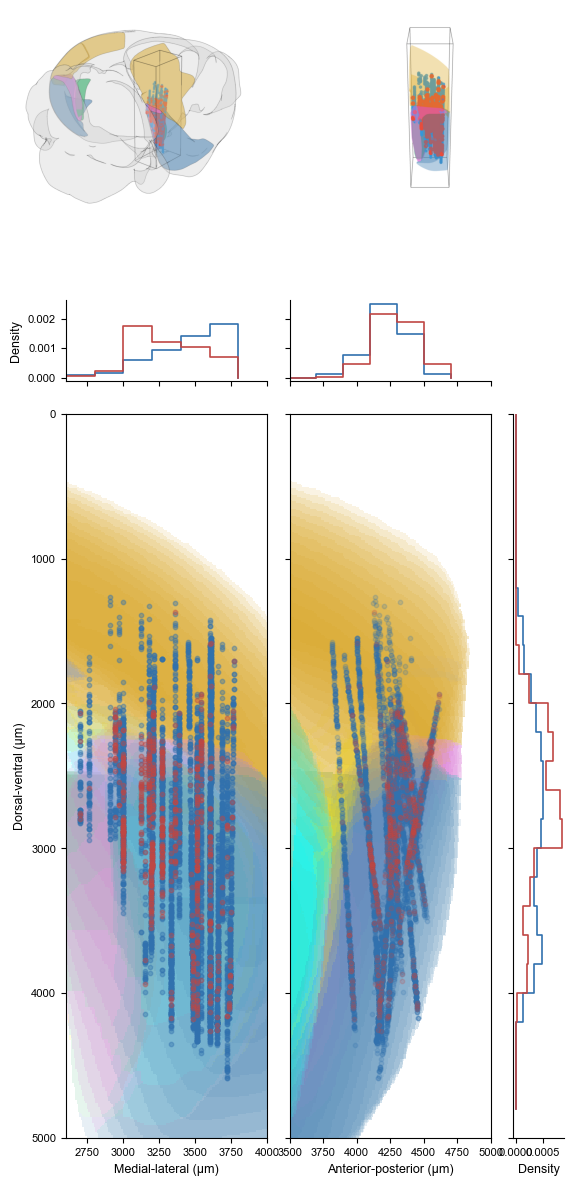

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_and_zoom.pdf


In [2]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
import numpy as np
import pandas as pd
import math
from pathlib import Path
from vedo import Box as VedoBox
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

TICK_SIZE  = 8
LABEL_SIZE = 9

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])
_gc  = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

print(f"Loaded: {len(_gc)} GC, {len(_ngs)} NGS (no region filter)")

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_pts  = _df_to_ccf(_gc)
ngs_pts = _df_to_ccf(_ngs)

ml_gcs = -_gc['SC_x'].values;  ml_ngs = -_ngs['SC_x'].values
dv_gcs =  _gc['SC_y'].values;  dv_ngs =  _ngs['SC_y'].values
ap_gcs =  _gc['SC_z'].values;  ap_ngs =  _ngs['SC_z'].values

ML_LIM = (2600, 4000)
AP_LIM = (3500, 5000)
DV_LIM = (5000, 0)

corners_sc = np.array([
    [AP_LIM[0], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[0]],
])
corners_ccf = np.array([stereo_to_ccf(c) for c in corners_sc])

bbox_min = corners_ccf.min(axis=0)
bbox_max = corners_ccf.max(axis=0)
bbox_center = (bbox_min + bbox_max) / 2
bbox_size   = bbox_max - bbox_min

FOCAL = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))
rendered_bounds = [
    float(bbox_min[0]), float(bbox_max[0]),
    float(bbox_min[1]), float(bbox_max[1]),
    float(-bbox_max[2]), float(-bbox_min[2]),
]
bbox_center_rendered = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))

def in_bbox(pts, bmin, bmax):
    return np.all((pts >= bmin) & (pts <= bmax), axis=1)

gc_box  = gc_pts[in_bbox(gc_pts, bbox_min, bbox_max)]
ngs_box = ngs_pts[in_bbox(ngs_pts, bbox_min, bbox_max)]

STRUCT_REGIONS = [
    ('ENT', 'steelblue',      0.40),
    ('PAR', 'orchid',         0.50),
    ('PRE', 'mediumseagreen', 0.50),
    ('VIS', 'goldenrod',      0.35),
]

R_horiz  = 35000
DV_ELEV  = -15000
R_close  = 12000
DV_close = -6000

# ── RENDER: 320° full brain ──────────────────────────────────────────────────
def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    box = VedoBox(pos=tuple(bbox_center),
                  length=float(bbox_size[0]),
                  width=float(bbox_size[1]),
                  height=float(bbox_size[2]))
    box.wireframe().c('black').lw(3).alpha(1.0)
    scene.add(Actor(box, name='bbox', br_class='mesh'))
    scene.add(Points(ngs_pts, name='NGS', colors='#3498db', radius=60, alpha=0.6))
    scene.add(Points(gc_pts,  name='GC',  colors='#e74c3c', radius=80, alpha=0.9))
    return scene

rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full.png'))

# ── RENDER: 0° posterior clipped ──────────────────────────────────────────────
def build_clipped_scene():
    scene = Scene(root=False, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    if len(ngs_box) > 0:
        scene.add(Points(ngs_box, name='NGS', colors='#3498db', radius=60, alpha=0.6))
    if len(gc_box) > 0:
        scene.add(Points(gc_box,  name='GC',  colors='#e74c3c', radius=80, alpha=0.9))
    return scene

cam_clip = {
    'pos':            (FOCAL[0] + R_close, FOCAL[1] + DV_close, FOCAL[2]),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (5000, 25000),
}

print("Rendering 0° posterior clipped…")
scene = build_clipped_scene()
scene.render(camera=cam_clip, interactive=False, zoom=1)
for a in scene.plotter.objects:
    try:
        a.cut_with_box(rendered_bounds)
    except Exception:
        pass
box = VedoBox(pos=bbox_center_rendered,
              length=float(bbox_size[0]),
              width=float(bbox_size[1]),
              height=float(bbox_size[2]))
box.wireframe().c('black').lw(3).alpha(1.0)
scene.plotter.add(box)
scene.plotter.window.Render()
scene.screenshot(name=str(SAVE_DIR / 'clip'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_clip = mpimg.imread(str(SAVE_DIR / 'clip.png'))

# ── ANNOTATION OVERLAYS (every 100µm) ────────────────────────────────────────
print("Computing annotation overlays (100µm slices)…")

step = 10
ml_axis = np.arange(ML_LIM[0] - 100, ML_LIM[1] + 100, step)
dv_axis = np.arange(min(DV_LIM) - 100, max(DV_LIM) + 100, step)
ap_axis = np.arange(AP_LIM[0] - 100, AP_LIM[1] + 100, step)

ap_slices = list(range(AP_LIM[0], AP_LIM[1] + 1, 100))
ml_slices = list(range(ML_LIM[0], ML_LIM[1] + 1, 100))

def _stereo_to_ccf_vec(ap, dv, ml, angle=-0.0873):
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    s_dv = dv / 0.9434
    return (ap * cos_a - s_dv * sin_a + 5400.0,
            ap * sin_a + s_dv * cos_a + 440.0,
            ml + 5700.0)

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if 'ENT' in acr:      numeric[m] = 1
        elif 'PAR' in acr:    numeric[m] = 2
        elif 'PRE' in acr:    numeric[m] = 3
        elif 'VIS' in acr:    numeric[m] = 4
        elif 'SUB' in acr:    numeric[m] = 5
        elif 'RSP' in acr:    numeric[m] = 6
        elif 'HPF' in acr:    numeric[m] = 7
    return numeric

def _lookup_slice_numeric(ccf_ap, ccf_dv, ccf_ml, shape_2d):
    zi = np.round(ccf_ap / 10).astype(int)
    yi = np.round(ccf_dv / 10).astype(int)
    xi = np.round(ccf_ml / 10).astype(int)
    sh = annotations_set.shape
    valid = (zi >= 0) & (zi < sh[0]) & (yi >= 0) & (yi < sh[1]) & (xi >= 0) & (xi < sh[2])
    aid = np.zeros(len(zi), dtype=int)
    aid[valid] = annotations_set[zi[valid], yi[valid], xi[valid]]
    return _ids_to_numeric(aid).reshape(shape_2d)

def get_ap_slice(ap_val):
    DV, ML = np.meshgrid(dv_axis, ml_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(np.full(DV.size, ap_val), DV.ravel(), ML.ravel())
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, DV.shape)

def get_ml_slice(ml_val):
    AP, DV = np.meshgrid(ap_axis, dv_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(AP.ravel(), DV.ravel(), np.full(AP.size, ml_val))
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, AP.shape)

print("  done")

cmap_list = [(1, 1, 1, 0)]
for name in ['steelblue', 'orchid', 'mediumseagreen', 'goldenrod', 'cyan', 'grey', 'yellow']:
    r, g, b, _ = to_rgba(name)
    cmap_list.append((r, g, b, 0.125))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(-0.5, 8.5, 1), region_cmap.N)

# ── FIGURE ────────────────────────────────────────────────────────────────────
DATA_ASPECT = (max(DV_LIM) - min(DV_LIM)) / (ML_LIM[1] - ML_LIM[0])
HIST_W = 0.25
HIST_H = 0.4

fig_w = 6
bot_panel_w = 0.85 * fig_w
bot_panel_h = bot_panel_w * (HIST_H + DATA_ASPECT) / (2 + HIST_W)
brain_h = 3.0
fig_h = brain_h + 0.4 + bot_panel_h

brain_top = 0.98
brain_bot = brain_top - brain_h / fig_h
bot_top = brain_bot - 0.4 / fig_h
bot_bot = 0.03

fig = plt.figure(figsize=(fig_w, fig_h))

top_gs = fig.add_gridspec(1, 2, wspace=0.02,
                          left=0.05, right=0.95, top=brain_top, bottom=brain_bot)
fig.add_subplot(top_gs[0]).imshow(img_full); fig.axes[-1].axis('off')
fig.add_subplot(top_gs[1]).imshow(img_clip); fig.axes[-1].axis('off')

bot_gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, HIST_W],
    height_ratios=[HIST_H, DATA_ASPECT],
    wspace=0.15, hspace=0.08,
    left=0.12, right=0.95, top=bot_top, bottom=bot_bot,
)

ax_ml_dv = fig.add_subplot(bot_gs[1, 0])
ax_ap_dv = fig.add_subplot(bot_gs[1, 1], sharey=ax_ml_dv)
ax_ml_h  = fig.add_subplot(bot_gs[0, 0], sharex=ax_ml_dv)
ax_ap_h  = fig.add_subplot(bot_gs[0, 1], sharex=ax_ap_dv, sharey=ax_ml_h)
ax_dv_h  = fig.add_subplot(bot_gs[1, 2], sharey=ax_ml_dv)
ax_blank = fig.add_subplot(bot_gs[0, 2])

# ── ML vs DV ─────────────────────────────────────────────────────────────────
for ap_val in ap_slices:
    s = get_ap_slice(ap_val)
    ax_ml_dv.pcolormesh(ml_axis, dv_axis, s,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ml_dv.scatter(ml_ngs, dv_ngs, color='#3171ae', alpha=0.4, s=10, zorder=2)
ax_ml_dv.scatter(ml_gcs, dv_gcs, color='#c04744', alpha=0.4, s=10, zorder=2)
ax_ml_dv.set_xlim(ML_LIM)
ax_ml_dv.set_ylim(DV_LIM)
ax_ml_dv.set_xlabel('Medial-lateral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.tick_params(labelsize=TICK_SIZE)

# ── AP vs DV ─────────────────────────────────────────────────────────────────
for ml_val in ml_slices:
    s = get_ml_slice(ml_val)
    ax_ap_dv.pcolormesh(ap_axis, dv_axis, s.T,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ap_dv.scatter(ap_ngs, dv_ngs, color='#3171ae', alpha=0.2, s=10, zorder=2)
ax_ap_dv.scatter(ap_gcs, dv_gcs, color='#c04744', alpha=0.2, s=10, zorder=2)
ax_ap_dv.set_xlim(AP_LIM)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)', fontsize=LABEL_SIZE)
ax_ap_dv.tick_params(labelleft=False, labelsize=TICK_SIZE)

# ── ML density ────────────────────────────────────────────────────────────────
ml_bins = np.arange(ML_LIM[0], ML_LIM[1] + 1, 200)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ngs, ml_bins, density=True)[0],
             where='post', color='#3171ae', lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gcs, ml_bins, density=True)[0],
             where='post', color='#c04744', lw=1.2)
ax_ml_h.set_ylabel('Density', fontsize=LABEL_SIZE)
ax_ml_h.tick_params(labelbottom=False, labelsize=TICK_SIZE)
ax_ml_h.spines[['top', 'right']].set_visible(False)

# ── AP density ────────────────────────────────────────────────────────────────
ap_bins = np.arange(AP_LIM[0], AP_LIM[1] + 1, 200)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ngs, ap_bins, density=True)[0],
             where='post', color='#3171ae', lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gcs, ap_bins, density=True)[0],
             where='post', color='#c04744', lw=1.2)
ax_ap_h.tick_params(labelbottom=False, labelleft=False, labelsize=TICK_SIZE)
ax_ap_h.spines[['top', 'right']].set_visible(False)

# ── DV density (horizontal) ──────────────────────────────────────────────────
dv_bins = np.arange(min(DV_LIM), max(DV_LIM) + 1, 200)
ax_dv_h.step(np.histogram(dv_ngs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color='#3171ae', lw=1.2)
ax_dv_h.step(np.histogram(dv_gcs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color='#c04744', lw=1.2)
ax_dv_h.set_xlabel('Density', fontsize=LABEL_SIZE)
ax_dv_h.tick_params(labelleft=False, labelsize=TICK_SIZE)
ax_dv_h.spines[['top', 'right']].set_visible(False)

ax_blank.axis('off')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_and_zoom.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=600)
plt.show()
print(f"Saved → {out_path}")


Loaded: 753 GC total (201 both sessions, 552 either only), 6795 NGS
  classified_by values: {'OF1': 294, 'OF2': 258, 'both': 201}
Rendering 320° full brain…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full.png

Rendering 0° posterior clipped…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/clip.png

Computing annotation overlays (100µm slices)…
  done


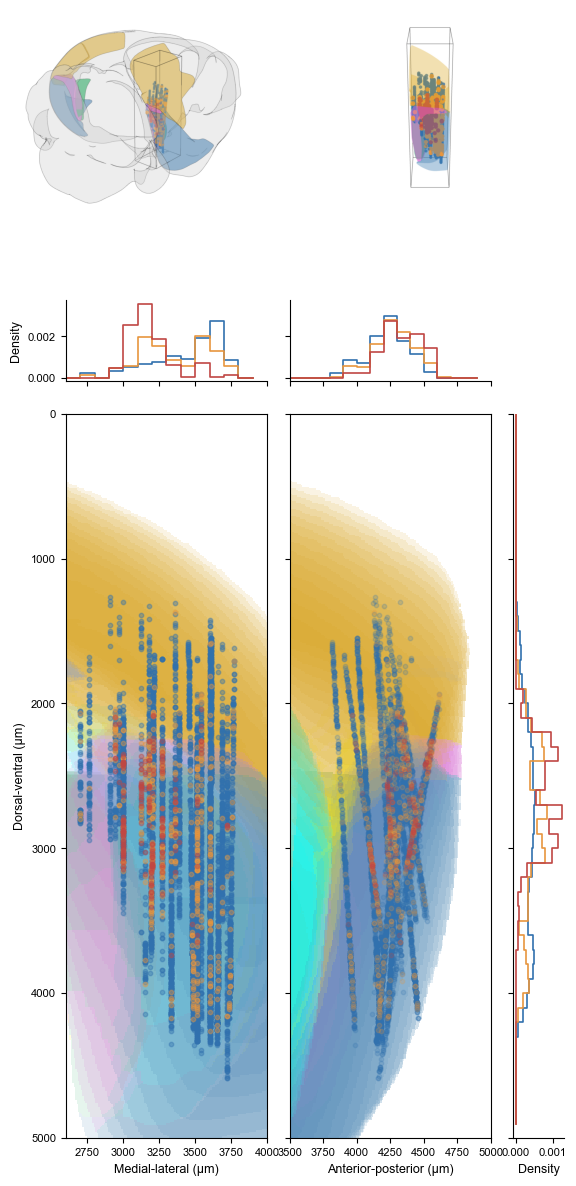

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_gc_sessions.pdf


In [3]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
import numpy as np
import pandas as pd
import math
from pathlib import Path
from vedo import Box as VedoBox
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

TICK_SIZE  = 8
LABEL_SIZE = 9

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])

_gc_all = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs    = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

# Split GCs by classified_by: OF1 or OF2 = either session, anything else = both sessions
_gc_either = _gc_all[_gc_all['classified_by'].isin(['OF1', 'OF2'])]
_gc_both   = _gc_all[~_gc_all['classified_by'].isin(['OF1', 'OF2'])]

print(f"Loaded: {len(_gc_all)} GC total ({len(_gc_both)} both sessions, {len(_gc_either)} either only), {len(_ngs)} NGS")
print(f"  classified_by values: {_gc_all['classified_by'].value_counts().to_dict()}")

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_both_pts   = _df_to_ccf(_gc_both)   if len(_gc_both) > 0   else np.empty((0,3))
gc_either_pts = _df_to_ccf(_gc_either) if len(_gc_either) > 0 else np.empty((0,3))
ngs_pts       = _df_to_ccf(_ngs)

ml_gc_both = -_gc_both['SC_x'].values;   ml_gc_either = -_gc_either['SC_x'].values;   ml_ngs = -_ngs['SC_x'].values
dv_gc_both =  _gc_both['SC_y'].values;   dv_gc_either =  _gc_either['SC_y'].values;   dv_ngs =  _ngs['SC_y'].values
ap_gc_both =  _gc_both['SC_z'].values;   ap_gc_either =  _gc_either['SC_z'].values;   ap_ngs =  _ngs['SC_z'].values

ML_LIM = (2600, 4000)
AP_LIM = (3500, 5000)
DV_LIM = (5000, 0)

corners_sc = np.array([
    [AP_LIM[0], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[0]],
])
corners_ccf = np.array([stereo_to_ccf(c) for c in corners_sc])

bbox_min = corners_ccf.min(axis=0)
bbox_max = corners_ccf.max(axis=0)
bbox_center = (bbox_min + bbox_max) / 2
bbox_size   = bbox_max - bbox_min

FOCAL = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))
rendered_bounds = [
    float(bbox_min[0]), float(bbox_max[0]),
    float(bbox_min[1]), float(bbox_max[1]),
    float(-bbox_max[2]), float(-bbox_min[2]),
]
bbox_center_rendered = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))

def in_bbox(pts, bmin, bmax):
    return np.all((pts >= bmin) & (pts <= bmax), axis=1)

gc_both_box   = gc_both_pts[in_bbox(gc_both_pts, bbox_min, bbox_max)]     if len(gc_both_pts) > 0   else np.empty((0,3))
gc_either_box = gc_either_pts[in_bbox(gc_either_pts, bbox_min, bbox_max)] if len(gc_either_pts) > 0 else np.empty((0,3))
ngs_box       = ngs_pts[in_bbox(ngs_pts, bbox_min, bbox_max)]

STRUCT_REGIONS = [
    ('ENT', 'steelblue',      0.40),
    ('PAR', 'orchid',         0.50),
    ('PRE', 'mediumseagreen', 0.50),
    ('VIS', 'goldenrod',      0.35),
]

R_horiz  = 35000
DV_ELEV  = -15000
R_close  = 12000
DV_close = -6000

COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'

# ── RENDER: 320° full brain ──────────────────────────────────────────────────
def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    box = VedoBox(pos=tuple(bbox_center),
                  length=float(bbox_size[0]),
                  width=float(bbox_size[1]),
                  height=float(bbox_size[2]))
    box.wireframe().c('black').lw(3).alpha(1.0)
    scene.add(Actor(box, name='bbox', br_class='mesh'))
    scene.add(Points(ngs_pts, name='NGS', colors=COL_NGS, radius=60, alpha=0.6))
    if len(gc_either_pts) > 0:
        scene.add(Points(gc_either_pts, name='GC_either', colors=COL_EITHER, radius=80, alpha=0.8))
    if len(gc_both_pts) > 0:
        scene.add(Points(gc_both_pts, name='GC_both', colors=COL_BOTH, radius=80, alpha=0.9))
    return scene

rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full.png'))

# ── RENDER: 0° posterior clipped ──────────────────────────────────────────────
def build_clipped_scene():
    scene = Scene(root=False, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    if len(ngs_box) > 0:
        scene.add(Points(ngs_box, name='NGS', colors=COL_NGS, radius=60, alpha=0.6))
    if len(gc_either_box) > 0:
        scene.add(Points(gc_either_box, name='GC_either', colors=COL_EITHER, radius=80, alpha=0.8))
    if len(gc_both_box) > 0:
        scene.add(Points(gc_both_box, name='GC_both', colors=COL_BOTH, radius=80, alpha=0.9))
    return scene

cam_clip = {
    'pos':            (FOCAL[0] + R_close, FOCAL[1] + DV_close, FOCAL[2]),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (5000, 25000),
}

print("Rendering 0° posterior clipped…")
scene = build_clipped_scene()
scene.render(camera=cam_clip, interactive=False, zoom=1)
for a in scene.plotter.objects:
    try:
        a.cut_with_box(rendered_bounds)
    except Exception:
        pass
box = VedoBox(pos=bbox_center_rendered,
              length=float(bbox_size[0]),
              width=float(bbox_size[1]),
              height=float(bbox_size[2]))
box.wireframe().c('black').lw(3).alpha(1.0)
scene.plotter.add(box)
scene.plotter.window.Render()
scene.screenshot(name=str(SAVE_DIR / 'clip'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_clip = mpimg.imread(str(SAVE_DIR / 'clip.png'))

# ── ANNOTATION OVERLAYS (every 100µm) ────────────────────────────────────────
print("Computing annotation overlays (100µm slices)…")

step = 10
ml_axis = np.arange(ML_LIM[0] - 100, ML_LIM[1] + 100, step)
dv_axis = np.arange(min(DV_LIM) - 100, max(DV_LIM) + 100, step)
ap_axis = np.arange(AP_LIM[0] - 100, AP_LIM[1] + 100, step)

ap_slices = list(range(AP_LIM[0], AP_LIM[1] + 1, 100))
ml_slices = list(range(ML_LIM[0], ML_LIM[1] + 1, 100))

def _stereo_to_ccf_vec(ap, dv, ml, angle=-0.0873):
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    s_dv = dv / 0.9434
    return (ap * cos_a - s_dv * sin_a + 5400.0,
            ap * sin_a + s_dv * cos_a + 440.0,
            ml + 5700.0)

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if 'ENT' in acr:      numeric[m] = 1
        elif 'PAR' in acr:    numeric[m] = 2
        elif 'PRE' in acr:    numeric[m] = 3
        elif 'VIS' in acr:    numeric[m] = 4
        elif 'SUB' in acr:    numeric[m] = 5
        elif 'RSP' in acr:    numeric[m] = 6
        elif 'HPF' in acr:    numeric[m] = 7
    return numeric

def _lookup_slice_numeric(ccf_ap, ccf_dv, ccf_ml, shape_2d):
    zi = np.round(ccf_ap / 10).astype(int)
    yi = np.round(ccf_dv / 10).astype(int)
    xi = np.round(ccf_ml / 10).astype(int)
    sh = annotations_set.shape
    valid = (zi >= 0) & (zi < sh[0]) & (yi >= 0) & (yi < sh[1]) & (xi >= 0) & (xi < sh[2])
    aid = np.zeros(len(zi), dtype=int)
    aid[valid] = annotations_set[zi[valid], yi[valid], xi[valid]]
    return _ids_to_numeric(aid).reshape(shape_2d)

def get_ap_slice(ap_val):
    DV, ML = np.meshgrid(dv_axis, ml_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(np.full(DV.size, ap_val), DV.ravel(), ML.ravel())
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, DV.shape)

def get_ml_slice(ml_val):
    AP, DV = np.meshgrid(ap_axis, dv_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(AP.ravel(), DV.ravel(), np.full(AP.size, ml_val))
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, AP.shape)

print("  done")

cmap_list = [(1, 1, 1, 0)]
for name in ['steelblue', 'orchid', 'mediumseagreen', 'goldenrod', 'cyan', 'grey', 'yellow']:
    r, g, b, _ = to_rgba(name)
    cmap_list.append((r, g, b, 0.125))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(-0.5, 8.5, 1), region_cmap.N)

# ── FIGURE ────────────────────────────────────────────────────────────────────
DATA_ASPECT = (max(DV_LIM) - min(DV_LIM)) / (ML_LIM[1] - ML_LIM[0])
HIST_W = 0.25
HIST_H = 0.4

fig_w = 6
bot_panel_w = 0.85 * fig_w
bot_panel_h = bot_panel_w * (HIST_H + DATA_ASPECT) / (2 + HIST_W)
brain_h = 3.0
fig_h = brain_h + 0.4 + bot_panel_h

brain_top = 0.98
brain_bot = brain_top - brain_h / fig_h
bot_top = brain_bot - 0.4 / fig_h
bot_bot = 0.03

fig = plt.figure(figsize=(fig_w, fig_h))

top_gs = fig.add_gridspec(1, 2, wspace=0.02,
                          left=0.05, right=0.95, top=brain_top, bottom=brain_bot)
fig.add_subplot(top_gs[0]).imshow(img_full); fig.axes[-1].axis('off')
fig.add_subplot(top_gs[1]).imshow(img_clip); fig.axes[-1].axis('off')

bot_gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, HIST_W],
    height_ratios=[HIST_H, DATA_ASPECT],
    wspace=0.15, hspace=0.08,
    left=0.12, right=0.95, top=bot_top, bottom=bot_bot,
)

ax_ml_dv = fig.add_subplot(bot_gs[1, 0])
ax_ap_dv = fig.add_subplot(bot_gs[1, 1], sharey=ax_ml_dv)
ax_ml_h  = fig.add_subplot(bot_gs[0, 0], sharex=ax_ml_dv)
ax_ap_h  = fig.add_subplot(bot_gs[0, 1], sharex=ax_ap_dv, sharey=ax_ml_h)
ax_dv_h  = fig.add_subplot(bot_gs[1, 2], sharey=ax_ml_dv)
ax_blank = fig.add_subplot(bot_gs[0, 2])

# ── ML vs DV ─────────────────────────────────────────────────────────────────
for ap_val in ap_slices:
    s = get_ap_slice(ap_val)
    ax_ml_dv.pcolormesh(ml_axis, dv_axis, s,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ml_dv.scatter(ml_ngs, dv_ngs, color=COL_NGS, alpha=0.4, s=10, zorder=2)
ax_ml_dv.scatter(ml_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.4, s=10, zorder=3)
ax_ml_dv.scatter(ml_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.4, s=10, zorder=4)
ax_ml_dv.set_xlim(ML_LIM)
ax_ml_dv.set_ylim(DV_LIM)
ax_ml_dv.set_xlabel('Medial-lateral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.tick_params(labelsize=TICK_SIZE)

# ── AP vs DV ─────────────────────────────────────────────────────────────────
for ml_val in ml_slices:
    s = get_ml_slice(ml_val)
    ax_ap_dv.pcolormesh(ap_axis, dv_axis, s.T,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ap_dv.scatter(ap_ngs, dv_ngs, color=COL_NGS, alpha=0.2, s=10, zorder=2)
ax_ap_dv.scatter(ap_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.2, s=10, zorder=3)
ax_ap_dv.scatter(ap_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.2, s=10, zorder=4)
ax_ap_dv.set_xlim(AP_LIM)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)', fontsize=LABEL_SIZE)
ax_ap_dv.tick_params(labelleft=False, labelsize=TICK_SIZE)

# ── ML density ────────────────────────────────────────────────────────────────
ml_bins = np.arange(ML_LIM[0], ML_LIM[1] + 1, 100)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ngs, ml_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_either, ml_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_both, ml_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ml_h.set_ylabel('Density', fontsize=LABEL_SIZE)
ax_ml_h.tick_params(labelbottom=False, labelsize=TICK_SIZE)
ax_ml_h.spines[['top', 'right']].set_visible(False)

# ── AP density ────────────────────────────────────────────────────────────────
ap_bins = np.arange(AP_LIM[0], AP_LIM[1] + 1, 100)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ngs, ap_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_either, ap_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_both, ap_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ap_h.tick_params(labelbottom=False, labelleft=False, labelsize=TICK_SIZE)
ax_ap_h.spines[['top', 'right']].set_visible(False)

# ── DV density (horizontal) ──────────────────────────────────────────────────
dv_bins = np.arange(min(DV_LIM), max(DV_LIM) + 1, 100)
ax_dv_h.step(np.histogram(dv_ngs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_NGS, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_either, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_EITHER, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_both, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_BOTH, lw=1.2)
ax_dv_h.set_xlabel('Density', fontsize=LABEL_SIZE)
ax_dv_h.tick_params(labelleft=False, labelsize=TICK_SIZE)
ax_dv_h.spines[['top', 'right']].set_visible(False)

ax_blank.axis('off')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_gc_sessions.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=600)
plt.show()
print(f"Saved → {out_path}")


Loaded: 201 GC(both), 552 GC(either), 6795 NGS, 2391 NS, 1536 contacts
Rendering 320° full brain (contacts)…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full_contacts.png

Rendering 0° posterior clipped (contacts)…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/clip_contacts.png

Computing annotation overlays (100µm slices)…
  done


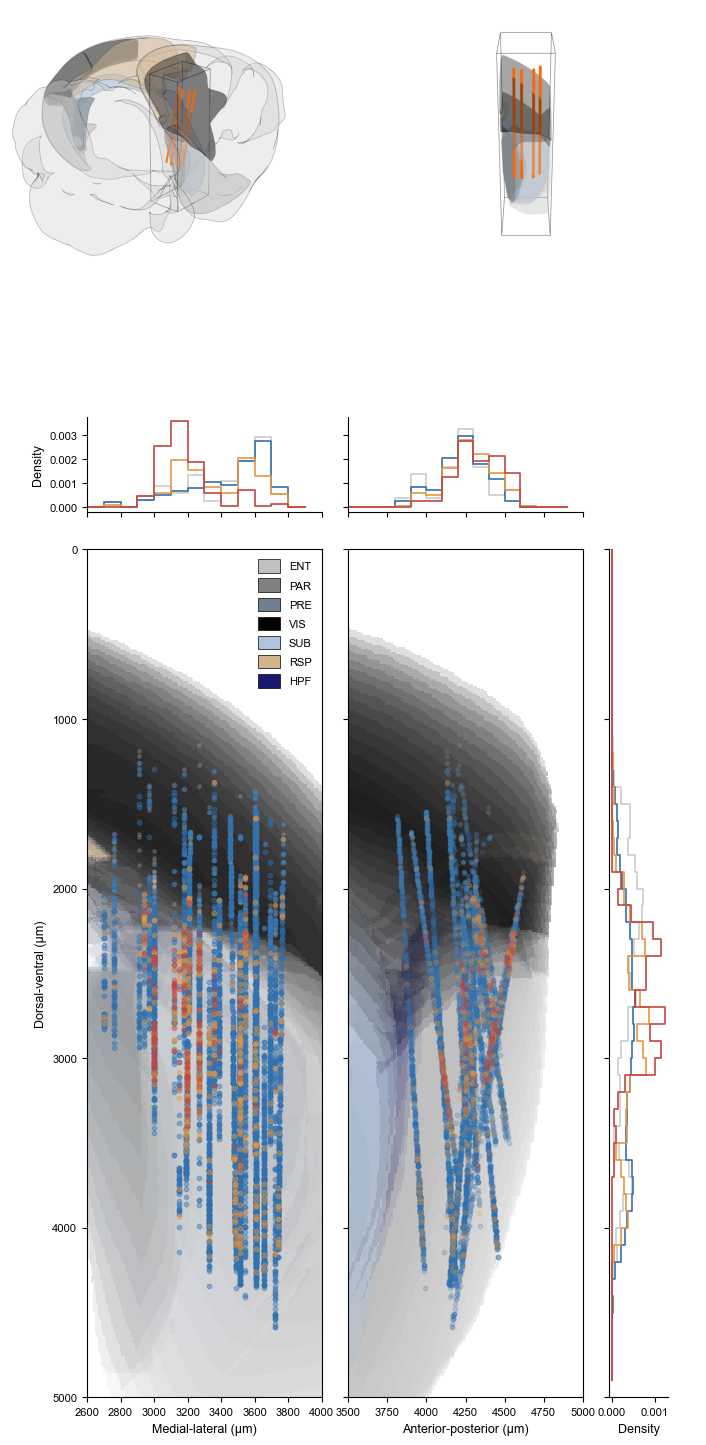

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_contacts_overview.pdf


: 

In [ ]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import math
from pathlib import Path
from vedo import Box as VedoBox
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

TICK_SIZE  = 8
LABEL_SIZE = 9

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])

_gc_all = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs    = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ns     = _df[~_df['cell_type'].isin(['GC', 'NG'])].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

_gc_either = _gc_all[_gc_all['classified_by'].isin(['OF1', 'OF2'])]
_gc_both   = _gc_all[~_gc_all['classified_by'].isin(['OF1', 'OF2'])]

_dc = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
_dc = _dc[_dc['mouse'] == 26]

def _dc_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['coord_SCs_z', 'coord_SCs_y', 'coord_SCs_x']].values])

contact_pts = _dc_to_ccf(_dc)

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_both_pts   = _df_to_ccf(_gc_both)   if len(_gc_both) > 0   else np.empty((0,3))
gc_either_pts = _df_to_ccf(_gc_either) if len(_gc_either) > 0 else np.empty((0,3))
ngs_pts       = _df_to_ccf(_ngs)
ns_pts        = _df_to_ccf(_ns)

ml_gc_both = -_gc_both['SC_x'].values;   ml_gc_either = -_gc_either['SC_x'].values
ml_ngs = -_ngs['SC_x'].values;           ml_ns = -_ns['SC_x'].values
dv_gc_both =  _gc_both['SC_y'].values;   dv_gc_either =  _gc_either['SC_y'].values
dv_ngs =  _ngs['SC_y'].values;           dv_ns =  _ns['SC_y'].values
ap_gc_both =  _gc_both['SC_z'].values;   ap_gc_either =  _gc_either['SC_z'].values
ap_ngs =  _ngs['SC_z'].values;           ap_ns =  _ns['SC_z'].values

print(f"Loaded: {len(_gc_both)} GC(both), {len(_gc_either)} GC(either), {len(_ngs)} NGS, {len(_ns)} NS, {len(_dc)} contacts")

ML_LIM = (2600, 4000)
AP_LIM = (3500, 5000)
DV_LIM = (5000, 0)

corners_sc = np.array([
    [AP_LIM[0], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[0]],
])
corners_ccf = np.array([stereo_to_ccf(c) for c in corners_sc])

bbox_min = corners_ccf.min(axis=0)
bbox_max = corners_ccf.max(axis=0)
bbox_center = (bbox_min + bbox_max) / 2
bbox_size   = bbox_max - bbox_min

FOCAL = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))
rendered_bounds = [
    float(bbox_min[0]), float(bbox_max[0]),
    float(bbox_min[1]), float(bbox_max[1]),
    float(-bbox_max[2]), float(-bbox_min[2]),
]
bbox_center_rendered = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))

def in_bbox(pts, bmin, bmax):
    return np.all((pts >= bmin) & (pts <= bmax), axis=1)

contact_box   = contact_pts[in_bbox(contact_pts, bbox_min, bbox_max)]
gc_both_box   = gc_both_pts[in_bbox(gc_both_pts, bbox_min, bbox_max)]     if len(gc_both_pts) > 0   else np.empty((0,3))
gc_either_box = gc_either_pts[in_bbox(gc_either_pts, bbox_min, bbox_max)] if len(gc_either_pts) > 0 else np.empty((0,3))
ngs_box       = ngs_pts[in_bbox(ngs_pts, bbox_min, bbox_max)]
ns_box        = ns_pts[in_bbox(ns_pts, bbox_min, bbox_max)]

STRUCT_REGIONS = [
    ('ENT', 'silver',         0.40),
    ('PAR', 'grey',           0.50),
    ('PRE', 'slategrey',      0.50),
    ('VIS', 'black',          0.35),
    ('SUB', 'lightsteelblue', 0.40),
    ('RSP', 'tan',            0.35),
]

R_horiz  = 35000
DV_ELEV  = -15000
R_close  = 12000
DV_close = -6000

COL_BOTH    = '#c04744'
COL_GC_EITHER = '#e8963e'
COL_EITHER = '#e8963e'
COL_NGS     = '#3171ae'
COL_NS      = '#cccccc'
COL_CONTACT = '#ff6500'

def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    box = VedoBox(pos=tuple(bbox_center),
                  length=float(bbox_size[0]),
                  width=float(bbox_size[1]),
                  height=float(bbox_size[2]))
    box.wireframe().c('black').lw(3).alpha(1.0)
    scene.add(Actor(box, name='bbox', br_class='mesh'))
    scene.add(Points(contact_pts, name='contacts', colors=COL_CONTACT, radius=40, alpha=0.6))
    return scene

rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain (contacts)…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full_contacts'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full_contacts.png'))

def build_clipped_scene():
    scene = Scene(root=False, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    if len(contact_box) > 0:
        scene.add(Points(contact_box, name='contacts', colors=COL_CONTACT, radius=40, alpha=0.6))
    return scene

cam_clip = {
    'pos':            (FOCAL[0] + R_close, FOCAL[1] + DV_close, FOCAL[2]),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (5000, 25000),
}

print("Rendering 0° posterior clipped (contacts)…")
scene = build_clipped_scene()
scene.render(camera=cam_clip, interactive=False, zoom=1)
for a in scene.plotter.objects:
    try:
        a.cut_with_box(rendered_bounds)
    except Exception:
        pass
box = VedoBox(pos=bbox_center_rendered,
              length=float(bbox_size[0]),
              width=float(bbox_size[1]),
              height=float(bbox_size[2]))
box.wireframe().c('black').lw(3).alpha(1.0)
scene.plotter.add(box)
scene.plotter.window.Render()
scene.screenshot(name=str(SAVE_DIR / 'clip_contacts'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_clip = mpimg.imread(str(SAVE_DIR / 'clip_contacts.png'))

print("Computing annotation overlays (100µm slices)…")

step = 10
ml_axis = np.arange(ML_LIM[0] - 100, ML_LIM[1] + 100, step)
dv_axis = np.arange(min(DV_LIM) - 100, max(DV_LIM) + 100, step)
ap_axis = np.arange(AP_LIM[0] - 100, AP_LIM[1] + 100, step)

ap_slices = list(range(AP_LIM[0], AP_LIM[1] + 1, 100))
ml_slices = list(range(ML_LIM[0], ML_LIM[1] + 1, 100))

def _stereo_to_ccf_vec(ap, dv, ml, angle=-0.0873):
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    s_dv = dv / 0.9434
    return (ap * cos_a - s_dv * sin_a + 5400.0,
            ap * sin_a + s_dv * cos_a + 440.0,
            ml + 5700.0)

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if 'ENT' in acr:      numeric[m] = 1
        elif 'PAR' in acr:    numeric[m] = 2
        elif 'PRE' in acr:    numeric[m] = 3
        elif 'VIS' in acr:    numeric[m] = 4
        elif 'SUB' in acr:    numeric[m] = 5
        elif 'RSP' in acr:    numeric[m] = 6
        elif 'HPF' in acr:    numeric[m] = 7
    return numeric

def _lookup_slice_numeric(ccf_ap, ccf_dv, ccf_ml, shape_2d):
    zi = np.round(ccf_ap / 10).astype(int)
    yi = np.round(ccf_dv / 10).astype(int)
    xi = np.round(ccf_ml / 10).astype(int)
    sh = annotations_set.shape
    valid = (zi >= 0) & (zi < sh[0]) & (yi >= 0) & (yi < sh[1]) & (xi >= 0) & (xi < sh[2])
    aid = np.zeros(len(zi), dtype=int)
    aid[valid] = annotations_set[zi[valid], yi[valid], xi[valid]]
    return _ids_to_numeric(aid).reshape(shape_2d)

def get_ap_slice(ap_val):
    DV, ML = np.meshgrid(dv_axis, ml_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(np.full(DV.size, ap_val), DV.ravel(), ML.ravel())
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, DV.shape)

def get_ml_slice(ml_val):
    AP, DV = np.meshgrid(ap_axis, dv_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(AP.ravel(), DV.ravel(), np.full(AP.size, ml_val))
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, AP.shape)

print("  done")

cmap_list = [(1, 1, 1, 0)]
for name in ['silver', 'grey', 'slategrey', 'black', 'lightsteelblue', 'tan', 'midnightblue']:
    r, g, b, _ = to_rgba(name)
    cmap_list.append((r, g, b, 0.125))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(-0.5, 8.5, 1), region_cmap.N)

DATA_ASPECT = (max(DV_LIM) - min(DV_LIM)) / (ML_LIM[1] - ML_LIM[0])
HIST_W = 0.25
HIST_H = 0.4

fig_w = 7
bot_panel_w = 0.85 * fig_w
bot_panel_h = bot_panel_w * (HIST_H + DATA_ASPECT) / (2 + HIST_W)
brain_h = 5.0
fig_h = brain_h + 0.4 + bot_panel_h

brain_top = 0.98
brain_bot = brain_top - brain_h / fig_h
bot_top = brain_bot - 0.3 / fig_h
bot_bot = 0.03

fig = plt.figure(figsize=(fig_w, fig_h))

top_gs = fig.add_gridspec(1, 2, wspace=0.02,
                          left=0.01, right=0.99, top=brain_top, bottom=brain_bot)
fig.add_subplot(top_gs[0]).imshow(img_full); fig.axes[-1].axis('off')
fig.add_subplot(top_gs[1]).imshow(img_clip); fig.axes[-1].axis('off')

bot_gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, HIST_W],
    height_ratios=[HIST_H, DATA_ASPECT],
    wspace=0.15, hspace=0.08,
    left=0.12, right=0.95, top=bot_top, bottom=bot_bot,
)

ax_ml_dv = fig.add_subplot(bot_gs[1, 0])
ax_ap_dv = fig.add_subplot(bot_gs[1, 1], sharey=ax_ml_dv)
ax_ml_h  = fig.add_subplot(bot_gs[0, 0], sharex=ax_ml_dv)
ax_ap_h  = fig.add_subplot(bot_gs[0, 1], sharex=ax_ap_dv, sharey=ax_ml_h)
ax_dv_h  = fig.add_subplot(bot_gs[1, 2], sharey=ax_ml_dv)
ax_blank = fig.add_subplot(bot_gs[0, 2])

for ap_val in ap_slices:
    s = get_ap_slice(ap_val)
    ax_ml_dv.pcolormesh(ml_axis, dv_axis, s,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ml_dv.scatter(ml_ns, dv_ns, color=COL_NS, alpha=0.2, s=6, zorder=1)
ax_ml_dv.scatter(ml_ngs, dv_ngs, color=COL_NGS, alpha=0.4, s=10, zorder=2)
ax_ml_dv.scatter(ml_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.4, s=10, zorder=3)
ax_ml_dv.scatter(ml_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.4, s=10, zorder=4)
ax_ml_dv.set_xlim(ML_LIM)
ax_ml_dv.set_ylim(DV_LIM)
ax_ml_dv.set_xlabel('Medial-lateral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.tick_params(labelsize=TICK_SIZE)

region_legend = [
    Patch(facecolor='silver', edgecolor='black', lw=0.5, label='ENT'),
    Patch(facecolor='grey', edgecolor='black', lw=0.5, label='PAR'),
    Patch(facecolor='slategrey', edgecolor='black', lw=0.5, label='PRE'),
    Patch(facecolor='black', edgecolor='black', lw=0.5, label='VIS'),
    Patch(facecolor='lightsteelblue', edgecolor='black', lw=0.5, label='SUB'),
    Patch(facecolor='tan', edgecolor='black', lw=0.5, label='RSP'),
    Patch(facecolor='midnightblue', edgecolor='black', lw=0.5, label='HPF'),
]
ax_ml_dv.legend(handles=region_legend, fontsize=8, frameon=False, loc='upper right',
                handlelength=2, handleheight=1.5, labelspacing=0.5)

for ml_val in ml_slices:
    s = get_ml_slice(ml_val)
    ax_ap_dv.pcolormesh(ap_axis, dv_axis, s.T,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ap_dv.scatter(ap_ns, dv_ns, color=COL_NS, alpha=0.1, s=6, zorder=1)
ax_ap_dv.scatter(ap_ngs, dv_ngs, color=COL_NGS, alpha=0.2, s=10, zorder=2)
ax_ap_dv.scatter(ap_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.2, s=10, zorder=3)
ax_ap_dv.scatter(ap_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.2, s=10, zorder=4)
ax_ap_dv.set_xlim(AP_LIM)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)', fontsize=LABEL_SIZE)
ax_ap_dv.tick_params(labelleft=False, labelsize=TICK_SIZE)

ml_bins = np.arange(ML_LIM[0], ML_LIM[1] + 1, 100)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ns, ml_bins, density=True)[0],
             where='post', color=COL_NS, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ngs, ml_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_either, ml_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_both, ml_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ml_h.set_ylabel('Density', fontsize=LABEL_SIZE)
ax_ml_h.tick_params(labelbottom=False, labelsize=TICK_SIZE)
ax_ml_h.spines[['top', 'right']].set_visible(False)

ap_bins = np.arange(AP_LIM[0], AP_LIM[1] + 1, 100)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ns, ap_bins, density=True)[0],
             where='post', color=COL_NS, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ngs, ap_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_either, ap_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_both, ap_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ap_h.tick_params(labelbottom=False, labelleft=False, labelsize=TICK_SIZE)
ax_ap_h.spines[['top', 'right']].set_visible(False)

dv_bins = np.arange(min(DV_LIM), max(DV_LIM) + 1, 100)
ax_dv_h.step(np.histogram(dv_ns, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_NS, lw=1.2)
ax_dv_h.step(np.histogram(dv_ngs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_NGS, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_either, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_EITHER, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_both, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_BOTH, lw=1.2)
ax_dv_h.set_xlabel('Density', fontsize=LABEL_SIZE)
ax_dv_h.tick_params(labelleft=False, labelsize=TICK_SIZE)
ax_dv_h.spines[['top', 'right']].set_visible(False)

ax_blank.axis('off')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_contacts_overview.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=1000)
plt.show()
print(f"Saved → {out_path}")


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]

gc_both   = _cc[(_cc['cell_type'] == 'GC') & (_cc['classified_by'] == 'both')]
gc_either = _cc[(_cc['cell_type'] == 'GC') & (_cc['classified_by'].isin(['OF1', 'OF2']))]
ngs       = _cc[_cc['cell_type'] == 'NG']

mouse_ids = np.sort(_cc['mouse'].dropna().unique().astype(int))

device_contacts = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
device_contacts = device_contacts[device_contacts['mouse'] != 22]
ent_contacts = device_contacts[device_contacts['brain_region'].str.contains('ENT', case=False, na=False)]

ml_bins = np.arange(2600, 4001, 100)
ap_bins = np.arange(3500, 5001, 100)
dv_bins = np.arange(0, 5001, 100)

print(f"Cells: {len(gc_both)} GC(both), {len(gc_either)} GC(either), {len(ngs)} NGS | ENT contacts: {len(ent_contacts)}")

n_mice = len(mouse_ids)
groups = {
    'GC_both': gc_both,
    'GC_either': gc_either,
    'NGS': ngs,
}

coord_fns = {
    'ML': (lambda df: np.abs(df['SC_x']),      lambda df: np.abs(df['coord_SCs_x'])),
    'AP': (lambda df: df['SC_z'],               lambda df: df['coord_SCs_z']),
    'DV': (lambda df: df['SC_y'],               lambda df: df['coord_SCs_y']),
}

def compute_per_mouse_hist(group_dfs, contact_df, coord_fn_cells, coord_fn_contacts, bins):
    n_bins = len(bins) - 1
    hists = {name: np.full((n_mice, n_bins), np.nan) for name in group_dfs}

    for i_mouse, mouse in enumerate(mouse_ids):
        contacts_mouse = contact_df[contact_df['mouse'] == mouse]
        contact_counts, _ = np.histogram(coord_fn_contacts(contacts_mouse), bins=bins)

        for name, df in group_dfs.items():
            cells_mouse = df[df['mouse'] == mouse]
            cell_counts, _ = np.histogram(coord_fn_cells(cells_mouse), bins=bins)
            hists[name][i_mouse] = np.divide(cell_counts, contact_counts,
                                              out=np.full(n_bins, np.nan), where=contact_counts > 0)
    return hists

def uniformity_glmm_per_group(group_dfs, contact_df, coord_fn_cells, coord_fn_contacts, bins, axis_label):
    pvals = {}
    for group_name, cell_df in group_dfs.items():
        data = []
        for mouse in mouse_ids:
            contacts_mouse = contact_df[contact_df['mouse'] == mouse]
            contact_counts, _ = np.histogram(coord_fn_contacts(contacts_mouse), bins=bins)

            days = cell_df[cell_df['mouse'] == mouse]['day'].dropna().unique()
            for day in days:
                cells_day = cell_df[(cell_df['mouse'] == mouse) & (cell_df['day'] == day)]
                cell_counts, _ = np.histogram(coord_fn_cells(cells_day), bins=bins)

                for i_bin in range(len(bins) - 1):
                    if contact_counts[i_bin] > 0:
                        data.append({
                            'value': cell_counts[i_bin] / contact_counts[i_bin],
                            'bin': float(bins[i_bin]),
                            'mouse': int(mouse),
                            'session': f"{int(mouse)}_{int(day)}",
                        })

        df = pd.DataFrame(data)
        if len(df) < 10:
            print(f"  {axis_label} {group_name}: skipped (too few observations)")
            pvals[group_name] = np.nan
            continue

        df['bin_z'] = (df['bin'] - df['bin'].mean()) / df['bin'].std()

        try:
            model = smf.mixedlm(
                "value ~ bin_z", df,
                groups=df["mouse"],
                vc_formula={"session": "0 + C(session)"},
            )
            result = model.fit(method="powell", maxiter=5000, disp=False)
            p = result.pvalues.get('bin_z', np.nan)
            print(f"  {axis_label} {group_name}: bin_z p = {p:.4g}")
            pvals[group_name] = p
        except Exception as e:
            print(f"  {axis_label} {group_name}: GLMM failed ({e})")
            pvals[group_name] = np.nan

    return pvals

cell_fn_ml, contact_fn_ml = coord_fns['ML']
cell_fn_ap, contact_fn_ap = coord_fns['AP']
cell_fn_dv, contact_fn_dv = coord_fns['DV']

hists_ml = compute_per_mouse_hist(groups, ent_contacts, cell_fn_ml, contact_fn_ml, ml_bins)
hists_ap = compute_per_mouse_hist(groups, ent_contacts, cell_fn_ap, contact_fn_ap, ap_bins)
hists_dv = compute_per_mouse_hist(groups, ent_contacts, cell_fn_dv, contact_fn_dv, dv_bins)

print("\nUniformity GLMMs (H0: uniform distribution along axis):")
pvals_ml = uniformity_glmm_per_group(groups, ent_contacts, cell_fn_ml, contact_fn_ml, ml_bins, 'ML')
pvals_ap = uniformity_glmm_per_group(groups, ent_contacts, cell_fn_ap, contact_fn_ap, ap_bins, 'AP')
pvals_dv = uniformity_glmm_per_group(groups, ent_contacts, cell_fn_dv, contact_fn_dv, dv_bins, 'DV')


Cells: 193 GC(both), 502 GC(either), 5717 NGS | ENT contacts: 4900

Uniformity GLMMs (H0: uniform distribution along axis):
  ML GC_both: bin_z p = 3.97e-05
  ML GC_either: bin_z p = 0.01968
  ML NGS: bin_z p = 0.06801
  AP GC_both: bin_z p = 0.01085
  AP GC_either: bin_z p = 0.04526
  AP NGS: bin_z p = 0.7737
  DV GC_both: bin_z p = 3.064e-10
  DV GC_either: bin_z p = 1.935e-08
  DV NGS: bin_z p = 0.002618


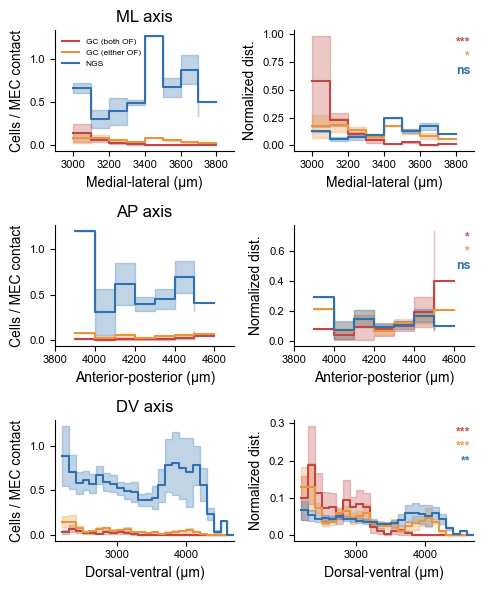

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

def mean_sem(arr):
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return mean, sem

def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=False):
    y = mean / 2 if div2 else mean
    yerr = sem / 2 if div2 else sem
    ax.step(bins[:-1], y, where='post', color=color, label=label)
    ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

def pval_to_stars(p):
    if p is None or np.isnan(p):
        return 'n.s.'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def get_occupied_xlim(hists, bins):
    all_occupied = np.zeros(len(bins) - 1, dtype=bool)
    for name, hist in hists.items():
        m = np.nanmean(hist, axis=0)
        all_occupied |= (m > 0) & ~np.isnan(m)
    occupied_idx = np.where(all_occupied)[0]
    if len(occupied_idx) == 0:
        return (bins[0], bins[-1])
    return (bins[occupied_idx[0]] - 100, bins[occupied_idx[-1] + 1] + 100)

COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'

group_style = [
    ('GC_both',   COL_BOTH,   'GC (both OF)'),
    ('GC_either', COL_EITHER, 'GC (either OF)'),
    ('NGS',       COL_NGS,    'NGS'),
]

fig, axes = plt.subplots(3, 2, figsize=(5, 6))

for row, (hists, bins, pvals, axis_name, xlabel) in enumerate([
    (hists_ml, ml_bins, pvals_ml, 'ML', 'Medial-lateral (µm)'),
    (hists_ap, ap_bins, pvals_ap, 'AP', 'Anterior-posterior (µm)'),
    (hists_dv, dv_bins, pvals_dv, 'DV', 'Dorsal-ventral (µm)'),
]):
    xlim = get_occupied_xlim(hists, bins)

    # Left: cells per MEC contact
    for name, color, label in group_style:
        m, s = mean_sem(hists[name])
        plot_step_with_sem(axes[row, 0], bins, m, s, color, label=label, div2=True)
    axes[row, 0].set_xlabel(xlabel)
    axes[row, 0].set_ylabel('Cells / MEC contact')
    axes[row, 0].set_title(f'{axis_name} axis', fontsize=12, fontweight='normal')
    axes[row, 0].set_xlim(xlim)
    if row == 0:
        axes[row, 0].legend(fontsize=6, frameon=False)

    # Right: normalized distribution with uniformity stars
    for name, color, label in group_style:
        m, s = mean_sem(hists[name])
        total = np.nansum(m)
        if total > 0:
            plot_step_with_sem(axes[row, 1], bins, m / total, s / total, color)
    axes[row, 1].set_xlabel(xlabel)
    axes[row, 1].set_ylabel('Normalized dist.')
    axes[row, 1].set_xlim(xlim)

    # Annotate stars in each group's color
    for i, (name, color, label) in enumerate(group_style):
        p = pvals.get(name, np.nan)
        stars = pval_to_stars(p)
        axes[row, 1].annotate(stars,
                              xy=(0.98, 0.95 - i * 0.12), xycoords='axes fraction',
                              ha='right', va='top', fontsize=9, fontweight='bold',
                              color=color)

for ax_row in axes:
    for ax in ax_row:
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_gc_split.pdf', bbox_inches='tight', dpi=300)
plt.show()


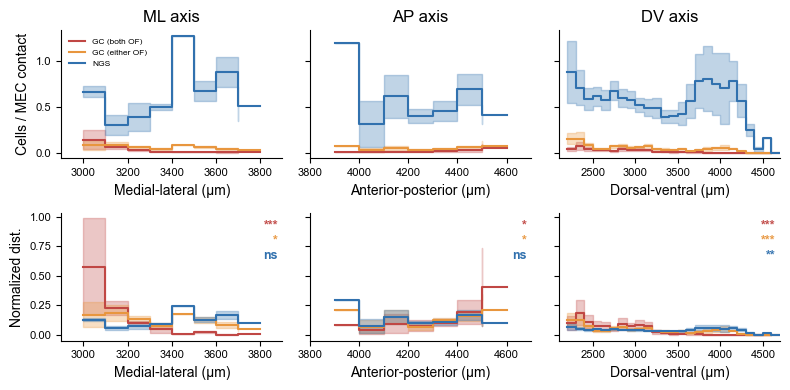

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

# Restore bins to match what was used in compute_per_mouse_hist
ml_bins = np.arange(2600, 4001, 100)
ap_bins = np.arange(3500, 5001, 100)
dv_bins = np.arange(0, 5001, 100)

def mean_sem(arr):
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return mean, sem

def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=False):
    y = mean / 2 if div2 else mean
    yerr = sem / 2 if div2 else sem
    ax.step(bins[:-1], y, where='post', color=color, label=label)
    ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

def pval_to_stars(p):
    if p is None or np.isnan(p):
        return 'n.s.'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def get_occupied_xlim(hists, bins):
    all_occupied = np.zeros(len(bins) - 1, dtype=bool)
    for name, hist in hists.items():
        m = np.nanmean(hist, axis=0)
        all_occupied |= (m > 0) & ~np.isnan(m)
    occupied_idx = np.where(all_occupied)[0]
    if len(occupied_idx) == 0:
        return (bins[0], bins[-1])
    return (bins[occupied_idx[0]] - 100, bins[occupied_idx[-1] + 1] + 100)

COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'

group_style = [
    ('GC_both',   COL_BOTH,   'GC (both OF)'),
    ('GC_either', COL_EITHER, 'GC (either OF)'),
    ('NGS',       COL_NGS,    'NGS'),
]

axis_data = [
    (hists_ml, ml_bins, pvals_ml, 'ML', 'Medial-lateral (µm)'),
    (hists_ap, ap_bins, pvals_ap, 'AP', 'Anterior-posterior (µm)'),
    (hists_dv, dv_bins, pvals_dv, 'DV', 'Dorsal-ventral (µm)'),
]

fig, axes = plt.subplots(2, 3, figsize=(8, 4),
                         sharey='row')

for col, (hists, bins, pvals, axis_name, xlabel) in enumerate(axis_data):
    xlim = get_occupied_xlim(hists, bins)

    # Top row: cells per MEC contact
    for name, color, label in group_style:
        m, s = mean_sem(hists[name])
        plot_step_with_sem(axes[0, col], bins, m, s, color, label=label, div2=True)
    axes[0, col].set_title(f'{axis_name} axis', fontsize=12, fontweight='normal')
    axes[0, col].set_xlabel(xlabel)
    axes[0, col].set_xlim(xlim)

    # Bottom row: normalized distribution with uniformity stars
    for name, color, label in group_style:
        m, s = mean_sem(hists[name])
        total = np.nansum(m)
        if total > 0:
            plot_step_with_sem(axes[1, col], bins, m / total, s / total, color)
    axes[1, col].set_xlabel(xlabel)
    axes[1, col].set_xlim(xlim)

    # Annotate stars
    for i, (name, color, label) in enumerate(group_style):
        p = pvals.get(name, np.nan)
        stars = pval_to_stars(p)
        axes[1, col].annotate(stars,
                              xy=(0.98, 0.95 - i * 0.12), xycoords='axes fraction',
                              ha='right', va='top', fontsize=9, fontweight='bold',
                              color=color)

# Y-axis labels only on leftmost column
axes[0, 0].set_ylabel('Cells / MEC contact')
axes[1, 0].set_ylabel('Normalized dist.')

# Legend on first panel only
axes[0, 0].legend(fontsize=6, frameon=False)

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_gc_split.pdf', bbox_inches='tight', dpi=300)
plt.show()


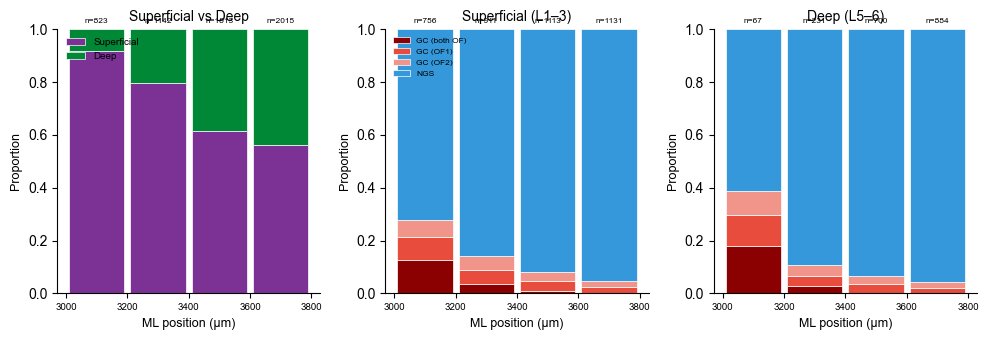

In [8]:
import matplotlib.pyplot as plt
import numpy as np

ml_all = -_df['SC_x']

cats = []
for _, row in _df.iterrows():
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        cats.append(cb if cb in ('both', 'OF1', 'OF2') else 'OF1')
    elif row['cell_type'] == 'NG':
        cats.append('NGS')
    else:
        cats.append(None)
_df['_cat'] = cats

def get_layer(region):
    if not isinstance(region, str):
        return None
    r = region.upper()
    if any(x in r for x in ['ENTM1', 'ENTM2', 'ENTM3']):
        return 'Superficial'
    elif any(x in r for x in ['ENTM5', 'ENTM6']):
        return 'Deep'
    return None

col = 'brain_region' if 'brain_region' in _df.columns else 'annotation'
_df['_layer'] = _df[col].apply(get_layer)

keep = (_df['_cat'].notna() & _df['_layer'].notna() &
        ml_all.notna() & _df['cell_type'].isin(['GC', 'NG']))
df_all = _df[keep].copy()
df_all['_ml'] = ml_all[keep]

bin_edges = np.arange(3000, 3801, 200)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

cat_order = ['both', 'OF1', 'OF2', 'NGS']
cat_colors = {'both': '#8B0000', 'OF1': '#e74c3c', 'OF2': '#f1948a', 'NGS': '#3498db'}
cat_labels = {'both': 'GC (both OF)', 'OF1': 'GC (OF1)', 'OF2': 'GC (OF2)', 'NGS': 'NGS'}

layer_order = ['Superficial', 'Deep']
layer_colors = {'Superficial': '#7b3294', 'Deep': '#008837'}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

# ── Panel 0: Superficial vs Deep proportions by ML ───────────────────────────
ax = axes[0]
df_all['_bin'] = pd.cut(df_all['_ml'], bins=bin_edges, right=False)

counts_layer = df_all.groupby(['_bin', '_layer']).size().unstack(fill_value=0)
for c in layer_order:
    if c not in counts_layer.columns:
        counts_layer[c] = 0
counts_layer = counts_layer[layer_order]
props_layer = counts_layer.div(counts_layer.sum(axis=1), axis=0)

bottom = np.zeros(len(props_layer))
for layer in layer_order:
    vals = props_layer[layer].values
    ax.bar(bin_centres, vals, width=180, bottom=bottom,
           color=layer_colors[layer], label=layer,
           edgecolor='white', lw=0.5)
    bottom += vals

ax.set_xlabel('ML position (µm)', fontsize=9)
ax.set_ylabel('Proportion', fontsize=9)
ax.set_title('Superficial vs Deep', fontsize=10)
ax.set_xticks(bin_edges)
ax.set_xticklabels([f'{int(e)}' for e in bin_edges], fontsize=7)
ax.set_ylim(0, 1)
ax.legend(fontsize=7, loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)

for j, (centre, total) in enumerate(zip(bin_centres, counts_layer.sum(axis=1).values)):
    ax.text(centre, 1.02, f'n={int(total)}', ha='center', va='bottom', fontsize=6)

# ── Panel 1: Superficial — cell type proportions by ML ───────────────────────
# ── Panel 2: Deep — cell type proportions by ML ──────────────────────────────
for i, layer in enumerate(layer_order):
    ax = axes[i + 1]
    df_layer = df_all[df_all['_layer'] == layer].copy()
    df_layer['_bin'] = pd.cut(df_layer['_ml'], bins=bin_edges, right=False)

    counts = df_layer.groupby(['_bin', '_cat']).size().unstack(fill_value=0)
    for c in cat_order:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[cat_order]
    proportions = counts.div(counts.sum(axis=1), axis=0)

    bottom = np.zeros(len(proportions))
    for cat in cat_order:
        vals = proportions[cat].values
        ax.bar(bin_centres, vals, width=180, bottom=bottom,
               color=cat_colors[cat], label=cat_labels[cat],
               edgecolor='white', lw=0.5)
        bottom += vals

    ax.set_xlabel('ML position (µm)', fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.set_title(f'{layer} (L1–3)' if layer == 'Superficial' else f'{layer} (L5–6)',
                 fontsize=10)
    ax.set_xticks(bin_edges)
    ax.set_xticklabels([f'{int(e)}' for e in bin_edges], fontsize=7)
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

    for j, (centre, total) in enumerate(zip(bin_centres, counts.sum(axis=1).values)):
        ax.text(centre, 1.02, f'n={int(total)}', ha='center', va='bottom', fontsize=6)

    if i == 0:
        ax.legend(fontsize=6, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

_df.drop(columns=['_cat', '_layer'], inplace=True)


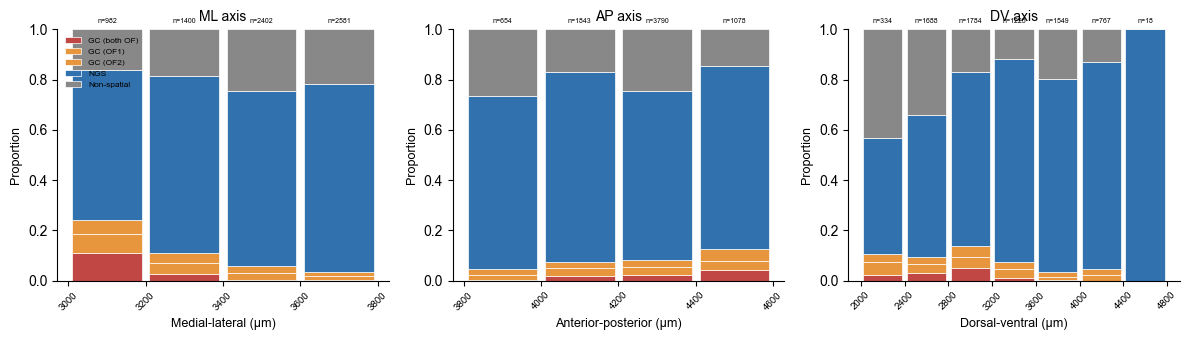

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Arial'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()
_cc['ml'] = _cc['SC_x'].abs()
_cc['dv'] = _cc['SC_y']
_cc['ap'] = _cc['SC_z']

# Assign category
cats = []
for _, row in _cc.iterrows():
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        cats.append(cb if cb in ('both', 'OF1', 'OF2') else 'OF1')
    elif row['cell_type'] == 'NG':
        cats.append('NGS')
    else:
        cats.append('Other')
_cc['_cat'] = cats

cat_order = ['both', 'OF1', 'OF2', 'NGS', 'Other']
cat_colors = {'both': '#c04744', 'OF1': '#e8963e', 'OF2': '#e8963e', 'NGS': '#3171ae', 'Other': '#888888'}
cat_labels = {'both': 'GC (both OF)', 'OF1': 'GC (OF1)', 'OF2': 'GC (OF2)', 'NGS': 'NGS', 'Other': 'Non-spatial'}

ml_bins = np.arange(3000, 3901, 200)
ap_bins = np.arange(3800, 4701, 200)
dv_bins = np.arange(2000, 4801, 400)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for col_idx, (pos_col, bins, xlabel, axis_name) in enumerate([
    ('ml', ml_bins, 'Medial-lateral (µm)', 'ML'),
    ('ap', ap_bins, 'Anterior-posterior (µm)', 'AP'),
    ('dv', dv_bins, 'Dorsal-ventral (µm)', 'DV'),
]):
    ax = axes[col_idx]
    centres = (bins[:-1] + bins[1:]) / 2
    bar_w = (bins[1] - bins[0]) * 0.9

    _cc['_bin'] = pd.cut(_cc[pos_col], bins=bins, right=False)

    counts = _cc.groupby(['_bin', '_cat']).size().unstack(fill_value=0)
    for c in cat_order:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[cat_order]
    proportions = counts.div(counts.sum(axis=1), axis=0)

    bottom = np.zeros(len(proportions))
    for cat in cat_order:
        vals = proportions[cat].values
        ax.bar(centres, vals, width=bar_w, bottom=bottom,
               color=cat_colors[cat], label=cat_labels[cat],
               edgecolor='white', lw=0.5)
        bottom += vals

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.set_title(f'{axis_name} axis', fontsize=10)
    ax.set_xticks(bins)
    ax.set_xticklabels([f'{int(e)}' for e in bins], fontsize=7, rotation=45)
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

    for j, (centre, total) in enumerate(zip(centres, counts.sum(axis=1).values)):
        ax.text(centre, 1.02, f'n={int(total)}', ha='center', va='bottom', fontsize=5)

    if col_idx == 0:
        ax.legend(fontsize=6, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/entm_cell_type_proportions_3axes.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

_cc.drop(columns=['_cat', '_bin'], inplace=True)


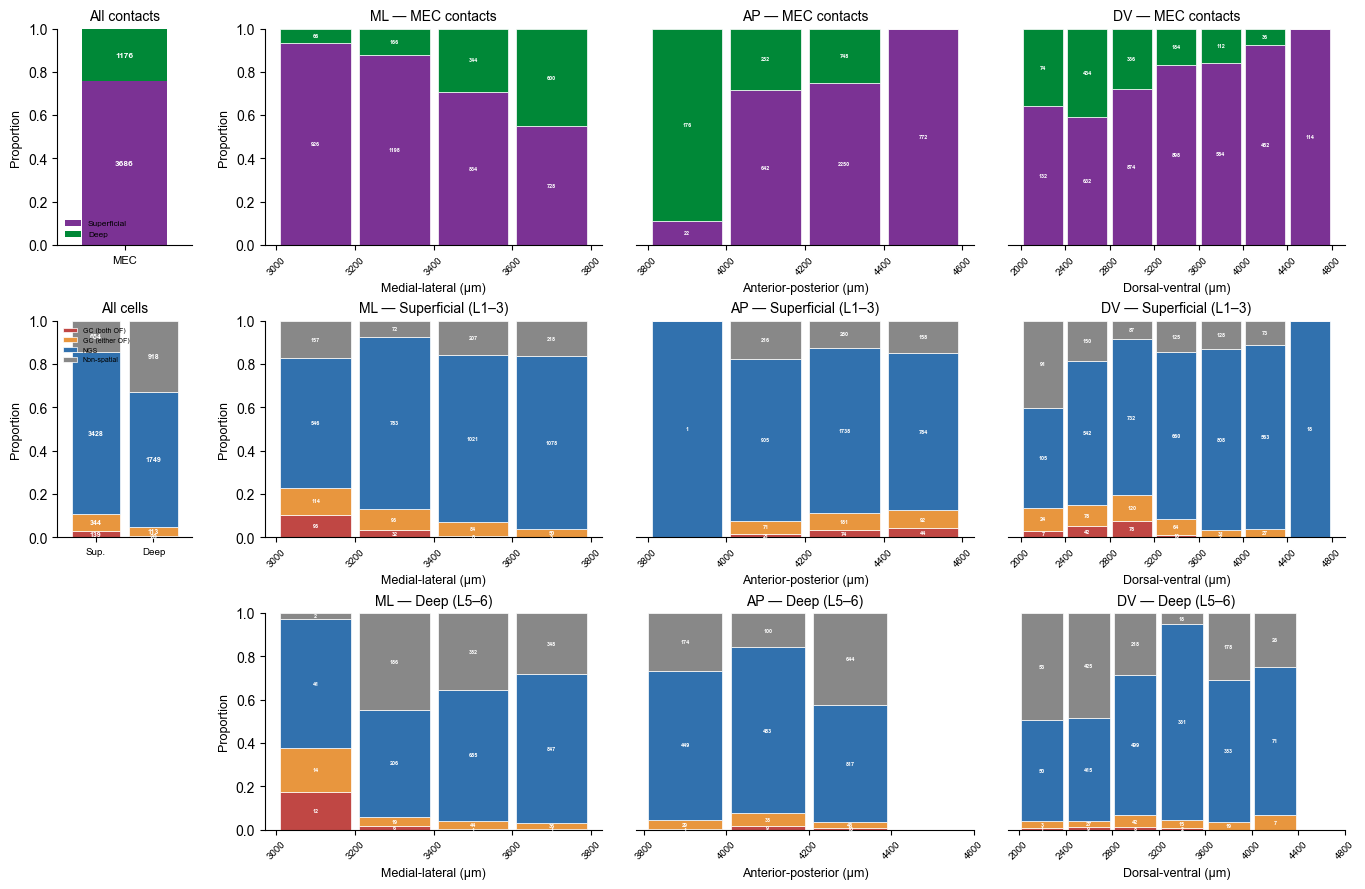

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Arial'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()
_cc['ml'] = _cc['SC_x'].abs()
_cc['dv'] = _cc['SC_y']
_cc['ap'] = _cc['SC_z']

def get_layer(region):
    if not isinstance(region, str):
        return None
    r = region.upper()
    if any(x in r for x in ['ENTM1', 'ENTM2', 'ENTM3']):
        return 'Superficial'
    elif any(x in r for x in ['ENTM5', 'ENTM6']):
        return 'Deep'
    return None

_cc['_layer'] = _cc['brain_region'].apply(get_layer)

cats = []
for _, row in _cc.iterrows():
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        if cb == 'both':
            cats.append('GC_both')
        else:
            cats.append('GC_either')
    elif row['cell_type'] == 'NG':
        cats.append('NGS')
    else:
        cats.append('Other')
_cc['_cat'] = cats

dc = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
dc = dc[dc['mouse'] != 22]
dc = dc[dc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()
dc['ml'] = dc['coord_SCs_x'].abs()
dc['dv'] = dc['coord_SCs_y']
dc['ap'] = dc['coord_SCs_z']
dc['_layer'] = dc['brain_region'].apply(get_layer)

ml_bins = np.arange(3000, 3801, 200)
ap_bins = np.arange(3800, 4701, 200)
dv_bins = np.arange(2000, 4801, 400)

cat_order = ['GC_both', 'GC_either', 'NGS', 'Other']
cat_colors = {'GC_both': '#c04744', 'GC_either': '#e8963e', 'NGS': '#3171ae', 'Other': '#888888'}
cat_labels = {'GC_both': 'GC (both OF)', 'GC_either': 'GC (either OF)', 'NGS': 'NGS', 'Other': 'Non-spatial'}

layer_order = ['Superficial', 'Deep']
layer_colors = {'Superficial': '#7b3294', 'Deep': '#008837'}

fig = plt.figure(figsize=(14, 9))
outer = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[0.5, 4], wspace=0.12, hspace=0.35,
                          top=0.95, bottom=0.06, left=0.05, right=0.97)

# ── Row 0, col 0: overall contact layer proportions ──────────────────────────
ax_sum_contacts = fig.add_subplot(outer[0, 0])

n_sup = (dc['_layer'] == 'Superficial').sum()
n_deep = (dc['_layer'] == 'Deep').sum()
n_total = n_sup + n_deep
fracs = [n_sup / n_total, n_deep / n_total]

ax_sum_contacts.bar([0], [fracs[0]], width=0.5, color=layer_colors['Superficial'], label='Superficial')
ax_sum_contacts.bar([0], [fracs[1]], width=0.5, bottom=[fracs[0]], color=layer_colors['Deep'], label='Deep')
ax_sum_contacts.text(0, fracs[0] / 2, f'{n_sup}', ha='center', va='center', fontsize=6, color='white', fontweight='bold')
ax_sum_contacts.text(0, fracs[0] + fracs[1] / 2, f'{n_deep}', ha='center', va='center', fontsize=6, color='white', fontweight='bold')
ax_sum_contacts.set_ylabel('Proportion', fontsize=9)
ax_sum_contacts.set_title('All contacts', fontsize=10)
ax_sum_contacts.set_xticks([0])
ax_sum_contacts.set_xticklabels(['MEC'], fontsize=8)
ax_sum_contacts.set_xlim(-0.4, 0.4)
ax_sum_contacts.set_ylim(0, 1)
ax_sum_contacts.spines[['top', 'right']].set_visible(False)
ax_sum_contacts.legend(fontsize=6, frameon=False)

# ── Row 1, col 0: superficial and deep cell type proportions side by side ────
ax_sum_cells = fig.add_subplot(outer[1, 0])

x_pos = [0, 0.6]
for i, layer in enumerate(layer_order):
    df_layer = _cc[_cc['_layer'] == layer]
    total = len(df_layer)
    if total > 0:
        bottom_val = 0
        for cat in cat_order:
            n = (df_layer['_cat'] == cat).sum()
            frac = n / total
            label = cat_labels[cat] if i == 0 else None
            ax_sum_cells.bar([x_pos[i]], [frac], width=0.5, bottom=[bottom_val],
                             color=cat_colors[cat], label=label, edgecolor='white', lw=0.5)
            if n > 0:
                ax_sum_cells.text(x_pos[i], bottom_val + frac / 2, f'{n}', ha='center', va='center',
                                  fontsize=5, color='white', fontweight='bold')
            bottom_val += frac

layer_xlabels = ['Sup.', 'Deep']
ax_sum_cells.set_ylabel('Proportion', fontsize=9)
ax_sum_cells.set_title('All cells', fontsize=10)
ax_sum_cells.set_xticks(x_pos)
ax_sum_cells.set_xticklabels(layer_xlabels, fontsize=7)
ax_sum_cells.set_xlim(-0.4, 1.0)
ax_sum_cells.set_ylim(0, 1)
ax_sum_cells.spines[['top', 'right']].set_visible(False)
ax_sum_cells.legend(fontsize=5, frameon=False, loc='upper left')

# ── Row 2, col 0: blank ─────────────────────────────────────────────────────
ax_blank = fig.add_subplot(outer[2, 0])
ax_blank.axis('off')

# ── Right columns: axis-specific plots ───────────────────────────────────────
right_row0 = outer[0, 1].subgridspec(1, 3, wspace=0.1)

for col_idx, (pos_col_contacts, bins, xlabel, axis_name) in enumerate([
    ('ml', ml_bins, 'Medial-lateral (µm)', 'ML'),
    ('ap', ap_bins, 'Anterior-posterior (µm)', 'AP'),
    ('dv', dv_bins, 'Dorsal-ventral (µm)', 'DV'),
]):
    centres = (bins[:-1] + bins[1:]) / 2
    bar_w = (bins[1] - bins[0]) * 0.9

    ax = fig.add_subplot(right_row0[0, col_idx])
    dc['_bin'] = pd.cut(dc[pos_col_contacts], bins=bins, right=False)

    counts_layer = dc.groupby(['_bin', '_layer']).size().unstack(fill_value=0)
    for c in layer_order:
        if c not in counts_layer.columns:
            counts_layer[c] = 0
    counts_layer = counts_layer[layer_order]
    props_layer = counts_layer.div(counts_layer.sum(axis=1), axis=0)

    bottom = np.zeros(len(props_layer))
    for layer in layer_order:
        vals = props_layer[layer].values
        ax.bar(centres, vals, width=bar_w, bottom=bottom,
               color=layer_colors[layer], edgecolor='white', lw=0.5)
        for k, (centre, val) in enumerate(zip(centres, vals)):
            count = int(counts_layer[layer].values[k])
            if count > 0:
                ax.text(centre, bottom[k] + val / 2, f'{count}',
                        ha='center', va='center', fontsize=4, color='white', fontweight='bold')
        bottom += vals

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(f'{axis_name} — MEC contacts', fontsize=10)
    ax.set_xticks(bins)
    ax.set_xticklabels([f'{int(e)}' for e in bins], fontsize=7, rotation=45)
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)
    if col_idx > 0:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)
        ax.set_yticks([])
    else:
        ax.set_ylabel('Proportion', fontsize=9)

for row_idx, layer in enumerate(layer_order):
    right_row = outer[row_idx + 1, 1].subgridspec(1, 3, wspace=0.1)

    for col_idx, (pos_col_cells, bins, xlabel, axis_name) in enumerate([
        ('ml', ml_bins, 'Medial-lateral (µm)', 'ML'),
        ('ap', ap_bins, 'Anterior-posterior (µm)', 'AP'),
        ('dv', dv_bins, 'Dorsal-ventral (µm)', 'DV'),
    ]):
        centres = (bins[:-1] + bins[1:]) / 2
        bar_w = (bins[1] - bins[0]) * 0.9

        ax = fig.add_subplot(right_row[0, col_idx])

        df_layer = _cc[_cc['_layer'] == layer].copy()
        df_layer['_bin'] = pd.cut(df_layer[pos_col_cells], bins=bins, right=False)

        counts = df_layer.groupby(['_bin', '_cat']).size().unstack(fill_value=0)
        for c in cat_order:
            if c not in counts.columns:
                counts[c] = 0
        counts = counts[cat_order]
        proportions = counts.div(counts.sum(axis=1), axis=0)

        bottom = np.zeros(len(proportions))
        for cat in cat_order:
            vals = proportions[cat].values
            ax.bar(centres, vals, width=bar_w, bottom=bottom,
                   color=cat_colors[cat], edgecolor='white', lw=0.5)
            for k, (centre, val) in enumerate(zip(centres, vals)):
                count = int(counts[cat].values[k])
                if count > 0:
                    ax.text(centre, bottom[k] + val / 2, f'{count}',
                            ha='center', va='center', fontsize=4, color='white', fontweight='bold')
            bottom += vals

        layer_label = f'{layer} (L1–3)' if layer == 'Superficial' else f'{layer} (L5–6)'
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_title(f'{axis_name} — {layer_label}', fontsize=10)
        ax.set_xticks(bins)
        ax.set_xticklabels([f'{int(e)}' for e in bins], fontsize=7, rotation=45)
        ax.set_ylim(0, 1)
        ax.spines[['top', 'right']].set_visible(False)
        if col_idx > 0:
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)
            ax.set_yticks([])
        else:
            ax.set_ylabel('Proportion', fontsize=9)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/entm_contacts_and_layers_3axes.pdf',
            bbox_inches='tight', dpi=300)
plt.show()

_cc.drop(columns=['_cat', '_layer', '_bin'], inplace=True, errors='ignore')


Figure 1: 7365 ENTm cells, 7 mice, 60 sessions

AIC: main=-2089.9, inter=-2078.6, quad=-2074.6
Best: main
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: si       
No. Observations: 7365    Method:             REML     
No. Groups:       7       Scale:              0.0429   
Min. group size:  263     Log-Likelihood:     1049.9617
Max. group size:  2212    Converged:          Yes      
Mean group size:  1052.1                               
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.146    0.010 14.257 0.000  0.126  0.166
ml_z         -0.036    0.004 -9.402 0.000 -0.044 -0.029
dv_z          0.002    0.004  0.497 0.619 -0.006  0.010
session Var   0.006    0.006                           



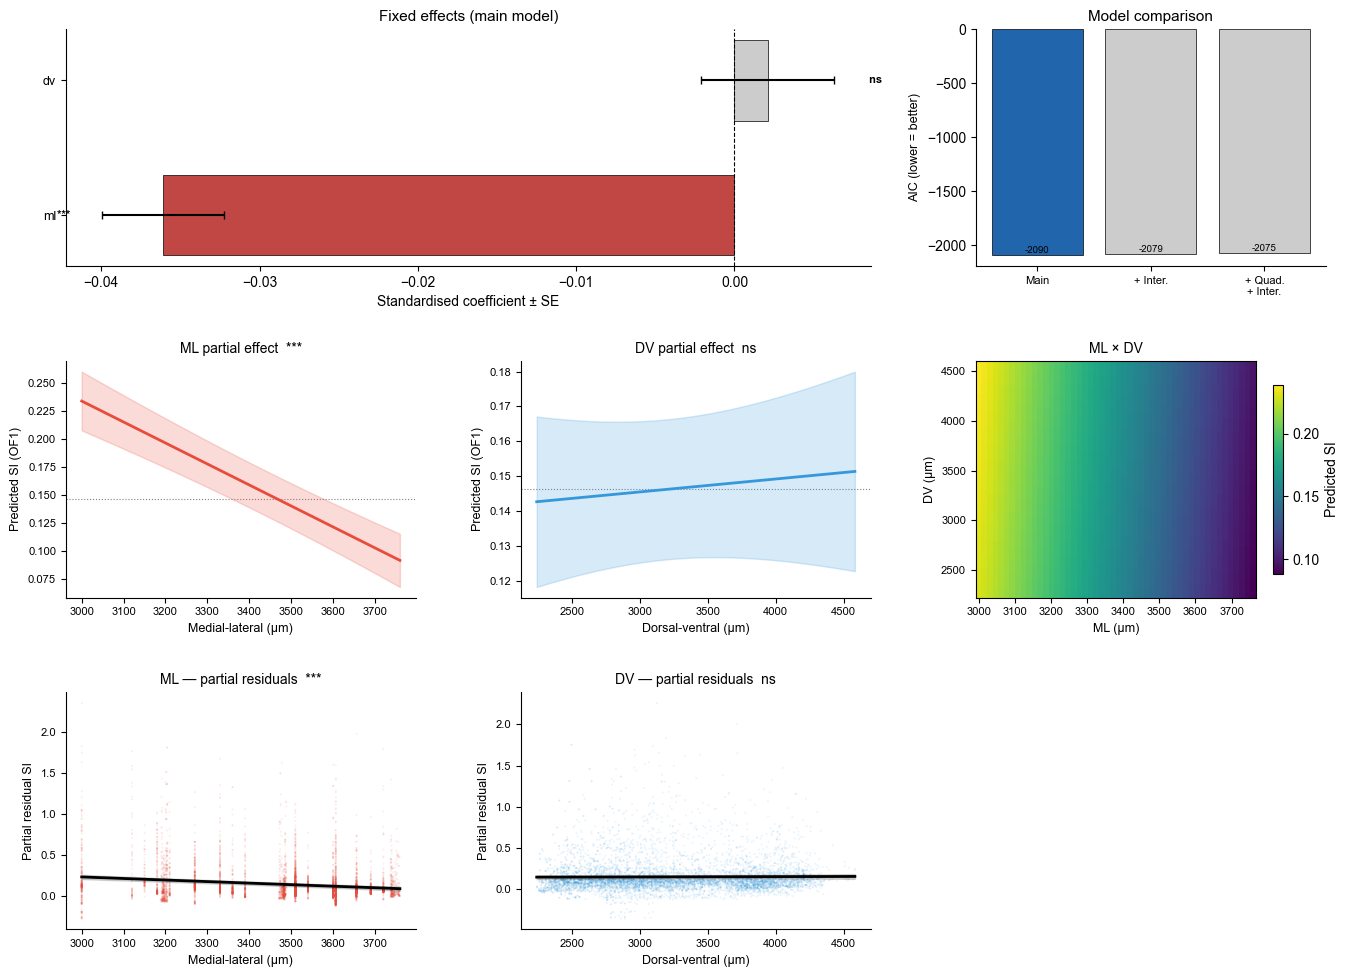

In [53]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

# ── Load and prepare data ────────────────────────────────────────────────────
_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

df = _cc[_cc['spatial_information_score_of1'].notna()].copy()
df['ml'] = df['SC_x'].abs()
df['dv'] = df['SC_y']
df['si'] = df['spatial_information_score_of1']
df['_mouse'] = df['mouse'].astype(int)
df['_session'] = df['_mouse'].astype(str) + '_' + df['day'].astype(int).astype(str)
df['ml_z'] = (df['ml'] - df['ml'].mean()) / df['ml'].std()
df['dv_z'] = (df['dv'] - df['dv'].mean()) / df['dv'].std()

print(f"Figure 1: {len(df)} ENTm cells, {df['_mouse'].nunique()} mice, {df['_session'].nunique()} sessions")

# ── Fit models ───────────────────────────────────────────────────────────────
vc = {"session": "0 + C(_session)"}

m1 = smf.mixedlm("si ~ ml_z + dv_z", df, groups=df["_mouse"], vc_formula=vc)
r1 = m1.fit(method="powell", maxiter=5000, disp=False)

m2 = smf.mixedlm("si ~ ml_z + dv_z + ml_z:dv_z", df, groups=df["_mouse"], vc_formula=vc)
r2 = m2.fit(method="powell", maxiter=5000, disp=False)

m3 = smf.mixedlm("si ~ ml_z + dv_z + I(ml_z**2) + I(dv_z**2) + ml_z:dv_z", df,
                  groups=df["_mouse"], vc_formula=vc)
r3 = m3.fit(method="powell", maxiter=5000, disp=False)

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

results = {'main': r1, 'inter': r2, 'quad': r3}
aic_vals = {n: manual_aic(r) for n, r in results.items()}
best_name = min(aic_vals, key=aic_vals.get)
best = results[best_name]

print(f"\nAIC: main={aic_vals['main']:.1f}, inter={aic_vals['inter']:.1f}, quad={aic_vals['quad']:.1f}")
print(f"Best: {best_name}")
print(best.summary())

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def z_to_real(z_vals, z_col):
    real_col = z_col.replace('_z', '')
    return z_vals * df[real_col].std() + df[real_col].mean()

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row_simple(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, z_col, z_vals):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {'ml_z': 0, 'dv_z': 0}
        d[z_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row_simple(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def get_contribution(result, z_col, z_vals):
    contrib = np.zeros_like(z_vals, dtype=float)
    for term, coef in result.fe_params.items():
        if term == z_col:
            contrib += coef * z_vals
        elif term == f'I({z_col}**2)':
            contrib += coef * z_vals ** 2
    return contrib

df['_fitted'] = best.fittedvalues
n_pts = 200

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(3, 3, figure=fig, wspace=0.3, hspace=0.4,
                          top=0.95, bottom=0.05, left=0.07, right=0.97)

axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', '#e74c3c'),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', '#3498db'),
]

# ── Row 0: Coefficients + AIC ────────────────────────────────────────────────
ax_coef = fig.add_subplot(outer[0, 0:2])

fe = best.fe_params.drop('Intercept')
se_coef = best.bse.reindex(fe.index)
pvals = best.pvalues.reindex(fe.index)
display_names = [n.replace('_z', '').replace('I(', '').replace('**2)', '²').replace(':', ' × ')
                 for n in fe.index]
colors_coef = ['#c04744' if p < 0.05 else '#cccccc' for p in pvals]
y_pos = np.arange(len(fe))

ax_coef.barh(y_pos, fe.values, xerr=se_coef.values, color=colors_coef,
             edgecolor='black', lw=0.5, capsize=3, height=0.6)
ax_coef.set_yticks(y_pos)
ax_coef.set_yticklabels(display_names, fontsize=9)
ax_coef.axvline(0, color='black', lw=0.8, ls='--')
ax_coef.set_xlabel('Standardised coefficient ± SE', fontsize=10)
ax_coef.set_title(f'Fixed effects ({best_name} model)', fontsize=11)
ax_coef.spines[['top', 'right']].set_visible(False)

for i, (coef, p) in enumerate(zip(fe.values, pvals)):
    stars = pval_to_stars(p)
    x_off = se_coef.values[i] + 0.002 if coef >= 0 else -se_coef.values[i] - 0.002
    ax_coef.text(coef + x_off, i, f' {stars}', ha='left' if coef >= 0 else 'right',
                 va='center', fontsize=8, fontweight='bold')

ax_aic = fig.add_subplot(outer[0, 2])
names_disp = ['Main', '+ Inter.', '+ Quad.\n+ Inter.']
aic_list = [aic_vals['main'], aic_vals['inter'], aic_vals['quad']]
aic_col = ['#2166ac' if n == best_name else '#cccccc' for n in ['main', 'inter', 'quad']]
ax_aic.bar(range(3), aic_list, color=aic_col, edgecolor='black', lw=0.5)
ax_aic.set_xticks(range(3))
ax_aic.set_xticklabels(names_disp, fontsize=8)
ax_aic.set_ylabel('AIC (lower = better)', fontsize=9)
ax_aic.set_title('Model comparison', fontsize=11)
ax_aic.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(aic_list):
    ax_aic.text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

# ── Row 1: Partial effects with CI ──────────────────────────────────────────
for col_idx, (z_col, real_col, xlabel, color) in enumerate(axes_info):
    ax = fig.add_subplot(outer[1, col_idx])
    z_vals = np.linspace(df[z_col].min(), df[z_col].max(), n_pts)
    real_vals = z_to_real(z_vals, z_col)
    pred, se_pred = partial_with_se(best, z_col, z_vals)

    ax.plot(real_vals, pred, color=color, lw=2, zorder=4)
    ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                    color=color, alpha=0.2, zorder=3)
    ax.axhline(best.fe_params['Intercept'], color='grey', ls=':', lw=0.8)

    p_main = best.pvalues.get(z_col, np.nan)
    ax.set_title(f'{real_col.upper()} partial effect  {pval_to_stars(p_main)}', fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Predicted SI (OF1)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# ML × DV heatmap
ax_hm = fig.add_subplot(outer[1, 2])
n_grid = 50
ml_z_r = np.linspace(df['ml_z'].min(), df['ml_z'].max(), n_grid)
dv_z_r = np.linspace(df['dv_z'].min(), df['dv_z'].max(), n_grid)
MZ, DZ = np.meshgrid(ml_z_r, dv_z_r)
pred_grid = np.array([[predict_simple(best, {'ml_z': MZ[i,j], 'dv_z': DZ[i,j]})
                        for j in range(n_grid)] for i in range(n_grid)])
ml_real = z_to_real(ml_z_r, 'ml_z')
dv_real = z_to_real(dv_z_r, 'dv_z')
im = ax_hm.pcolormesh(ml_real, dv_real, pred_grid, cmap='viridis', shading='auto', rasterized=True)
plt.colorbar(im, ax=ax_hm, label='Predicted SI', shrink=0.8)
inter_term = 'ml_z:dv_z'
if inter_term in best.pvalues:
    p_i = best.pvalues[inter_term]
    ax_hm.set_title(f'ML × DV  {pval_to_stars(p_i)} (p={p_i:.2g})', fontsize=10)
else:
    ax_hm.set_title('ML × DV', fontsize=10)
ax_hm.set_xlabel('ML (µm)', fontsize=9)
ax_hm.set_ylabel('DV (µm)', fontsize=9)
ax_hm.tick_params(labelsize=8)

# ── Row 2: Partial residuals with CI ─────────────────────────────────────────
for col_idx, (z_col, real_col, xlabel, color) in enumerate(axes_info):
    ax = fig.add_subplot(outer[2, col_idx])

    contrib = get_contribution(best, z_col, df[z_col].values)
    intercept = best.fe_params['Intercept']
    partial_resid = df['si'] - df['_fitted'] + contrib + intercept

    ax.scatter(df[real_col], partial_resid, c=color, s=2, alpha=0.1,
               rasterized=True, zorder=1, edgecolors='none')

    z_vals = np.linspace(df[z_col].min(), df[z_col].max(), n_pts)
    real_vals = z_to_real(z_vals, z_col)
    pred, se_pred = partial_with_se(best, z_col, z_vals)

    ax.plot(real_vals, pred, color='black', lw=2, zorder=4)
    ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                    color='black', alpha=0.15, zorder=3)

    p_main = best.pvalues.get(z_col, np.nan)
    ax.set_title(f'{real_col.upper()} — partial residuals  {pval_to_stars(p_main)}', fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Partial residual SI', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# Blank bottom right
ax_blank = fig.add_subplot(outer[2, 2])
ax_blank.axis('off')

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/si_ml_dv_glmm.pdf',
            bbox_inches='tight', dpi=300)
plt.show()



7365 ENTm cells, 7 mice
Layer counts: {'L1': 688, 'L2': 1394, 'L3': 2483, 'L5': 2225, 'L6': 575}

SI model: quad (AIC: {'main': np.float64(-2085.245105727103), 'inter': np.float64(-2121.957849297978), 'quad': np.float64(-2284.610727806634)})
          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  si       
No. Observations:  7365     Method:              REML     
No. Groups:        7        Scale:               0.0415   
Min. group size:   263      Log-Likelihood:      1154.3054
Max. group size:   2212     Converged:           Yes      
Mean group size:   1052.1                                 
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.096    0.011  8.765 0.000  0.075  0.117
ml_z            -0.017    0.005 -3.282 0.001 -0.028 -0.007
dv_z            -0.001    0.005 -0.251 0.802 -0.012  0.009
la

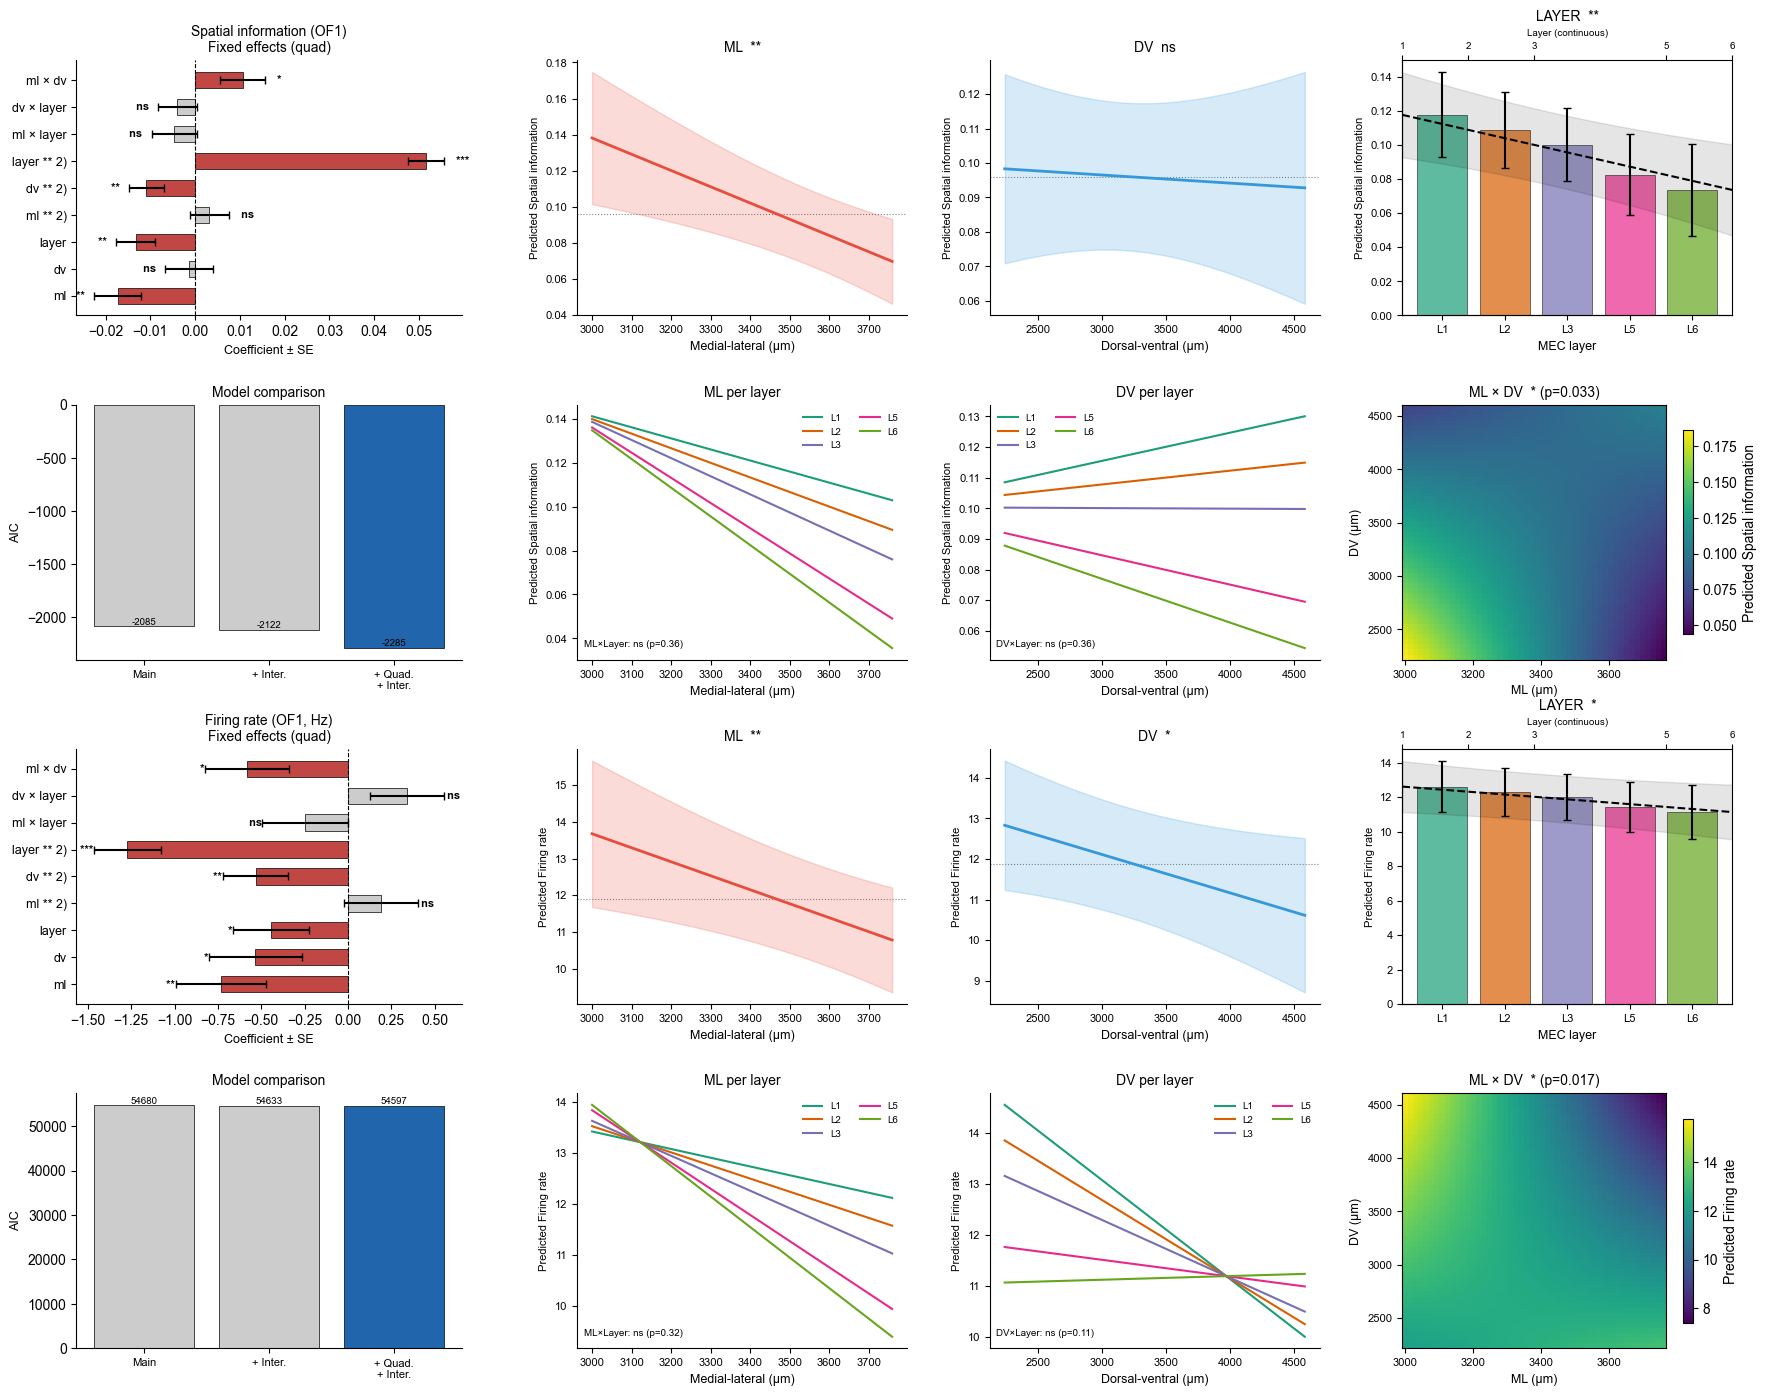

In [61]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

# ── Load and prepare data ────────────────────────────────────────────────────
_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

df = _cc.copy()
df['ml'] = df['SC_x'].abs()
df['dv'] = df['SC_y']
df['si'] = df['spatial_information_score_of1']
df['fr'] = df['firing_rate_OF1']
df['_mouse'] = df['mouse'].astype(int)
df['_session'] = df['_mouse'].astype(str) + '_' + df['day'].astype(int).astype(str)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

df['layer_num'] = df['brain_region'].apply(get_layer_num)
df = df[df['layer_num'].notna()].copy()
df['layer_label'] = 'L' + df['layer_num'].astype(int).astype(str)

df['ml_z'] = (df['ml'] - df['ml'].mean()) / df['ml'].std()
df['dv_z'] = (df['dv'] - df['dv'].mean()) / df['dv'].std()
df['layer_z'] = (df['layer_num'] - df['layer_num'].mean()) / df['layer_num'].std()

print(f"{len(df)} ENTm cells, {df['_mouse'].nunique()} mice")
print(f"Layer counts: {df['layer_label'].value_counts().sort_index().to_dict()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def z_to_real(z_vals, z_col):
    real_col = z_col.replace('_z', '')
    if real_col == 'layer':
        return z_vals * df['layer_num'].std() + df['layer_num'].mean()
    return z_vals * df[real_col].std() + df[real_col].mean()

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def layer_num_to_z(ln):
    return (ln - df['layer_num'].mean()) / df['layer_num'].std()

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)

    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)

    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)

    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
layer_weights = np.array([len(df[df['layer_num'] == ln]) for ln in layer_nums], dtype=float)
layer_weights /= layer_weights.sum()

n_pts = 200

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', '#e74c3c'),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', '#3498db'),
    ('layer_z', 'layer', 'MEC layer', '#2ca02c'),
]

# ── Fit models ───────────────────────────────────────────────────────────────
df_si = df[df['si'].notna()].copy()
best_si, best_si_name, aic_si = fit_and_select('si', df_si)
df_si['_fitted'] = best_si.fittedvalues
print(f"\nSI model: {best_si_name} (AIC: {aic_si})")
print(best_si.summary())

df_fr = df[df['fr'].notna()].copy()
best_fr, best_fr_name, aic_fr = fit_and_select('fr', df_fr)
df_fr['_fitted'] = best_fr.fittedvalues
print(f"\nFR model: {best_fr_name} (AIC: {aic_fr})")
print(best_fr.summary())

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE: 4 rows × 2 columns (left: coefficients/AIC, right: 3 partial effects)
# Rows 0-1: Spatial information
# Rows 2-3: Firing rate
# ══════════════════════════════════════════════════════════════════════════════

measures = [
    ('Spatial information (OF1)', 'si', df_si, best_si, best_si_name, aic_si),
    ('Firing rate (OF1, Hz)', 'fr', df_fr, best_fr, best_fr_name, aic_fr),
]

fig = plt.figure(figsize=(18, 14))
outer = gridspec.GridSpec(4, 2, figure=fig, width_ratios=[1, 3], wspace=0.15, hspace=0.35,
                          top=0.96, bottom=0.04, left=0.05, right=0.97)

for m_idx, (measure_label, dv_col, df_m, best_m, best_m_name, aic_m) in enumerate(measures):
    row_coef = m_idx * 2
    row_partial = m_idx * 2
    row_inter = m_idx * 2 + 1

    # ── Left: Coefficients ───────────────────────────────────────────────────
    ax_coef = fig.add_subplot(outer[row_coef, 0])

    fe = best_m.fe_params.drop('Intercept')
    se_coef = best_m.bse.reindex(fe.index)
    pvals_fe = best_m.pvalues.reindex(fe.index)
    display_names = [n.replace('_z', '').replace('I(', '').replace('**2)', '²').replace(':', ' × ')
                     for n in fe.index]
    colors_coef = ['#c04744' if p < 0.05 else '#cccccc' for p in pvals_fe]
    y_pos = np.arange(len(fe))

    ax_coef.barh(y_pos, fe.values, xerr=se_coef.values, color=colors_coef,
                 edgecolor='black', lw=0.5, capsize=3, height=0.6)
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels(display_names, fontsize=9)
    ax_coef.axvline(0, color='black', lw=0.8, ls='--')
    ax_coef.set_xlabel('Coefficient ± SE', fontsize=9)
    ax_coef.set_title(f'{measure_label}\nFixed effects ({best_m_name})', fontsize=10)
    ax_coef.spines[['top', 'right']].set_visible(False)

    for i, (coef, p) in enumerate(zip(fe.values, pvals_fe)):
        stars = pval_to_stars(p)
        x_off = se_coef.values[i] + 0.002 if coef >= 0 else -se_coef.values[i] - 0.002
        ax_coef.text(coef + x_off, i, f' {stars}', ha='left' if coef >= 0 else 'right',
                     va='center', fontsize=8, fontweight='bold')

    # ── Left: AIC ────────────────────────────────────────────────────────────
    ax_aic = fig.add_subplot(outer[row_inter, 0])
    names_disp = ['Main', '+ Inter.', '+ Quad.\n+ Inter.']
    aic_list = [aic_m['main'], aic_m['inter'], aic_m['quad']]
    aic_col = ['#2166ac' if n == best_m_name else '#cccccc' for n in ['main', 'inter', 'quad']]
    ax_aic.bar(range(3), aic_list, color=aic_col, edgecolor='black', lw=0.5)
    ax_aic.set_xticks(range(3))
    ax_aic.set_xticklabels(names_disp, fontsize=8)
    ax_aic.set_ylabel('AIC', fontsize=9)
    ax_aic.set_title('Model comparison', fontsize=10)
    ax_aic.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(aic_list):
        ax_aic.text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

    # ── Right row 0: Partial effects with CI ─────────────────────────────────
    right_partial = outer[row_partial, 1].subgridspec(1, 3, wspace=0.25)

    for col_idx, (z_col, real_col, xlabel, color) in enumerate(all_axes_info):
        ax = fig.add_subplot(right_partial[0, col_idx])
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        if z_col == 'layer_z':
            params_list = list(best_m.fe_params.keys())
            cov_mat = best_m.cov_params().loc[params_list, params_list].values
            lz_vals = np.array([layer_num_to_z(ln) for ln in layer_nums])
            pred_vals, se_vals = [], []
            for lz in lz_vals:
                d = {c: 0 for c in hold_others}; d[z_col] = lz
                pred_vals.append(predict_simple(best_m, d))
                x_row = get_design_row(best_m, d)
                se_vals.append(np.sqrt(x_row @ cov_mat @ x_row))
            pred_vals = np.array(pred_vals)
            se_vals = np.array(se_vals)

            ax.bar(np.arange(len(layer_nums)), pred_vals, yerr=1.96*se_vals, capsize=3,
                   color=[layer_colors[f'L{ln}'] for ln in layer_nums], edgecolor='black',
                   lw=0.5, alpha=0.7, zorder=3)

            z_cont = np.linspace(df_m['layer_z'].min(), df_m['layer_z'].max(), n_pts)
            real_cont = z_to_real(z_cont, 'layer_z')
            pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)
            ax2 = ax.twiny()
            ax2.plot(real_cont, pred_cont, color='black', lw=1.5, ls='--', zorder=5)
            ax2.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                             color='black', alpha=0.1, zorder=4)
            ax2.set_xlim(real_cont[0], real_cont[-1])
            ax2.set_xticks([1, 2, 3, 5, 6])
            ax2.tick_params(labelsize=7)
            ax2.set_xlabel('Layer (continuous)', fontsize=7)

            ax.set_xticks(np.arange(len(layer_nums)))
            ax.set_xticklabels(layer_labels, fontsize=9)
        else:
            z_vals = np.linspace(df_m[z_col].min(), df_m[z_col].max(), n_pts)
            real_vals = z_to_real(z_vals, z_col)
            pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)
            ax.plot(real_vals, pred, color=color, lw=2, zorder=4)
            ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                            color=color, alpha=0.2, zorder=3)
            ax.axhline(best_m.fe_params['Intercept'], color='grey', ls=':', lw=0.8)

        p_main = best_m.pvalues.get(z_col, np.nan)
        ax.set_title(f'{real_col.upper()}  {pval_to_stars(p_main)}', fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(f'Predicted {measure_label.split("(")[0].strip()}', fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    # ── Right row 1: Per-layer ML/DV effects + heatmap ───────────────────────
    right_inter = outer[row_inter, 1].subgridspec(1, 3, wspace=0.25)

    ax_ml_l = fig.add_subplot(right_inter[0, 0])
    z_ml = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_pts)
    r_ml = z_to_real(z_ml, 'ml_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': z, 'dv_z': 0, 'layer_z': lz}) for z in z_ml]
        ax_ml_l.plot(r_ml, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_ml_l.set_xlabel('Medial-lateral (µm)', fontsize=9)
    ax_ml_l.set_ylabel(f'Predicted {measure_label.split("(")[0].strip()}', fontsize=8)
    ax_ml_l.set_title('ML per layer', fontsize=10)
    ax_ml_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_ml_l.spines[['top', 'right']].set_visible(False)
    ax_ml_l.tick_params(labelsize=8)
    if 'ml_z:layer_z' in best_m.pvalues:
        p_mli = best_m.pvalues['ml_z:layer_z']
        ax_ml_l.annotate(f'ML×Layer: {pval_to_stars(p_mli)} (p={p_mli:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_dv_l = fig.add_subplot(right_inter[0, 1])
    z_dv = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_pts)
    r_dv = z_to_real(z_dv, 'dv_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': 0, 'dv_z': z, 'layer_z': lz}) for z in z_dv]
        ax_dv_l.plot(r_dv, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_dv_l.set_xlabel('Dorsal-ventral (µm)', fontsize=9)
    ax_dv_l.set_ylabel(f'Predicted {measure_label.split("(")[0].strip()}', fontsize=8)
    ax_dv_l.set_title('DV per layer', fontsize=10)
    ax_dv_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_dv_l.spines[['top', 'right']].set_visible(False)
    ax_dv_l.tick_params(labelsize=8)
    if 'dv_z:layer_z' in best_m.pvalues:
        p_dvl = best_m.pvalues['dv_z:layer_z']
        ax_dv_l.annotate(f'DV×Layer: {pval_to_stars(p_dvl)} (p={p_dvl:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_hm = fig.add_subplot(right_inter[0, 2])
    n_grid = 50
    ml_zr = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_grid)
    dv_zr = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_grid)
    MZ, DZ = np.meshgrid(ml_zr, dv_zr)
    pg = np.zeros_like(MZ)
    for ln, w in zip(layer_nums, layer_weights):
        lz = layer_num_to_z(ln)
        for i in range(n_grid):
            for j in range(n_grid):
                pg[i, j] += w * predict_simple(best_m, {'ml_z': MZ[i,j], 'dv_z': DZ[i,j], 'layer_z': lz})
    ml_r = z_to_real(ml_zr, 'ml_z')
    dv_r = z_to_real(dv_zr, 'dv_z')
    im = ax_hm.pcolormesh(ml_r, dv_r, pg, cmap='viridis', shading='auto', rasterized=True)
    plt.colorbar(im, ax=ax_hm, shrink=0.8,
                 label=f'Predicted {measure_label.split("(")[0].strip()}')
    if 'ml_z:dv_z' in best_m.pvalues:
        p_mlvd = best_m.pvalues['ml_z:dv_z']
        ax_hm.set_title(f'ML × DV  {pval_to_stars(p_mlvd)} (p={p_mlvd:.2g})', fontsize=10)
    else:
        ax_hm.set_title('ML × DV', fontsize=10)
    ax_hm.set_xlabel('ML (µm)', fontsize=9)
    ax_hm.set_ylabel('DV (µm)', fontsize=9)
    ax_hm.tick_params(labelsize=8)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/si_fr_layer_glmm.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


In [9]:
device_contacts = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])

GC catalogue: 193 cells (classified_by=both, hit trials only)


KeyboardInterrupt: 

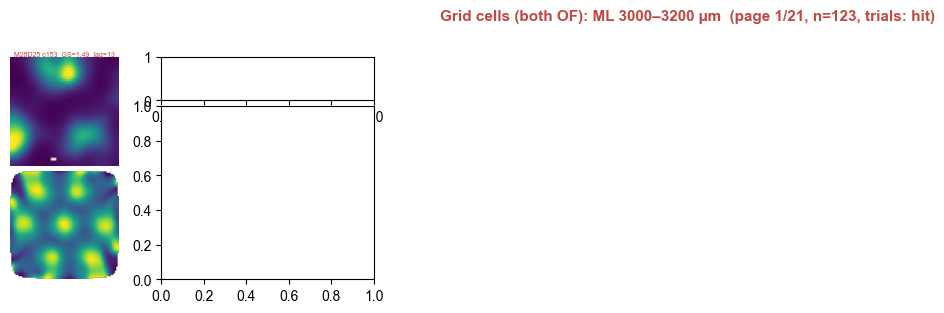

In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from matplotlib.backends.backend_pdf import PdfPages
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
    compute_vr_tcs, autocorr2d, white_to_hex_cmap,
    get_avg_profile, bs, tl, time_bs
)
from spatial_manifolds.behaviour_plots import plot_firing_rate_map
from scipy.ndimage import gaussian_filter

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'

COL_GC  = '#c04744'
COL_NGS = '#3171ae'
CMAP_GC  = white_to_hex_cmap('#c04744')
CMAP_NGS = white_to_hex_cmap('#3171ae')

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"

    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)

    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)

    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))

    ax.imshow(tc, cmap='viridis')
    ax.axis('off')
    return tc

def plot_autocorrelogram(ax, tc):
    ac = autocorr2d(tc)
    ax.imshow(ac, cmap='viridis', origin='lower')
    ax.axis('off')

def get_trial_performance_mask(beh, last_ephys_bin, trial_performances):
    bpt = int(tl / bs)
    n_trials = int(last_ephys_bin / bpt)
    trials = beh['trials']
    mask = np.zeros(n_trials, dtype=bool)
    for i in range(min(n_trials, len(trials))):
        perf = trials[i]['performance'].iloc[0]
        if perf in trial_performances:
            mask[i] = True
    return mask

def plot_vr_filtered(ax_vr, ax_avg, tc_vr, beh, last_ephys_bin, vr_cmap, trial_performances):
    bpt = int(tl / bs)
    n_trials = int(len(tc_vr) / bpt)
    trial_rate_map = np.array([tc_vr[int(i*bpt):int((i+1)*bpt)] for i in range(n_trials)])

    perf_mask = get_trial_performance_mask(beh, last_ephys_bin, trial_performances)
    perf_mask = perf_mask[:n_trials]
    filtered_map = trial_rate_map[perf_mask]

    if len(filtered_map) == 0:
        ax_vr.axis('off')
        ax_avg.axis('off')
        return

    p = np.nanpercentile(filtered_map, 95)
    filtered_map = np.clip(filtered_map, a_min=None, a_max=p)

    x = np.arange(1, len(filtered_map) + 1)
    y = np.arange(0, filtered_map.shape[1] * bs, bs)
    Y, X = np.meshgrid(y, x)
    heatmap = ax_vr.pcolormesh(Y, X, filtered_map, shading='auto', cmap=vr_cmap)
    heatmap.set_rasterized(True)
    ax_vr.set_xlim(0, tl)
    ax_vr.set_ylim(0, len(filtered_map))
    ax_vr.invert_yaxis()
    ax_vr.set_yticks([])

    avg = np.nanmean(filtered_map, axis=0)
    x_pos = np.arange(bs / 2, tl + (bs / 2), bs)
    ax_avg.plot(x_pos[:len(avg)], avg, color='black', linewidth=0.8)
    ax_avg.set_xlim(0, tl)
    ax_avg.set_xticks([])
    ax_avg.spines[['top', 'right', 'bottom']].set_visible(False)
    ax_avg.tick_params(labelsize=5)

def plot_cell_quad(fig, gs_slot, mouse, day, cid, df, vr_cache, title_color, vr_cmap,
                   trial_performances=['hit', 'try', 'run']):
    inner = gs_slot.subgridspec(1, 2, wspace=0.08, width_ratios=[1, 1.3])
    inner_left  = inner[0, 0].subgridspec(2, 1, hspace=0.05, height_ratios=[1, 1])
    inner_right = inner[0, 1].subgridspec(2, 1, hspace=0.05, height_ratios=[1, 4])

    ax_of   = fig.add_subplot(inner_left[0, 0])
    ax_ac   = fig.add_subplot(inner_left[1, 0])
    ax_avg  = fig.add_subplot(inner_right[0, 0])
    ax_vr   = fig.add_subplot(inner_right[1, 0])

    # OF rate map
    tc_of = None
    try:
        tc_of = plot_of_rate_map(ax_of, cid, mouse, day, df, session='OF1')
        ex_row = df[(df['mouse'] == mouse) & (df['day'] == day) & (df['cluster_id'] == cid)]
        if len(ex_row) > 0:
            gs = ex_row.iloc[0].get('grid_score_best', np.nan)
            lag = ex_row.iloc[0].get('optimal_travel_lag', np.nan)
            ax_of.set_title(f'M{mouse}D{day} c{cid}  GS={gs:.2f}  lag={lag:.0f}', fontsize=5, pad=1, color=title_color)
        else:
            ax_of.set_title(f'M{mouse}D{day} c{cid}', fontsize=5, pad=1, color=title_color)
    except Exception as e:
        ax_of.text(0.5, 0.5, '—', ha='center', va='center',
                   transform=ax_of.transAxes, fontsize=10, color='grey')
        ax_of.axis('off')

    # Autocorrelogram
    if tc_of is not None:
        try:
            plot_autocorrelogram(ax_ac, tc_of)
        except Exception:
            ax_ac.axis('off')
    else:
        ax_ac.axis('off')

    # VR rate map + avg profile (filtered by trial performance)
    try:
        cache_key = (mouse, day)
        if cache_key not in vr_cache:
            tcs_vr, _, _, last_ephys_bin, beh_vr, _ = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False, source_path=SOURCE_PATH)
            vr_cache[cache_key] = (tcs_vr, last_ephys_bin, beh_vr)
        tcs_vr, last_ephys_bin, beh_vr = vr_cache[cache_key]

        tc_vr = tcs_vr[cid]
        tc_vr = gaussian_filter(np.nan_to_num(tc_vr).astype(np.float64), sigma=2.5)
        tc_vr = tc_vr[:last_ephys_bin]

        plot_vr_filtered(ax_vr, ax_avg, tc_vr, beh_vr, last_ephys_bin, vr_cmap, trial_performances)
    except Exception:
        ax_vr.axis('off')
        ax_avg.axis('off')


def generate_catalogue(cell_df, cell_type, title_color, vr_cmap, out_path, df_all, sort_col,
                       trial_performances=['hit', 'try', 'run']):
    cell_df = cell_df.copy()
    cell_df['ml'] = cell_df['SC_x'].abs()
    cell_df['dv'] = cell_df['SC_y']

    ml_bins = np.arange(3000, 3801, 200)
    CELLS_PER_PAGE = 6
    N_COLS = 3
    N_ROWS = 2
    vr_cache = {}

    with PdfPages(out_path) as pdf:
        for i_ml in range(len(ml_bins) - 1):
            ml_lo, ml_hi = ml_bins[i_ml], ml_bins[i_ml + 1]
            sub = cell_df[(cell_df['ml'] >= ml_lo) & (cell_df['ml'] < ml_hi)]
            sub = sub.sort_values(sort_col, ascending=False)

            if len(sub) == 0:
                continue

            n_pages = int(np.ceil(len(sub) / CELLS_PER_PAGE))

            for page in range(n_pages):
                page_cells = sub.iloc[page * CELLS_PER_PAGE : (page + 1) * CELLS_PER_PAGE]

                fig = plt.figure(figsize=(N_COLS * 5, N_ROWS * 3))
                grid = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, wspace=0.3, hspace=0.35,
                                         top=0.90, bottom=0.03, left=0.03, right=0.97)

                perf_str = ', '.join(trial_performances)
                fig.suptitle(
                    f'{cell_type}: ML {ml_lo}–{ml_hi} µm  (page {page+1}/{n_pages}, n={len(sub)}, trials: {perf_str})',
                    fontsize=11, weight='bold', color=title_color)

                for idx, (_, ex) in enumerate(page_cells.iterrows()):
                    r = idx // N_COLS
                    c = idx % N_COLS
                    mouse, day, cid = int(ex.mouse), int(ex.day), int(ex.cluster_id)

                    try:
                        plot_cell_quad(fig, grid[r, c], mouse, day, cid, df_all,
                                       vr_cache, title_color, vr_cmap,
                                       trial_performances=trial_performances)
                    except Exception as e:
                        print(f"  Failed M{mouse}D{day} c{cid}: {e}")

                for idx in range(len(page_cells), CELLS_PER_PAGE):
                    r = idx // N_COLS
                    c = idx % N_COLS
                    ax = fig.add_subplot(grid[r, c])
                    ax.axis('off')

                pdf.savefig(fig, dpi=150)
                plt.close(fig)
                print(f'  ML {ml_lo}-{ml_hi} page {page+1}/{n_pages}: {len(page_cells)} cells')

    print(f'Saved → {out_path}')


_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_df = _df[_df['mouse'] != 22]

gc = _df[(_df['cell_type'] == 'GC') & (_df['classified_by'] == 'both')].copy()
ngs = _df[_df['cell_type'] == 'NG'].copy()

np.random.seed(42)
ngs_sample = ngs.sample(frac=0.1, random_state=42)

print(f"GC catalogue: {len(gc)} cells (classified_by=both, hit trials only)")
generate_catalogue(
    gc, 'Grid cells (both OF)', COL_GC, CMAP_GC,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/gc_catalogue_quad.pdf',
    _df, 'grid_score_best',
    trial_performances=['hit'])

print(f"\nNGS catalogue: {len(ngs_sample)} cells (10% of {len(ngs)}, hit trials only)")
generate_catalogue(
    ngs_sample, 'Non-grid spatial', COL_NGS, CMAP_NGS,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/ngs_catalogue_quad.pdf',
    _df, 'spatial_information_score_best',
    trial_performances=['hit'])


Example cell: M25D24 c152, GS=1.44, both
D24: 10 GC + 14 NGS = 24
D19: 6 GC + 18 NGS = 24
D22: 3 GC + 21 NGS = 24
D23: 1 GC + 23 NGS = 24


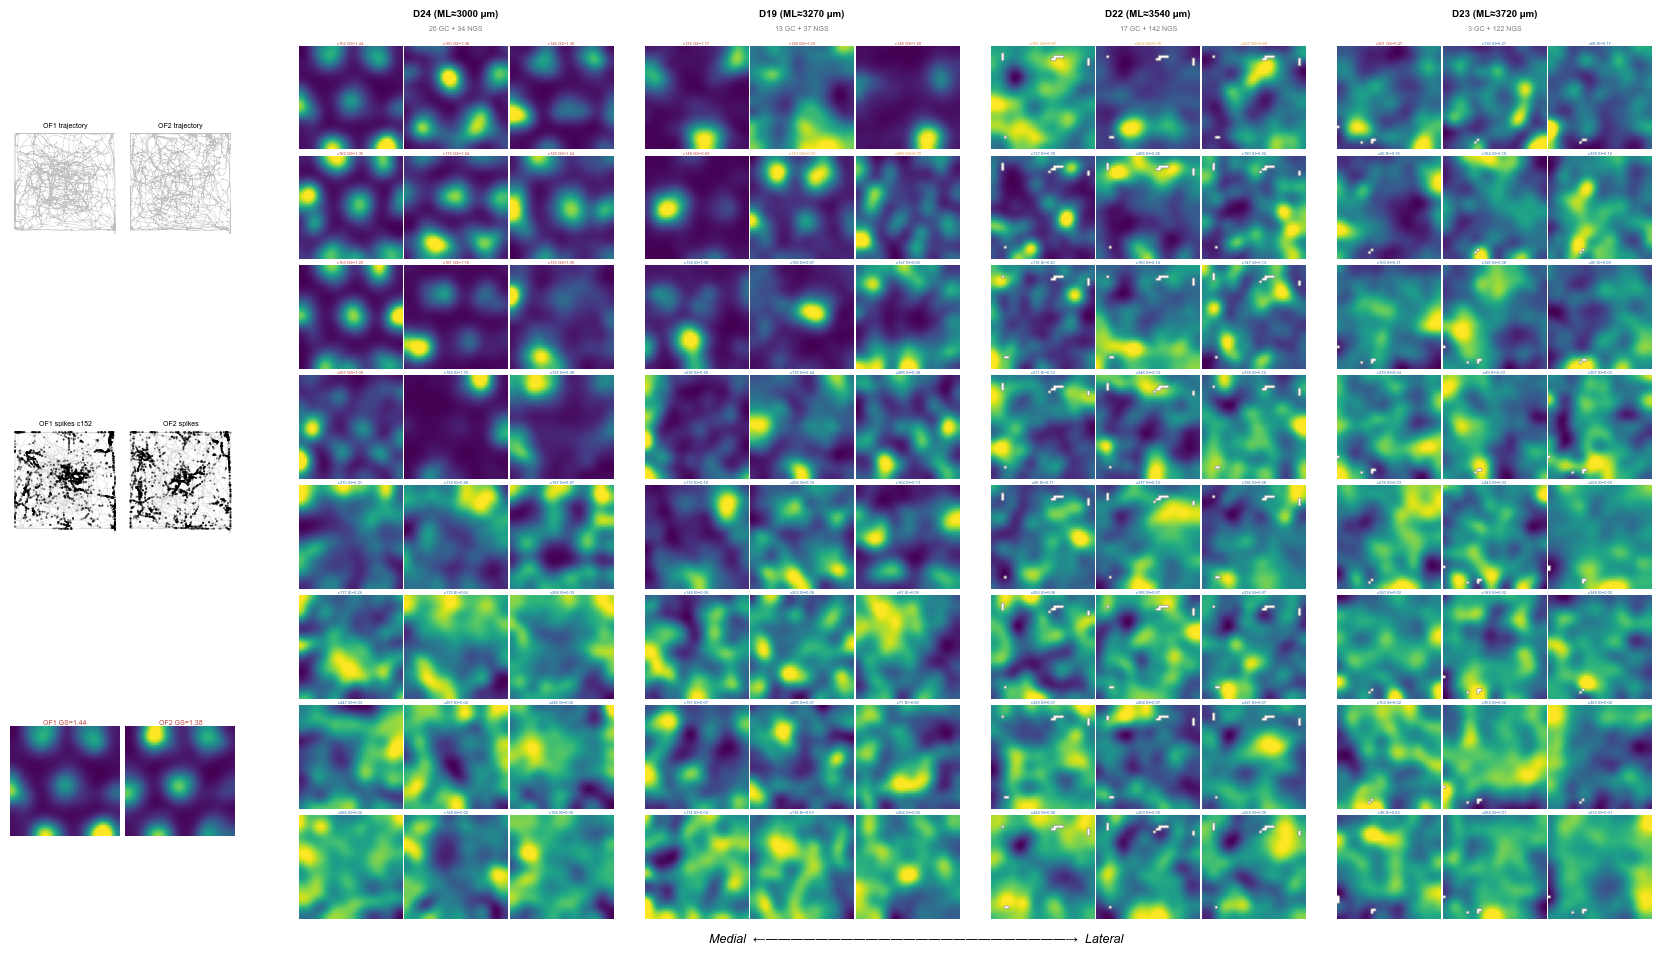

In [100]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
)

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'
SPEED_THRESHOLD = 50

def _load_beh_clusters(mouse, day, session, source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"
    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)
    return beh, clusters

def _get_speed_mask(beh, threshold=SPEED_THRESHOLD):
    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    times = beh['P_x'].times()
    dt = np.diff(times)
    dx = np.diff(px)
    dy = np.diff(py)
    speed = np.sqrt(dx**2 + dy**2) / dt
    speed_full = np.concatenate([[0], speed])
    return speed_full < threshold

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    beh, clusters = _load_beh_clusters(mouse, day, session, source_path)
    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)
    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))
    ax.imshow(tc, cmap='viridis')
    ax.axis('off')

def plot_trajectory(ax, mouse, day, session, source_path=SOURCE_PATH):
    beh, _ = _load_beh_clusters(mouse, day, session, source_path)
    px = np.array(beh['P_x']).copy()
    py = np.array(beh['P_y']).copy()
    mask = _get_speed_mask(beh)
    px[~mask] = np.nan
    py[~mask] = np.nan
    ax.plot(px, py, color='grey', lw=0.3, alpha=0.5)
    ax.set_aspect('equal')
    ax.axis('off')

def plot_spike_positions(ax, cluster_id, mouse, day, session, source_path=SOURCE_PATH, color='black'):
    beh, clusters = _load_beh_clusters(mouse, day, session, source_path)
    px = np.array(beh['P_x']).copy()
    py = np.array(beh['P_y']).copy()
    pos_times = beh['P_x'].times()
    mask = _get_speed_mask(beh)
    px_traj = px.copy()
    py_traj = py.copy()
    px_traj[~mask] = np.nan
    py_traj[~mask] = np.nan
    ax.plot(px_traj, py_traj, color='grey', lw=0.3, alpha=0.3)
    spike_times = clusters[cluster_id].times()
    spike_idx = np.searchsorted(pos_times, spike_times)
    spike_idx = spike_idx[spike_idx < len(px)]
    spike_mask = mask[spike_idx]
    spike_idx = spike_idx[spike_mask]
    ax.scatter(px[spike_idx], py[spike_idx], c=color, s=2, alpha=0.5, zorder=3, edgecolors='none')
    ax.set_aspect('equal')
    ax.axis('off')

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

mouse = 25
sessions = [24, 19, 22, 23]
N_TOTAL = 24
N_COLS_PER_SESSION = 3
N_ROWS = N_TOTAL // N_COLS_PER_SESSION

example_day = 24
example_gc = _df[(_df['mouse'] == mouse) & (_df['day'] == example_day) & (_df['cell_type'] == 'GC')]
example_gc = example_gc.sort_values('grid_score_best', ascending=False)
example_cid = int(example_gc.iloc[0]['cluster_id'])
example_cb = example_gc.iloc[0]['classified_by']
example_gs = example_gc.iloc[0]['grid_score_best']
print(f"Example cell: M{mouse}D{example_day} c{example_cid}, GS={example_gs:.2f}, {example_cb}")

np.random.seed(42)

session_cells = {}
session_counts = {}

for day in sessions:
    sub = _df[(_df['mouse'] == mouse) & (_df['day'] == day)]
    gc = sub[sub['cell_type'] == 'GC'].copy()
    gc['ml'] = gc['SC_x'].abs()
    ngs = sub[sub['cell_type'] == 'NG'].copy()
    ngs['ml'] = ngs['SC_x'].abs()
    other = sub[sub['cell_type'] == 'Other']

    session_counts[day] = {
        'GC_both': len(gc[gc['classified_by'] == 'both']),
        'GC_either': len(gc[gc['classified_by'].isin(['OF1', 'OF2'])]),
        'NGS': len(ngs),
        'Other': len(other),
        'Total': len(sub),
    }

    total = len(gc) + len(ngs)
    n_gc = round((len(gc) / total) * N_TOTAL) if total > 0 else 0
    n_gc = max(n_gc, min(1, len(gc)))
    n_ngs = N_TOTAL - n_gc

    gc = gc.sort_values('grid_score_best', ascending=False)
    if len(gc) > n_gc:
        gc = gc.head(n_gc)

    ngs_sorted_dv = ngs.sort_values('SC_y')
    if len(ngs_sorted_dv) > n_ngs:
        idx = np.linspace(0, len(ngs_sorted_dv) - 1, n_ngs).astype(int)
        ngs = ngs_sorted_dv.iloc[idx]
    else:
        ngs = ngs_sorted_dv
    ngs = ngs.sort_values('spatial_information_score_best', ascending=False)

    gc = gc.copy()
    ngs = ngs.copy()
    gc['_type'] = 'GC'
    ngs['_type'] = 'NGS'
    combined = pd.concat([gc, ngs]).reset_index(drop=True)
    session_cells[day] = combined
    print(f'D{day}: {len(gc)} GC + {len(ngs)} NGS = {len(combined)}')

n_example_cols = 2
total_right_cols = len(sessions) * N_COLS_PER_SESSION

fig = plt.figure(figsize=(n_example_cols * 1.2 + 0.3 + total_right_cols * 1.2, N_ROWS * 1.2))
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08,
                          width_ratios=[n_example_cols, total_right_cols],
                          top=0.94, bottom=0.03, left=0.02, right=0.98)

left_gs = outer[0, 0].subgridspec(3, 2, wspace=0.05, hspace=0.08)

ax_traj_of1 = fig.add_subplot(left_gs[0, 0])
ax_traj_of2 = fig.add_subplot(left_gs[0, 1])
plot_trajectory(ax_traj_of1, mouse, example_day, 'OF1')
ax_traj_of1.set_title('OF1 trajectory', fontsize=5, pad=1)
plot_trajectory(ax_traj_of2, mouse, example_day, 'OF2')
ax_traj_of2.set_title('OF2 trajectory', fontsize=5, pad=1)

ax_spk_of1 = fig.add_subplot(left_gs[1, 0])
ax_spk_of2 = fig.add_subplot(left_gs[1, 1])
plot_spike_positions(ax_spk_of1, example_cid, mouse, example_day, 'OF1', color='black')
ax_spk_of1.set_title(f'OF1 spikes c{example_cid}', fontsize=5, pad=1, color='black')
plot_spike_positions(ax_spk_of2, example_cid, mouse, example_day, 'OF2', color='black')
ax_spk_of2.set_title(f'OF2 spikes', fontsize=5, pad=1, color='black')

ax_rm_of1 = fig.add_subplot(left_gs[2, 0])
ax_rm_of2 = fig.add_subplot(left_gs[2, 1])
plot_of_rate_map(ax_rm_of1, example_cid, mouse, example_day, _df, session='OF1')
ax_rm_of1.set_title(f'OF1 GS={example_gs:.2f}', fontsize=5, pad=1, color=COL_BOTH)
plot_of_rate_map(ax_rm_of2, example_cid, mouse, example_day, _df, session='OF2')
gs_of2 = example_gc.iloc[0].get('grid_score_of2', np.nan)
ax_rm_of2.set_title(f'OF2 GS={gs_of2:.2f}', fontsize=5, pad=1, color=COL_BOTH)

right_gs = outer[0, 1].subgridspec(1, len(sessions), wspace=0.1)

for s_idx, day in enumerate(sessions):
    cells = session_cells[day]
    ml_val = cells['ml'].iloc[0] if len(cells) > 0 else 0
    counts = session_counts[day]

    inner = right_gs[0, s_idx].subgridspec(N_ROWS, N_COLS_PER_SESSION, wspace=0.02, hspace=0.06)

    mid_x = (right_gs[0, s_idx].get_position(fig).x0 + right_gs[0, s_idx].get_position(fig).x1) / 2
    fig.text(mid_x, 0.97, f'D{day} (ML≈{ml_val:.0f} µm)',
             ha='center', fontsize=7, weight='bold')
    fig.text(mid_x, 0.955, f'{counts["GC_both"]+counts["GC_either"]} GC + {counts["NGS"]} NGS',
             ha='center', fontsize=5, color='grey')

    for idx in range(min(len(cells), N_TOTAL)):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])

        ex = cells.iloc[idx]
        cid = int(ex.cluster_id)
        cell_type = ex['_type']

        if cell_type == 'GC':
            cb = ex.get('classified_by', '?')
            gs = ex.get('grid_score_best', np.nan)
            title_color = COL_BOTH if cb == 'both' else COL_EITHER
            label = f'GS={gs:.2f}'
        else:
            si = ex.get('spatial_information_score_best', np.nan)
            title_color = COL_NGS
            label = f'SI={si:.2f}'

        try:
            plot_of_rate_map(ax, cid, mouse, day, _df, session='OF1')
            ax.set_title(f'c{cid} {label}', fontsize=3, pad=1, color=title_color)
        except Exception as e:
            ax.text(0.5, 0.5, '—', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.axis('off')
            print(f"  Failed M{mouse}D{day} c{cid}: {e}")

    for idx in range(len(cells), N_ROWS * N_COLS_PER_SESSION):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])
        ax.axis('off')

fig.text(0.55, 0.005, 'Medial  ←――――――――――――――――――――――――→  Lateral',
         ha='center', fontsize=9, style='italic')

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/M25_proportional_gc_ngs_with_example.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


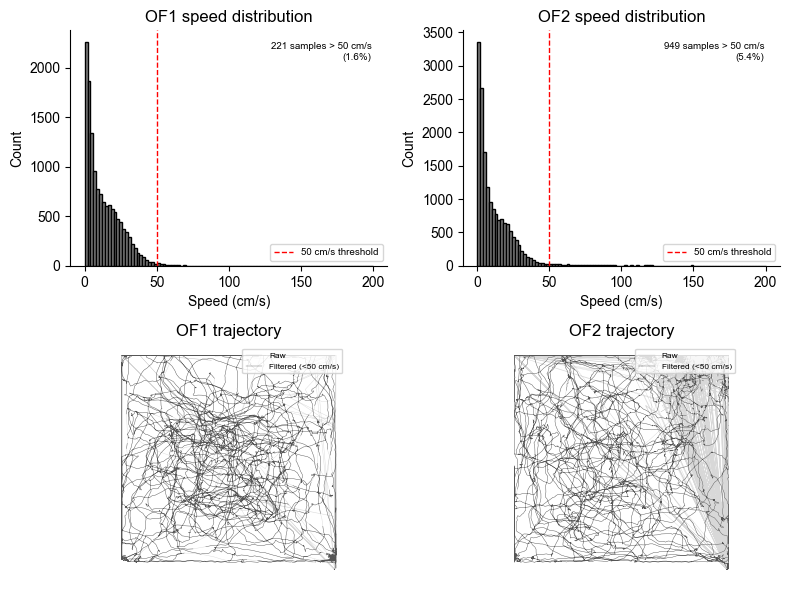

OF1: 949 bad samples (5.4%)


In [99]:
import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
mouse, day = 25, 24

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for col, session in enumerate(['OF1', 'OF2']):
    folder = f'{SOURCE_PATH}M{mouse}/D{day:02}/{session}/'
    beh = nap.load_file(folder + f'sub-{mouse}_day-{day:02}_ses-{session}_beh.nwb')

    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    times = beh['P_x'].times()

    dt = np.diff(times)
    dx = np.diff(px)
    dy = np.diff(py)
    speed = np.sqrt(dx**2 + dy**2) / dt

    # Speed distribution
    ax = axes[0, col]
    ax.hist(speed, bins=100, range=(0, 200), color='grey', edgecolor='black', lw=0.3)
    ax.axvline(50, color='red', ls='--', lw=1, label='50 cm/s threshold')
    ax.set_xlabel('Speed (cm/s)')
    ax.set_ylabel('Count')
    ax.set_title(f'{session} speed distribution')
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

    n_above = np.sum(speed > 50)
    ax.annotate(f'{n_above} samples > 50 cm/s\n({100*n_above/len(speed):.1f}%)',
                xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=7)

    # Trajectory: raw vs filtered
    ax = axes[1, col]
    ax.plot(px, py, color='grey', lw=0.3, alpha=0.3, label='Raw')

    # Filter: NaN out positions where speed > 50 cm/s
    speed_full = np.concatenate([[0], speed])
    mask = speed_full < 50
    px_filt = px.copy()
    py_filt = py.copy()
    px_filt[~mask] = np.nan
    py_filt[~mask] = np.nan
    ax.plot(px_filt, py_filt, color='black', lw=0.3, alpha=0.6, label='Filtered (<50 cm/s)')

    ax.set_aspect('equal')
    ax.set_title(f'{session} trajectory')
    ax.legend(fontsize=6, loc='upper right')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"OF1: {np.sum(speed > 50)} bad samples ({100*np.sum(speed > 50)/len(speed):.1f}%)")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
)

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"

    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)

    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)

    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))

    ax.imshow(tc, cmap='viridis')
    ax.axis('off')

def plot_trajectory(ax, mouse, day, session, source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"
    beh = nap.load_file(beh_path)
    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    ax.plot(px, py, color='grey', lw=0.3, alpha=0.5)
    ax.set_aspect('equal')
    ax.axis('off')

def plot_spike_positions(ax, cluster_id, mouse, day, session, source_path=SOURCE_PATH, color='red'):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"

    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)

    px = np.array(beh['P_x'])
    py = np.array(beh['P_y'])
    pos_times = beh['P_x'].times()

    ax.plot(px, py, color='grey', lw=0.3, alpha=0.3)

    spike_times = clusters[cluster_id].times()
    spike_idx = np.searchsorted(pos_times, spike_times)
    spike_idx = spike_idx[spike_idx < len(px)]
    ax.scatter(px[spike_idx], py[spike_idx], c=color, s=2, alpha=0.5, zorder=3, edgecolors='none')
    ax.set_aspect('equal')
    ax.axis('off')

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

mouse = 25
sessions = [24, 19, 22, 23]
N_TOTAL = 24
N_COLS_PER_SESSION = 3
N_ROWS = N_TOTAL // N_COLS_PER_SESSION

# Example cell: top GC from D24
example_day = 24
example_gc = _df[(_df['mouse'] == mouse) & (_df['day'] == example_day) & (_df['cell_type'] == 'GC')]
example_gc = example_gc.sort_values('grid_score_best', ascending=False)
example_cid = int(example_gc.iloc[0]['cluster_id'])
example_cb = example_gc.iloc[0]['classified_by']
example_gs = example_gc.iloc[0]['grid_score_best']
print(f"Example cell: M{mouse}D{example_day} c{example_cid}, GS={example_gs:.2f}, {example_cb}")

np.random.seed(42)

# ── Build session data ───────────────────────────────────────────────────────
session_cells = {}
session_counts = {}

for day in sessions:
    sub = _df[(_df['mouse'] == mouse) & (_df['day'] == day)]

    gc = sub[sub['cell_type'] == 'GC'].copy()
    gc['ml'] = gc['SC_x'].abs()

    ngs = sub[sub['cell_type'] == 'NG'].copy()
    ngs['ml'] = ngs['SC_x'].abs()

    other = sub[sub['cell_type'] == 'Other']

    session_counts[day] = {
        'GC_both': len(gc[gc['classified_by'] == 'both']),
        'GC_either': len(gc[gc['classified_by'].isin(['OF1', 'OF2'])]),
        'NGS': len(ngs),
        'Other': len(other),
        'Total': len(sub),
    }

    total = len(gc) + len(ngs)
    n_gc = round((len(gc) / total) * N_TOTAL) if total > 0 else 0
    n_gc = max(n_gc, min(1, len(gc)))
    n_ngs = N_TOTAL - n_gc

    gc = gc.sort_values('grid_score_best', ascending=False)
    if len(gc) > n_gc:
        gc = gc.head(n_gc)

    ngs_sorted_dv = ngs.sort_values('SC_y')
    if len(ngs_sorted_dv) > n_ngs:
        idx = np.linspace(0, len(ngs_sorted_dv) - 1, n_ngs).astype(int)
        ngs = ngs_sorted_dv.iloc[idx]
    else:
        ngs = ngs_sorted_dv
    ngs = ngs.sort_values('spatial_information_score_best', ascending=False)

    gc = gc.copy()
    ngs = ngs.copy()
    gc['_type'] = 'GC'
    ngs['_type'] = 'NGS'
    combined = pd.concat([gc, ngs]).reset_index(drop=True)
    session_cells[day] = combined

    print(f'D{day}: {len(gc)} GC + {len(ngs)} NGS = {len(combined)}')

# ── Layout ────────────────────────────────────────────────────────────────────
n_example_cols = 2
total_right_cols = len(sessions) * N_COLS_PER_SESSION

fig = plt.figure(figsize=(n_example_cols * 1.2 + 0.3 + total_right_cols * 1.2, N_ROWS * 1.2))
outer = gridspec.GridSpec(1, 2, figure=fig, wspace=0.08,
                          width_ratios=[n_example_cols, total_right_cols],
                          top=0.94, bottom=0.03, left=0.02, right=0.98)

# ── Left: Example cell (trajectory, spikes, rate maps) ──────────────────────
left_gs = outer[0, 0].subgridspec(3, 2, wspace=0.05, hspace=0.08)

# Row 0: Trajectory OF1 and OF2
ax_traj_of1 = fig.add_subplot(left_gs[0, 0])
ax_traj_of2 = fig.add_subplot(left_gs[0, 1])

plot_trajectory(ax_traj_of1, mouse, example_day, 'OF1')
ax_traj_of1.set_title('OF1 trajectory', fontsize=5, pad=1)

plot_trajectory(ax_traj_of2, mouse, example_day, 'OF2')
ax_traj_of2.set_title('OF2 trajectory', fontsize=5, pad=1)

# Row 1: Spike positions OF1 and OF2
ax_spk_of1 = fig.add_subplot(left_gs[1, 0])
ax_spk_of2 = fig.add_subplot(left_gs[1, 1])

plot_spike_positions(ax_spk_of1, example_cid, mouse, example_day, 'OF1', color=COL_BOTH)
ax_spk_of1.set_title(f'OF1 spikes c{example_cid}', fontsize=5, pad=1, color=COL_BOTH)

plot_spike_positions(ax_spk_of2, example_cid, mouse, example_day, 'OF2', color=COL_BOTH)
ax_spk_of2.set_title(f'OF2 spikes', fontsize=5, pad=1, color=COL_BOTH)

# Row 2: Rate maps OF1 and OF2
ax_rm_of1 = fig.add_subplot(left_gs[2, 0])
ax_rm_of2 = fig.add_subplot(left_gs[2, 1])

plot_of_rate_map(ax_rm_of1, example_cid, mouse, example_day, _df, session='OF1')
ax_rm_of1.set_title(f'OF1 GS={example_gs:.2f}', fontsize=5, pad=1, color=COL_BOTH)

plot_of_rate_map(ax_rm_of2, example_cid, mouse, example_day, _df, session='OF2')
gs_of2 = example_gc.iloc[0].get('grid_score_of2', np.nan)
ax_rm_of2.set_title(f'OF2 GS={gs_of2:.2f}', fontsize=5, pad=1, color=COL_BOTH)

# ── Right: rate map columns ──────────────────────────────────────────────────
right_gs = outer[0, 1].subgridspec(1, len(sessions), wspace=0.1)

for s_idx, day in enumerate(sessions):
    cells = session_cells[day]
    ml_val = cells['ml'].iloc[0] if len(cells) > 0 else 0
    counts = session_counts[day]

    inner = right_gs[0, s_idx].subgridspec(N_ROWS, N_COLS_PER_SESSION, wspace=0.02, hspace=0.06)

    mid_x = (right_gs[0, s_idx].get_position(fig).x0 + right_gs[0, s_idx].get_position(fig).x1) / 2
    fig.text(mid_x, 0.97, f'D{day} (ML≈{ml_val:.0f} µm)',
             ha='center', fontsize=7, weight='bold')
    fig.text(mid_x, 0.955, f'{counts["GC_both"]+counts["GC_either"]} GC + {counts["NGS"]} NGS',
             ha='center', fontsize=5, color='grey')

    for idx in range(min(len(cells), N_TOTAL)):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])

        ex = cells.iloc[idx]
        cid = int(ex.cluster_id)
        cell_type = ex['_type']

        if cell_type == 'GC':
            cb = ex.get('classified_by', '?')
            gs = ex.get('grid_score_best', np.nan)
            title_color = COL_BOTH if cb == 'both' else COL_EITHER
            label = f'GS={gs:.2f}'
        else:
            si = ex.get('spatial_information_score_best', np.nan)
            title_color = COL_NGS
            label = f'SI={si:.2f}'

        try:
            plot_of_rate_map(ax, cid, mouse, day, _df, session='OF1')
            ax.set_title(f'c{cid} {label}', fontsize=3, pad=1, color=title_color)
        except Exception as e:
            ax.text(0.5, 0.5, '—', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.axis('off')
            print(f"  Failed M{mouse}D{day} c{cid}: {e}")

    for idx in range(len(cells), N_ROWS * N_COLS_PER_SESSION):
        r = idx // N_COLS_PER_SESSION
        c = idx % N_COLS_PER_SESSION
        ax = fig.add_subplot(inner[r, c])
        ax.axis('off')

fig.text(0.55, 0.005, 'Medial  ←――――――――――――――――――――――――→  Lateral',
         ha='center', fontsize=9, style='italic')

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/M25_proportional_gc_ngs_with_example.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


In [64]:
import numpy as np
import pandas as pd
from pathlib import Path

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'
CACHE_PATH = Path('/Users/harryclark/Documents/spatial-manifolds/data/spatial_stability_cache.csv')

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

mouse_days = _cc.groupby(['mouse', 'day']).size().reset_index()[['mouse', 'day']]

if CACHE_PATH.exists():
    print(f"Loading cached stability from {CACHE_PATH}")
    stab_df = pd.read_csv(CACHE_PATH)
else:
    print("Loading spatial stability from parquet files...")
    all_stab = []

    for _, row in mouse_days.iterrows():
        mouse, day = int(row['mouse']), int(row['day'])
        parquet_path = f'{SOURCE_PATH}M{mouse}/D{day:02}/OF1/tuning_scores/spatial_stability.parquet'

        try:
            stab = pd.read_parquet(parquet_path)
            zero_lag = stab[stab['travel'] == 0][['cluster_id', 'stability', 'sig']].copy()
            zero_lag['mouse'] = mouse
            zero_lag['day'] = day
            all_stab.append(zero_lag)
            print(f"  M{mouse}D{day}: {len(zero_lag)} cells")
        except FileNotFoundError:
            print(f"  M{mouse}D{day}: parquet not found, skipping")

    stab_df = pd.concat(all_stab, ignore_index=True)
    stab_df.to_csv(CACHE_PATH, index=False)
    print(f"Saved {len(stab_df)} cells to {CACHE_PATH}")

print(f"Stability: {stab_df['stability'].notna().sum()} cells, "
      f"mean={stab_df['stability'].mean():.3f}, median={stab_df['stability'].median():.3f}")


Loading spatial stability from parquet files...
  M20D14: 204 cells
  M20D15: 75 cells
  M20D16: 219 cells
  M20D17: 132 cells
  M20D18: 151 cells
  M20D19: 118 cells
  M20D20: 103 cells
  M20D21: 117 cells
  M20D22: 81 cells
  M20D23: 85 cells
  M20D24: 81 cells
  M20D25: 37 cells
  M20D26: 154 cells
  M21D15: 268 cells
  M21D16: 242 cells
  M21D17: 312 cells
  M21D18: 219 cells
  M21D19: parquet not found, skipping
  M21D20: 331 cells
  M21D21: 340 cells
  M21D22: 164 cells
  M21D23: 350 cells
  M21D24: 229 cells
  M21D25: 184 cells
  M21D26: 209 cells
  M25D16: 72 cells
  M25D17: 68 cells
  M25D18: 146 cells
  M25D19: 61 cells
  M25D20: 68 cells
  M25D21: 65 cells
  M25D22: 189 cells
  M25D23: 229 cells
  M25D24: 69 cells
  M25D25: 152 cells
  M26D11: 165 cells
  M26D12: 156 cells
  M26D13: 118 cells
  M26D15: 141 cells
  M26D18: 103 cells
  M26D19: 346 cells
  M27D18: 89 cells
  M27D19: 103 cells
  M27D23: 167 cells
  M27D24: 231 cells
  M28D16: 101 cells
  M28D17: 101 cells
  M28D

7365 ENTm cells, 7 mice
SI: 7365, FR: 7365, Stability: 7170
SI model: quad
FR model: quad
Stability model: quad (n=7170)


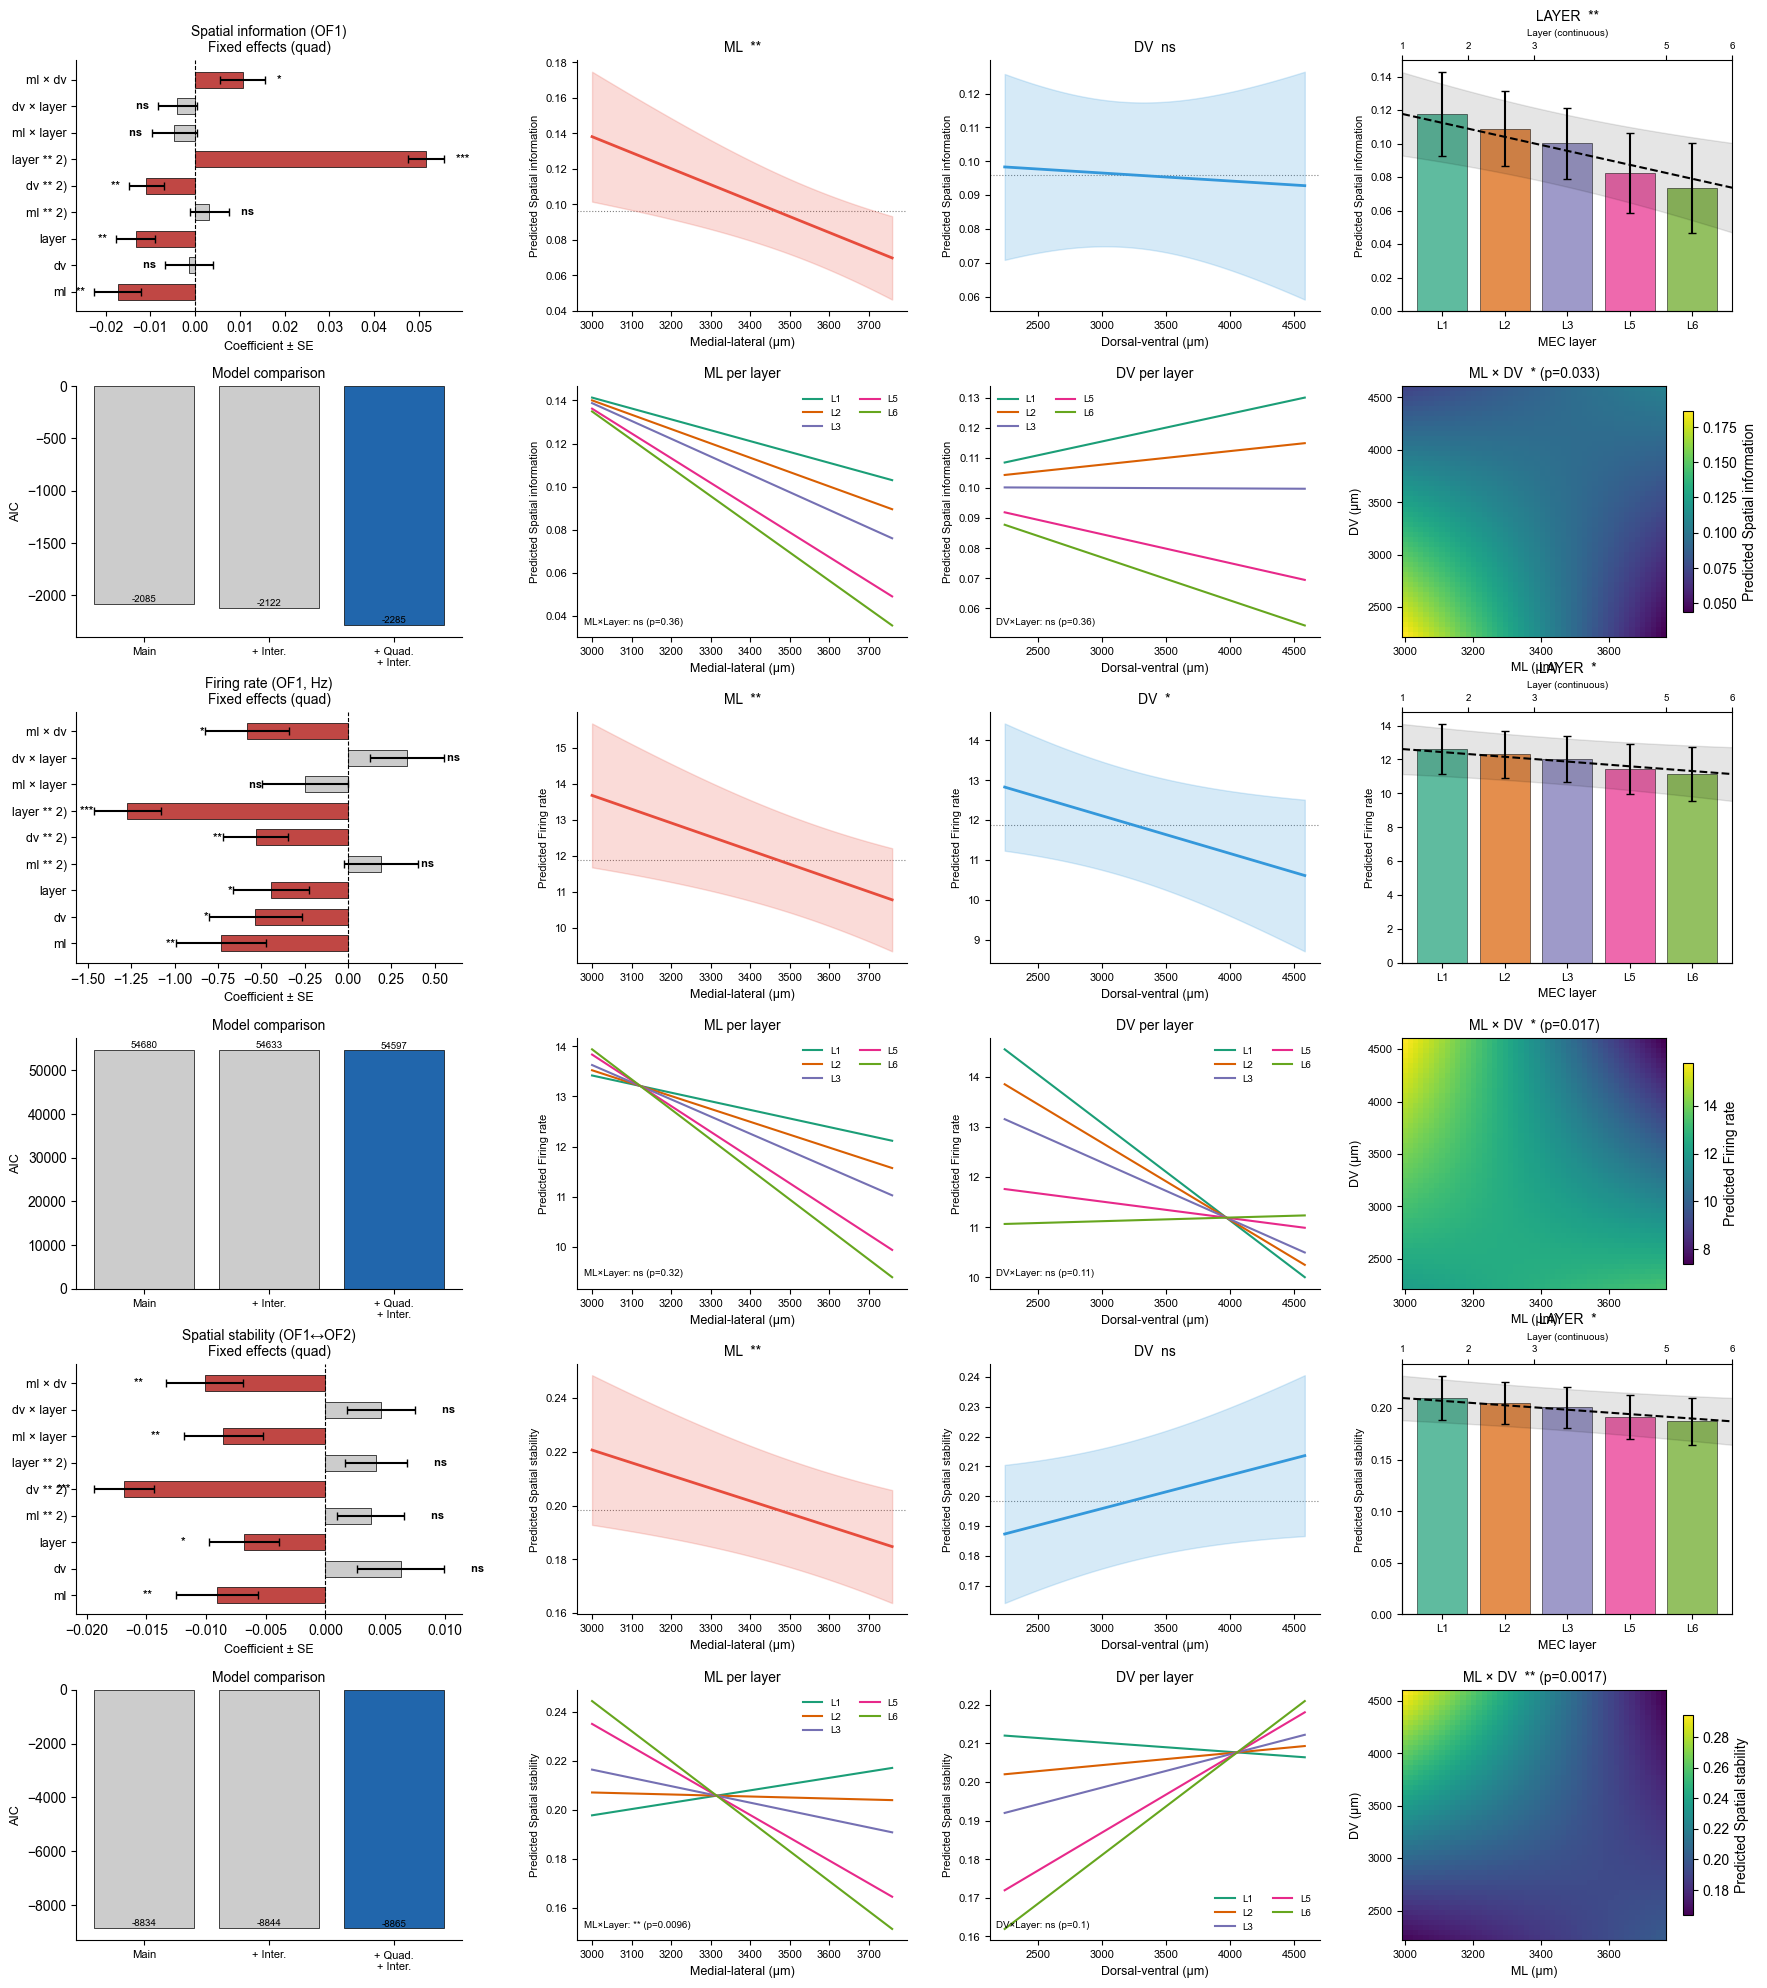

In [97]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

# ── Load and prepare data ────────────────────────────────────────────────────
_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

stab_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_stability_cache.csv')
_cc = _cc.merge(stab_df[['mouse', 'day', 'cluster_id', 'stability']],
                on=['mouse', 'day', 'cluster_id'], how='left')

df = _cc.copy()
df['ml'] = df['SC_x'].abs()
df['dv'] = df['SC_y']
df['si'] = df['spatial_information_score_of1']
df['fr'] = df['firing_rate_OF1']
df['stab'] = df['stability']
df['_mouse'] = df['mouse'].astype(int)
df['_session'] = df['_mouse'].astype(str) + '_' + df['day'].astype(int).astype(str)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

df['layer_num'] = df['brain_region'].apply(get_layer_num)
df = df[df['layer_num'].notna()].copy()
df['layer_label'] = 'L' + df['layer_num'].astype(int).astype(str)

df['ml_z'] = (df['ml'] - df['ml'].mean()) / df['ml'].std()
df['dv_z'] = (df['dv'] - df['dv'].mean()) / df['dv'].std()
df['layer_z'] = (df['layer_num'] - df['layer_num'].mean()) / df['layer_num'].std()

print(f"{len(df)} ENTm cells, {df['_mouse'].nunique()} mice")
print(f"SI: {df['si'].notna().sum()}, FR: {df['fr'].notna().sum()}, Stability: {df['stab'].notna().sum()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def z_to_real(z_vals, z_col):
    real_col = z_col.replace('_z', '')
    if real_col == 'layer':
        return z_vals * df['layer_num'].std() + df['layer_num'].mean()
    return z_vals * df[real_col].std() + df[real_col].mean()

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def layer_num_to_z(ln):
    return (ln - df['layer_num'].mean()) / df['layer_num'].std()

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)
    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)
    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)
    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
layer_weights = np.array([len(df[df['layer_num'] == ln]) for ln in layer_nums], dtype=float)
layer_weights /= layer_weights.sum()
n_pts = 200

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', '#e74c3c'),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', '#3498db'),
    ('layer_z', 'layer', 'MEC layer', '#2ca02c'),
]

# ── Fit models ───────────────────────────────────────────────────────────────
df_si = df[df['si'].notna()].copy()
best_si, best_si_name, aic_si = fit_and_select('si', df_si)
print(f"SI model: {best_si_name}")

df_fr = df[df['fr'].notna()].copy()
best_fr, best_fr_name, aic_fr = fit_and_select('fr', df_fr)
print(f"FR model: {best_fr_name}")

df_stab = df[df['stab'].notna()].copy()
best_stab, best_stab_name, aic_stab = fit_and_select('stab', df_stab)
print(f"Stability model: {best_stab_name} (n={len(df_stab)})")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE: 6 rows × 2 columns
# ══════════════════════════════════════════════════════════════════════════════

measures = [
    ('Spatial information (OF1)', 'si', df_si, best_si, best_si_name, aic_si),
    ('Firing rate (OF1, Hz)', 'fr', df_fr, best_fr, best_fr_name, aic_fr),
    ('Spatial stability (OF1↔OF2)', 'stab', df_stab, best_stab, best_stab_name, aic_stab),
]

fig = plt.figure(figsize=(18, 20))
outer = gridspec.GridSpec(6, 2, figure=fig, width_ratios=[1, 3], wspace=0.15, hspace=0.3,
                          top=0.97, bottom=0.03, left=0.05, right=0.97)

for m_idx, (measure_label, dv_col, df_m, best_m, best_m_name, aic_m) in enumerate(measures):
    row_coef = m_idx * 2
    row_inter = m_idx * 2 + 1
    short_label = measure_label.split('(')[0].strip()

    # ── Left: Coefficients ───────────────────────────────────────────────────
    ax_coef = fig.add_subplot(outer[row_coef, 0])

    fe = best_m.fe_params.drop('Intercept')
    se_coef = best_m.bse.reindex(fe.index)
    pvals_fe = best_m.pvalues.reindex(fe.index)
    display_names = [n.replace('_z', '').replace('I(', '').replace('**2)', '²').replace(':', ' × ')
                     for n in fe.index]
    colors_coef = ['#c04744' if p < 0.05 else '#cccccc' for p in pvals_fe]
    y_pos = np.arange(len(fe))

    ax_coef.barh(y_pos, fe.values, xerr=se_coef.values, color=colors_coef,
                 edgecolor='black', lw=0.5, capsize=3, height=0.6)
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels(display_names, fontsize=9)
    ax_coef.axvline(0, color='black', lw=0.8, ls='--')
    ax_coef.set_xlabel('Coefficient ± SE', fontsize=9)
    ax_coef.set_title(f'{measure_label}\nFixed effects ({best_m_name})', fontsize=10)
    ax_coef.spines[['top', 'right']].set_visible(False)

    for i, (coef, p) in enumerate(zip(fe.values, pvals_fe)):
        stars = pval_to_stars(p)
        x_off = se_coef.values[i] + 0.002 if coef >= 0 else -se_coef.values[i] - 0.002
        ax_coef.text(coef + x_off, i, f' {stars}', ha='left' if coef >= 0 else 'right',
                     va='center', fontsize=8, fontweight='bold')

    # ── Left: AIC ────────────────────────────────────────────────────────────
    ax_aic = fig.add_subplot(outer[row_inter, 0])
    names_disp = ['Main', '+ Inter.', '+ Quad.\n+ Inter.']
    aic_list = [aic_m['main'], aic_m['inter'], aic_m['quad']]
    aic_col = ['#2166ac' if n == best_m_name else '#cccccc' for n in ['main', 'inter', 'quad']]
    ax_aic.bar(range(3), aic_list, color=aic_col, edgecolor='black', lw=0.5)
    ax_aic.set_xticks(range(3))
    ax_aic.set_xticklabels(names_disp, fontsize=8)
    ax_aic.set_ylabel('AIC', fontsize=9)
    ax_aic.set_title('Model comparison', fontsize=10)
    ax_aic.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(aic_list):
        ax_aic.text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

    # ── Right: Partial effects ───────────────────────────────────────────────
    right_partial = outer[row_coef, 1].subgridspec(1, 3, wspace=0.25)

    for col_idx, (z_col, real_col, xlabel, color) in enumerate(all_axes_info):
        ax = fig.add_subplot(right_partial[0, col_idx])
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        if z_col == 'layer_z':
            params_list = list(best_m.fe_params.keys())
            cov_mat = best_m.cov_params().loc[params_list, params_list].values
            lz_vals = np.array([layer_num_to_z(ln) for ln in layer_nums])
            pred_vals, se_vals = [], []
            for lz in lz_vals:
                d = {c: 0 for c in hold_others}; d[z_col] = lz
                pred_vals.append(predict_simple(best_m, d))
                x_row = get_design_row(best_m, d)
                se_vals.append(np.sqrt(x_row @ cov_mat @ x_row))
            pred_vals = np.array(pred_vals)
            se_vals = np.array(se_vals)

            ax.bar(np.arange(len(layer_nums)), pred_vals, yerr=1.96*se_vals, capsize=3,
                   color=[layer_colors[f'L{ln}'] for ln in layer_nums], edgecolor='black',
                   lw=0.5, alpha=0.7, zorder=3)

            z_cont = np.linspace(df_m['layer_z'].min(), df_m['layer_z'].max(), n_pts)
            real_cont = z_to_real(z_cont, 'layer_z')
            pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)
            ax2 = ax.twiny()
            ax2.plot(real_cont, pred_cont, color='black', lw=1.5, ls='--', zorder=5)
            ax2.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                             color='black', alpha=0.1, zorder=4)
            ax2.set_xlim(real_cont[0], real_cont[-1])
            ax2.set_xticks([1, 2, 3, 5, 6])
            ax2.tick_params(labelsize=7)
            ax2.set_xlabel('Layer (continuous)', fontsize=7)

            ax.set_xticks(np.arange(len(layer_nums)))
            ax.set_xticklabels(layer_labels, fontsize=9)
        else:
            z_vals = np.linspace(df_m[z_col].min(), df_m[z_col].max(), n_pts)
            real_vals = z_to_real(z_vals, z_col)
            pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)
            ax.plot(real_vals, pred, color=color, lw=2, zorder=4)
            ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                            color=color, alpha=0.2, zorder=3)
            ax.axhline(best_m.fe_params['Intercept'], color='grey', ls=':', lw=0.8)

        p_main = best_m.pvalues.get(z_col, np.nan)
        ax.set_title(f'{real_col.upper()}  {pval_to_stars(p_main)}', fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(f'Predicted {short_label}', fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    # ── Right: Per-layer interactions ────────────────────────────────────────
    right_inter = outer[row_inter, 1].subgridspec(1, 3, wspace=0.25)

    ax_ml_l = fig.add_subplot(right_inter[0, 0])
    z_ml = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_pts)
    r_ml = z_to_real(z_ml, 'ml_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': z, 'dv_z': 0, 'layer_z': lz}) for z in z_ml]
        ax_ml_l.plot(r_ml, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_ml_l.set_xlabel('Medial-lateral (µm)', fontsize=9)
    ax_ml_l.set_ylabel(f'Predicted {short_label}', fontsize=8)
    ax_ml_l.set_title('ML per layer', fontsize=10)
    ax_ml_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_ml_l.spines[['top', 'right']].set_visible(False)
    ax_ml_l.tick_params(labelsize=8)
    if 'ml_z:layer_z' in best_m.pvalues:
        p_mli = best_m.pvalues['ml_z:layer_z']
        ax_ml_l.annotate(f'ML×Layer: {pval_to_stars(p_mli)} (p={p_mli:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_dv_l = fig.add_subplot(right_inter[0, 1])
    z_dv = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_pts)
    r_dv = z_to_real(z_dv, 'dv_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': 0, 'dv_z': z, 'layer_z': lz}) for z in z_dv]
        ax_dv_l.plot(r_dv, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_dv_l.set_xlabel('Dorsal-ventral (µm)', fontsize=9)
    ax_dv_l.set_ylabel(f'Predicted {short_label}', fontsize=8)
    ax_dv_l.set_title('DV per layer', fontsize=10)
    ax_dv_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_dv_l.spines[['top', 'right']].set_visible(False)
    ax_dv_l.tick_params(labelsize=8)
    if 'dv_z:layer_z' in best_m.pvalues:
        p_dvl = best_m.pvalues['dv_z:layer_z']
        ax_dv_l.annotate(f'DV×Layer: {pval_to_stars(p_dvl)} (p={p_dvl:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_hm = fig.add_subplot(right_inter[0, 2])
    n_grid = 50
    ml_zr = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_grid)
    dv_zr = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_grid)
    MZ, DZ = np.meshgrid(ml_zr, dv_zr)
    pg = np.zeros_like(MZ)
    for ln, w in zip(layer_nums, layer_weights):
        lz = layer_num_to_z(ln)
        for i in range(n_grid):
            for j in range(n_grid):
                pg[i, j] += w * predict_simple(best_m, {'ml_z': MZ[i,j], 'dv_z': DZ[i,j], 'layer_z': lz})
    ml_r = z_to_real(ml_zr, 'ml_z')
    dv_r = z_to_real(dv_zr, 'dv_z')
    im = ax_hm.pcolormesh(ml_r, dv_r, pg, cmap='viridis', shading='auto', rasterized=True)
    plt.colorbar(im, ax=ax_hm, shrink=0.8, label=f'Predicted {short_label}')
    if 'ml_z:dv_z' in best_m.pvalues:
        p_mlvd = best_m.pvalues['ml_z:dv_z']
        ax_hm.set_title(f'ML × DV  {pval_to_stars(p_mlvd)} (p={p_mlvd:.2g})', fontsize=10)
    else:
        ax_hm.set_title('ML × DV', fontsize=10)
    ax_hm.set_xlabel('ML (µm)', fontsize=9)
    ax_hm.set_ylabel('DV (µm)', fontsize=9)
    ax_hm.tick_params(labelsize=8)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/si_fr_stability_layer_glmm.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


7365 ENTm cells, 7 mice
SI: 7365, FR: 7365, Stability: 7170
SI model: quad
FR model: quad
Stability model: quad (n=7170)


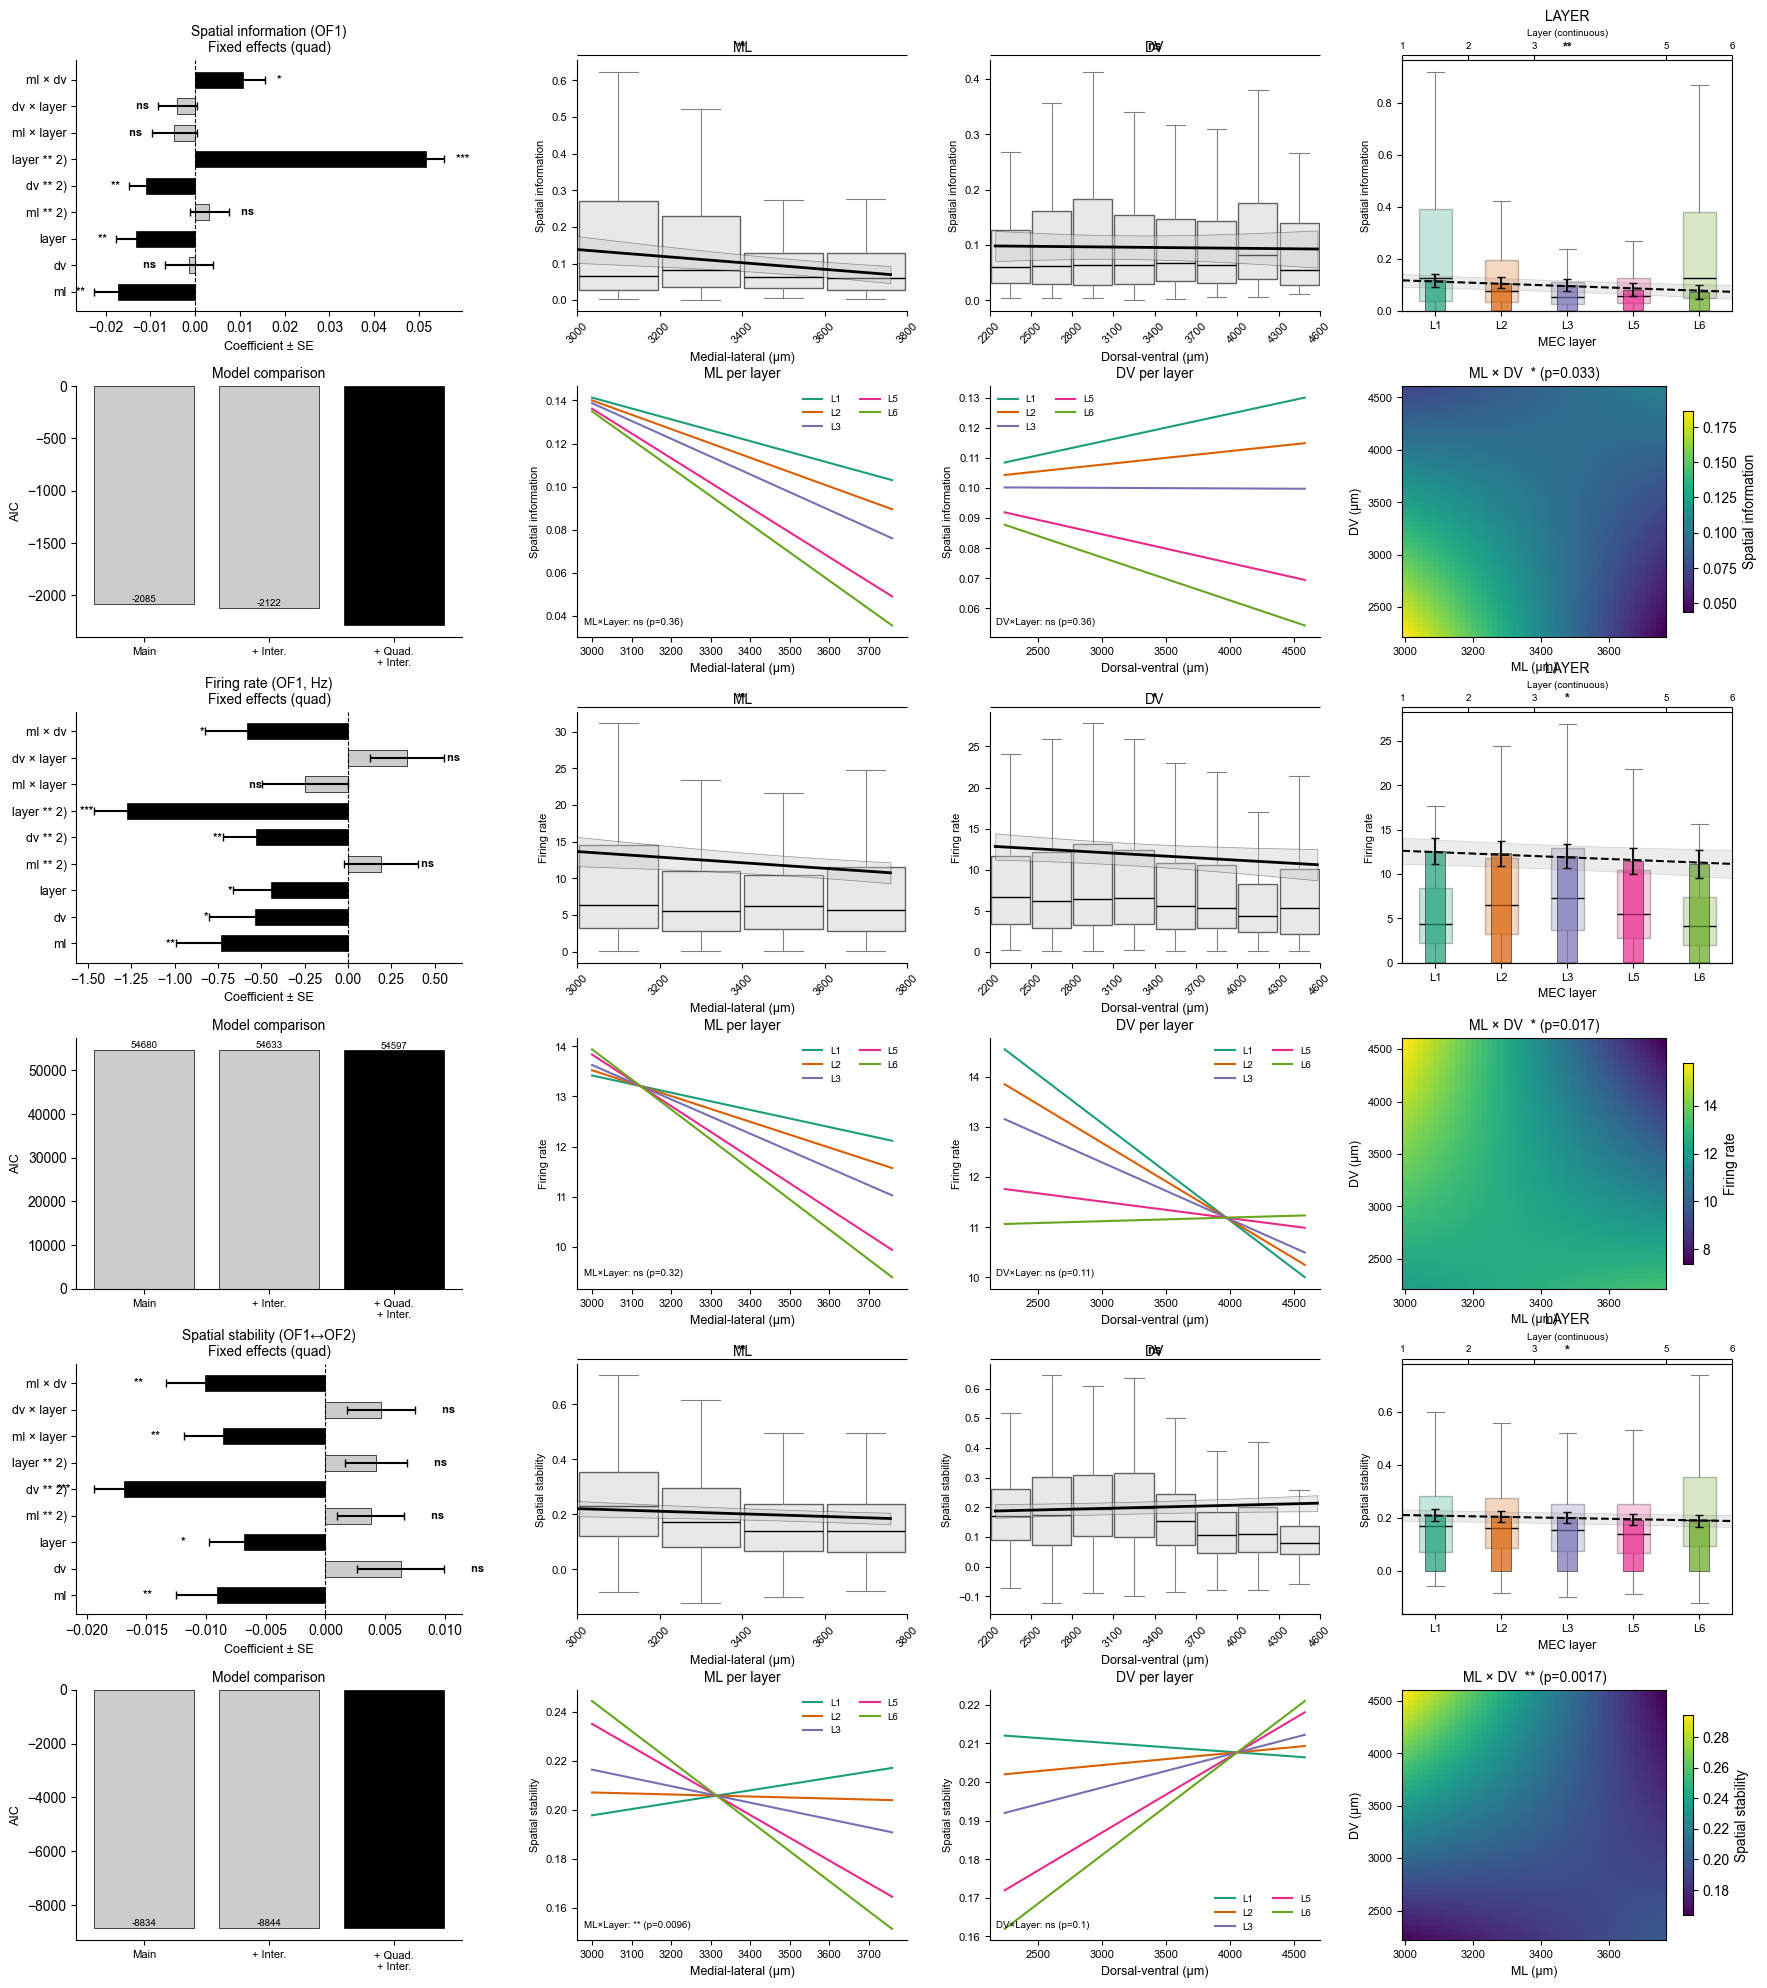

In [69]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

# ── Load and prepare data ────────────────────────────────────────────────────
_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

stab_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_stability_cache.csv')
_cc = _cc.merge(stab_df[['mouse', 'day', 'cluster_id', 'stability']],
                on=['mouse', 'day', 'cluster_id'], how='left')

df = _cc.copy()
df['ml'] = df['SC_x'].abs()
df['dv'] = df['SC_y']
df['si'] = df['spatial_information_score_of1']
df['fr'] = df['firing_rate_OF1']
df['stab'] = df['stability']
df['_mouse'] = df['mouse'].astype(int)
df['_session'] = df['_mouse'].astype(str) + '_' + df['day'].astype(int).astype(str)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

df['layer_num'] = df['brain_region'].apply(get_layer_num)
df = df[df['layer_num'].notna()].copy()
df['layer_label'] = 'L' + df['layer_num'].astype(int).astype(str)

df['ml_z'] = (df['ml'] - df['ml'].mean()) / df['ml'].std()
df['dv_z'] = (df['dv'] - df['dv'].mean()) / df['dv'].std()
df['layer_z'] = (df['layer_num'] - df['layer_num'].mean()) / df['layer_num'].std()

print(f"{len(df)} ENTm cells, {df['_mouse'].nunique()} mice")
print(f"SI: {df['si'].notna().sum()}, FR: {df['fr'].notna().sum()}, Stability: {df['stab'].notna().sum()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def z_to_real(z_vals, z_col):
    real_col = z_col.replace('_z', '')
    if real_col == 'layer':
        return z_vals * df['layer_num'].std() + df['layer_num'].mean()
    return z_vals * df[real_col].std() + df[real_col].mean()

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def layer_num_to_z(ln):
    return (ln - df['layer_num'].mean()) / df['layer_num'].std()

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)
    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)
    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)
    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

def add_sig_line(ax, p):
    stars = pval_to_stars(p)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    y_line = ylim[1] + (ylim[1] - ylim[0]) * 0.02
    ax.hlines(y_line, xlim[0], xlim[1], color='black', lw=0.8, clip_on=False)
    ax.text(np.mean(xlim), y_line + (ylim[1] - ylim[0]) * 0.01, stars,
            ha='center', va='bottom', fontsize=9, fontweight='bold', clip_on=False)
    ax.set_ylim(ylim)

ML_BOX_BINS = np.arange(3000, 3801, 200)
DV_BOX_BINS = np.arange(2200, 4601, 300)

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
layer_weights = np.array([len(df[df['layer_num'] == ln]) for ln in layer_nums], dtype=float)
layer_weights /= layer_weights.sum()
n_pts = 200

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', ML_BOX_BINS),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', DV_BOX_BINS),
    ('layer_z', 'layer', 'MEC layer', None),
]

# ── Fit models ───────────────────────────────────────────────────────────────
df_si = df[df['si'].notna()].copy()
best_si, best_si_name, aic_si = fit_and_select('si', df_si)
print(f"SI model: {best_si_name}")

df_fr = df[df['fr'].notna()].copy()
best_fr, best_fr_name, aic_fr = fit_and_select('fr', df_fr)
print(f"FR model: {best_fr_name}")

df_stab = df[df['stab'].notna()].copy()
best_stab, best_stab_name, aic_stab = fit_and_select('stab', df_stab)
print(f"Stability model: {best_stab_name} (n={len(df_stab)})")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════

measures = [
    ('Spatial information (OF1)', 'si', df_si, best_si, best_si_name, aic_si),
    ('Firing rate (OF1, Hz)', 'fr', df_fr, best_fr, best_fr_name, aic_fr),
    ('Spatial stability (OF1↔OF2)', 'stab', df_stab, best_stab, best_stab_name, aic_stab),
]

fig = plt.figure(figsize=(18, 20))
outer = gridspec.GridSpec(6, 2, figure=fig, width_ratios=[1, 3], wspace=0.15, hspace=0.3,
                          top=0.97, bottom=0.03, left=0.05, right=0.97)

for m_idx, (measure_label, dv_col, df_m, best_m, best_m_name, aic_m) in enumerate(measures):
    row_coef = m_idx * 2
    row_inter = m_idx * 2 + 1
    short_label = measure_label.split('(')[0].strip()

    # ── Left: Coefficients ───────────────────────────────────────────────────
    ax_coef = fig.add_subplot(outer[row_coef, 0])

    fe = best_m.fe_params.drop('Intercept')
    se_coef = best_m.bse.reindex(fe.index)
    pvals_fe = best_m.pvalues.reindex(fe.index)
    display_names = [n.replace('_z', '').replace('I(', '').replace('**2)', '²').replace(':', ' × ')
                     for n in fe.index]
    colors_coef = ['black' if p < 0.05 else '#cccccc' for p in pvals_fe]
    y_pos = np.arange(len(fe))

    ax_coef.barh(y_pos, fe.values, xerr=se_coef.values, color=colors_coef,
                 edgecolor='black', lw=0.5, capsize=3, height=0.6)
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels(display_names, fontsize=9)
    ax_coef.axvline(0, color='black', lw=0.8, ls='--')
    ax_coef.set_xlabel('Coefficient ± SE', fontsize=9)
    ax_coef.set_title(f'{measure_label}\nFixed effects ({best_m_name})', fontsize=10)
    ax_coef.spines[['top', 'right']].set_visible(False)

    for i, (coef, p) in enumerate(zip(fe.values, pvals_fe)):
        stars = pval_to_stars(p)
        x_off = se_coef.values[i] + 0.002 if coef >= 0 else -se_coef.values[i] - 0.002
        ax_coef.text(coef + x_off, i, f' {stars}', ha='left' if coef >= 0 else 'right',
                     va='center', fontsize=8, fontweight='bold')

    # ── Left: AIC ────────────────────────────────────────────────────────────
    ax_aic = fig.add_subplot(outer[row_inter, 0])
    names_disp = ['Main', '+ Inter.', '+ Quad.\n+ Inter.']
    aic_list = [aic_m['main'], aic_m['inter'], aic_m['quad']]
    aic_col = ['black' if n == best_m_name else '#cccccc' for n in ['main', 'inter', 'quad']]
    ax_aic.bar(range(3), aic_list, color=aic_col, edgecolor='black', lw=0.5)
    ax_aic.set_xticks(range(3))
    ax_aic.set_xticklabels(names_disp, fontsize=8)
    ax_aic.set_ylabel('AIC', fontsize=9)
    ax_aic.set_title('Model comparison', fontsize=10)
    ax_aic.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(aic_list):
        ax_aic.text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=7)

    # ── Right: Partial effects with boxplots ─────────────────────────────────
    right_partial = outer[row_coef, 1].subgridspec(1, 3, wspace=0.25)

    for col_idx, (z_col, real_col, xlabel, box_bins) in enumerate(all_axes_info):
        ax = fig.add_subplot(right_partial[0, col_idx])
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        p_main = best_m.pvalues.get(z_col, np.nan)

        if z_col == 'layer_z':
            params_list = list(best_m.fe_params.keys())
            cov_mat = best_m.cov_params().loc[params_list, params_list].values
            lz_vals = np.array([layer_num_to_z(ln) for ln in layer_nums])
            pred_vals, se_vals = [], []
            for lz in lz_vals:
                d = {c: 0 for c in hold_others}; d[z_col] = lz
                pred_vals.append(predict_simple(best_m, d))
                x_row = get_design_row(best_m, d)
                se_vals.append(np.sqrt(x_row @ cov_mat @ x_row))
            pred_vals = np.array(pred_vals)
            se_vals = np.array(se_vals)

            bp_data = [df_m[df_m['layer_num'] == ln][dv_col].dropna().values for ln in layer_nums]
            bp = ax.boxplot(bp_data, positions=np.arange(len(layer_nums)), widths=0.5,
                            patch_artist=True, showfliers=False, zorder=1,
                            medianprops=dict(color='black', lw=1),
                            whiskerprops=dict(color='grey', lw=0.8),
                            capprops=dict(color='grey', lw=0.8))
            for patch, ln in zip(bp['boxes'], layer_nums):
                patch.set_facecolor(layer_colors[f'L{ln}'])
                patch.set_alpha(0.25)

            ax.bar(np.arange(len(layer_nums)), pred_vals, yerr=1.96*se_vals, capsize=3,
                   color=[layer_colors[f'L{ln}'] for ln in layer_nums], edgecolor='black',
                   lw=0.5, alpha=0.7, zorder=3, width=0.3)

            z_cont = np.linspace(df_m['layer_z'].min(), df_m['layer_z'].max(), n_pts)
            real_cont = z_to_real(z_cont, 'layer_z')
            pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)
            ax2 = ax.twiny()
            ax2.plot(real_cont, pred_cont, color='black', lw=1.5, ls='--', zorder=5)
            ax2.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                             facecolor='grey', edgecolor='black', lw=0.5, alpha=0.15, zorder=4)
            ax2.set_xlim(real_cont[0], real_cont[-1])
            ax2.set_xticks([1, 2, 3, 5, 6])
            ax2.tick_params(labelsize=7)
            ax2.set_xlabel('Layer (continuous)', fontsize=7)

            ax.set_xticks(np.arange(len(layer_nums)))
            ax.set_xticklabels(layer_labels, fontsize=9)

            add_sig_line(ax, p_main)
        else:
            bin_width = box_bins[1] - box_bins[0]
            centres = (box_bins[:-1] + box_bins[1:]) / 2

            bp_data = []
            bp_positions = []
            for i in range(len(box_bins) - 1):
                mask = (df_m[real_col] >= box_bins[i]) & (df_m[real_col] < box_bins[i + 1])
                vals = df_m.loc[mask, dv_col].dropna().values
                if len(vals) > 3:
                    bp_data.append(vals)
                    bp_positions.append(centres[i])
                else:
                    bp_data.append(np.array([np.nan]))
                    bp_positions.append(centres[i])

            if len(bp_data) > 0:
                bp = ax.boxplot(bp_data, positions=bp_positions, widths=bin_width * 0.95,
                                patch_artist=True, showfliers=False, zorder=1,
                                medianprops=dict(color='black', lw=1),
                                whiskerprops=dict(color='grey', lw=0.8),
                                capprops=dict(color='grey', lw=0.8))
                for patch in bp['boxes']:
                    patch.set_facecolor('#d9d9d9')
                    patch.set_alpha(0.6)

            z_vals = np.linspace(df_m[z_col].min(), df_m[z_col].max(), n_pts)
            real_vals = z_to_real(z_vals, z_col)
            pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)
            ax.plot(real_vals, pred, color='black', lw=2, zorder=4)
            ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                            facecolor='#cccccc', edgecolor='black', lw=0.5,
                            alpha=0.4, zorder=3)

            ax.set_xlim(box_bins[0], box_bins[-1])
            ax.set_xticks(box_bins)
            ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=7, rotation=45)

            add_sig_line(ax, p_main)

        ax.set_title(f'{real_col.upper()}', fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(short_label, fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    # ── Right: Per-layer interactions ────────────────────────────────────────
    right_inter = outer[row_inter, 1].subgridspec(1, 3, wspace=0.25)

    ax_ml_l = fig.add_subplot(right_inter[0, 0])
    z_ml = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_pts)
    r_ml = z_to_real(z_ml, 'ml_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': z, 'dv_z': 0, 'layer_z': lz}) for z in z_ml]
        ax_ml_l.plot(r_ml, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_ml_l.set_xlabel('Medial-lateral (µm)', fontsize=9)
    ax_ml_l.set_ylabel(short_label, fontsize=8)
    ax_ml_l.set_title('ML per layer', fontsize=10)
    ax_ml_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_ml_l.spines[['top', 'right']].set_visible(False)
    ax_ml_l.tick_params(labelsize=8)
    if 'ml_z:layer_z' in best_m.pvalues:
        p_mli = best_m.pvalues['ml_z:layer_z']
        ax_ml_l.annotate(f'ML×Layer: {pval_to_stars(p_mli)} (p={p_mli:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_dv_l = fig.add_subplot(right_inter[0, 1])
    z_dv = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_pts)
    r_dv = z_to_real(z_dv, 'dv_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': 0, 'dv_z': z, 'layer_z': lz}) for z in z_dv]
        ax_dv_l.plot(r_dv, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_dv_l.set_xlabel('Dorsal-ventral (µm)', fontsize=9)
    ax_dv_l.set_ylabel(short_label, fontsize=8)
    ax_dv_l.set_title('DV per layer', fontsize=10)
    ax_dv_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_dv_l.spines[['top', 'right']].set_visible(False)
    ax_dv_l.tick_params(labelsize=8)
    if 'dv_z:layer_z' in best_m.pvalues:
        p_dvl = best_m.pvalues['dv_z:layer_z']
        ax_dv_l.annotate(f'DV×Layer: {pval_to_stars(p_dvl)} (p={p_dvl:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_hm = fig.add_subplot(right_inter[0, 2])
    n_grid = 50
    ml_zr = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_grid)
    dv_zr = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_grid)
    MZ, DZ = np.meshgrid(ml_zr, dv_zr)
    pg = np.zeros_like(MZ)
    for ln, w in zip(layer_nums, layer_weights):
        lz = layer_num_to_z(ln)
        for i in range(n_grid):
            for j in range(n_grid):
                pg[i, j] += w * predict_simple(best_m, {'ml_z': MZ[i,j], 'dv_z': DZ[i,j], 'layer_z': lz})
    ml_r = z_to_real(ml_zr, 'ml_z')
    dv_r = z_to_real(dv_zr, 'dv_z')
    im = ax_hm.pcolormesh(ml_r, dv_r, pg, cmap='viridis', shading='auto', rasterized=True)
    plt.colorbar(im, ax=ax_hm, shrink=0.8, label=short_label)
    if 'ml_z:dv_z' in best_m.pvalues:
        p_mlvd = best_m.pvalues['ml_z:dv_z']
        ax_hm.set_title(f'ML × DV  {pval_to_stars(p_mlvd)} (p={p_mlvd:.2g})', fontsize=10)
    else:
        ax_hm.set_title('ML × DV', fontsize=10)
    ax_hm.set_xlabel('ML (µm)', fontsize=9)
    ax_hm.set_ylabel('DV (µm)', fontsize=9)
    ax_hm.tick_params(labelsize=8)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/si_fr_stability_layer_glmm.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


7365 ENTm cells (all types), 7 mice
SI model: quad
FR model: quad
Stability model: quad (n=7170)


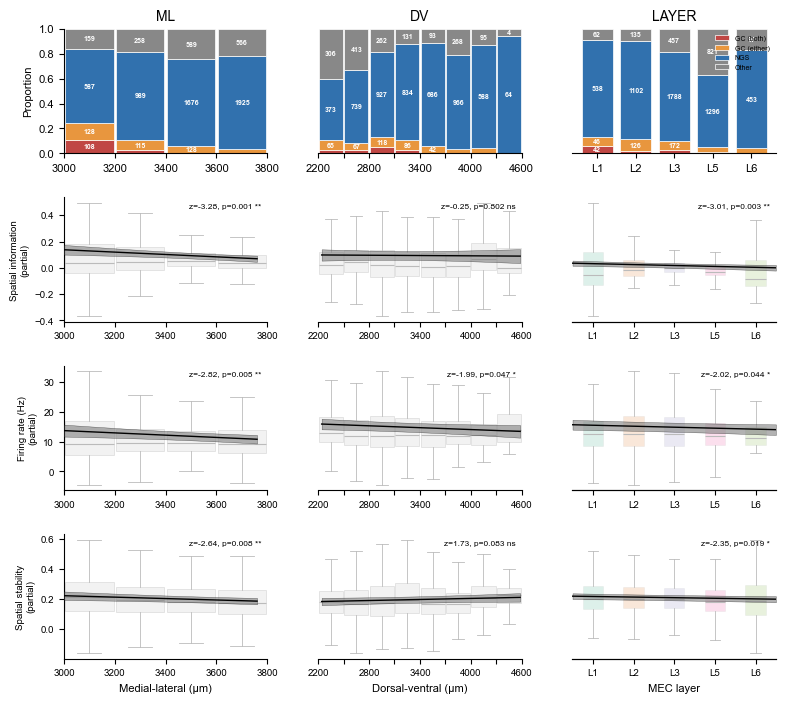

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

COL_NGS    = '#3171ae'
COL_GC_BOTH = '#c04744'
COL_GC_EITHER = '#e8963e'
COL_OTHER  = '#888888'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

stab_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_stability_cache.csv')
_cc = _cc.merge(stab_df[['mouse', 'day', 'cluster_id', 'stability']],
                on=['mouse', 'day', 'cluster_id'], how='left')

df = _cc.copy()
df['ml'] = df['SC_x'].abs()
df['dv'] = df['SC_y']
df['si'] = df['spatial_information_score_of1']
df['fr'] = df['firing_rate_OF1']
df['stab'] = df['stability']
df['_mouse'] = df['mouse'].astype(int)
df['_session'] = df['_mouse'].astype(str) + '_' + df['day'].astype(int).astype(str)

def get_prop_cat(row):
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        return 'GC_both' if cb == 'both' else 'GC_either'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

df['_prop_cat'] = df.apply(get_prop_cat, axis=1)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

df['layer_num'] = df['brain_region'].apply(get_layer_num)
df = df[df['layer_num'].notna()].copy()
df['layer_label'] = 'L' + df['layer_num'].astype(int).astype(str)

df['ml_z'] = (df['ml'] - df['ml'].mean()) / df['ml'].std()
df['dv_z'] = (df['dv'] - df['dv'].mean()) / df['dv'].std()
df['layer_z'] = (df['layer_num'] - df['layer_num'].mean()) / df['layer_num'].std()

print(f"{len(df)} ENTm cells (all types), {df['_mouse'].nunique()} mice")

def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def z_to_real(z_vals, z_col):
    real_col = z_col.replace('_z', '')
    if real_col == 'layer':
        return z_vals * df['layer_num'].std() + df['layer_num'].mean()
    return z_vals * df[real_col].std() + df[real_col].mean()

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def layer_num_to_z(ln):
    return (ln - df['layer_num'].mean()) / df['layer_num'].std()

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)
    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)
    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)
    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

def get_contribution(result, z_col, z_vals):
    contrib = np.zeros_like(z_vals, dtype=float)
    for term, coef in result.fe_params.items():
        if term == z_col:
            contrib += coef * z_vals
        elif term == f'I({z_col}**2)':
            contrib += coef * z_vals ** 2
    return contrib

def annotate_stats(ax, result, z_col):
    p = result.pvalues.get(z_col, np.nan)
    coef = result.fe_params.get(z_col, np.nan)
    se = result.bse.get(z_col, np.nan)
    stars = pval_to_stars(p)
    z_stat = coef / se if se > 0 else np.nan
    ax.annotate(f'z={z_stat:.2f}, p={p:.3f} {stars}',
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=6)

def set_bin_xticks(ax, box_bins, every_other=False):
    ax.set_xticks(box_bins)
    if every_other:
        ax.set_xticklabels([f'{int(b)}' if i % 2 == 0 else '' for i, b in enumerate(box_bins)],
                           fontsize=7)
    else:
        ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=7)

ML_BOX_BINS = np.arange(3000, 3801, 200)
DV_BOX_BINS = np.arange(2200, 4601, 300)

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
n_pts = 200

cat_order = ['GC_both', 'GC_either', 'NGS', 'Other']
cat_colors_prop = {'GC_both': COL_GC_BOTH, 'GC_either': COL_GC_EITHER, 'NGS': COL_NGS, 'Other': COL_OTHER}
cat_labels_prop = {'GC_both': 'GC (both)', 'GC_either': 'GC (either)', 'NGS': 'NGS', 'Other': 'Other'}

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', ML_BOX_BINS, False),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', DV_BOX_BINS, True),
    ('layer_z', 'layer', 'MEC layer', None, False),
]

df_si = df[df['si'].notna()].copy()
best_si, best_si_name, aic_si = fit_and_select('si', df_si)
print(f"SI model: {best_si_name}")

df_fr = df[df['fr'].notna()].copy()
best_fr, best_fr_name, aic_fr = fit_and_select('fr', df_fr)
print(f"FR model: {best_fr_name}")

df_stab = df[df['stab'].notna()].copy()
best_stab, best_stab_name, aic_stab = fit_and_select('stab', df_stab)
print(f"Stability model: {best_stab_name} (n={len(df_stab)})")

measures = [
    ('Spatial information', 'si', df_si, best_si),
    ('Firing rate (Hz)', 'fr', df_fr, best_fr),
    ('Spatial stability', 'stab', df_stab, best_stab),
]

fig = plt.figure(figsize=(8, 7))
gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.35,
                              top=0.96, bottom=0.06, left=0.08, right=0.97)

# ── Row 0: Cell type proportions (shared y) ──────────────────────────────────
gs_row0 = gs_outer[0].subgridspec(1, 3, wspace=0.25)
ax_prop = [fig.add_subplot(gs_row0[0, 0])]
ax_prop.append(fig.add_subplot(gs_row0[0, 1], sharey=ax_prop[0]))
ax_prop.append(fig.add_subplot(gs_row0[0, 2], sharey=ax_prop[0]))

for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
    ax = ax_prop[col_idx]

    if z_col == 'layer_z':
        for li, ln in enumerate(layer_nums):
            layer_cells = df[df['layer_num'] == ln]
            total = len(layer_cells)
            if total == 0: continue
            bottom = 0
            for ci, cat in enumerate(cat_order):
                n = (layer_cells['_prop_cat'] == cat).sum()
                frac = n / total
                label = cat_labels_prop[cat] if li == 0 else None
                ax.bar(li, frac, width=0.8, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5,
                       label=label)
                if frac > 0.05:
                    ax.text(li, bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xticks(np.arange(len(layer_nums)))
        ax.set_xticklabels(layer_labels, fontsize=9)
        ax.legend(fontsize=5, frameon=False, loc='upper right')
    else:
        bin_width = box_bins[1] - box_bins[0]
        centres = (box_bins[:-1] + box_bins[1:]) / 2

        for bi in range(len(box_bins) - 1):
            mask = (df[real_col] >= box_bins[bi]) & (df[real_col] < box_bins[bi + 1])
            bin_cells = df[mask]
            total = len(bin_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (bin_cells['_prop_cat'] == cat).sum()
                frac = n / total
                ax.bar(centres[bi], frac, width=bin_width * 0.95, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5)
                if frac > 0.05:
                    ax.text(centres[bi], bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac

        ax.set_xlim(box_bins[0], box_bins[-1])
        set_bin_xticks(ax, box_bins, every_other=every_other)

    ax.set_ylim(0, 1)
    if col_idx == 0:
        ax.set_ylabel('Proportion', fontsize=8)
        ax.set_title('ML', fontsize=10)
    elif col_idx == 1:
        ax.set_title('DV', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    else:
        ax.set_title('LAYER', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# ── Rows 1-3: Partial residual boxplots + GLMM fit ──────────────────────────
BP_COLOR = '#e0e0e0'
BP_EDGE  = '#bbbbbb'

for m_idx, (measure_label, dv_col, df_m, best_m) in enumerate(measures):
    gs_row = gs_outer[m_idx + 1].subgridspec(1, 3, wspace=0.25)
    row_axes = [fig.add_subplot(gs_row[0, c]) for c in range(3)]

    df_m = df_m.copy()
    df_m['_fitted'] = best_m.fittedvalues
    intercept = best_m.fe_params['Intercept']

    for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
        ax = row_axes[col_idx]
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        contrib = get_contribution(best_m, z_col, df_m[z_col].values)
        df_m['_presid'] = df_m[dv_col].values - df_m['_fitted'].values + contrib + intercept

        if z_col == 'layer_z':
            params_list = list(best_m.fe_params.keys())
            cov_mat = best_m.cov_params().loc[params_list, params_list].values
            lz_vals = np.array([layer_num_to_z(ln) for ln in layer_nums])
            pred_vals, se_vals = [], []
            for lz in lz_vals:
                d = {c: 0 for c in hold_others}; d[z_col] = lz
                pred_vals.append(predict_simple(best_m, d))
                x_row = get_design_row(best_m, d)
                se_vals.append(np.sqrt(x_row @ cov_mat @ x_row))
            pred_vals = np.array(pred_vals)
            se_vals = np.array(se_vals)

            bp_data = [df_m[df_m['layer_num'] == ln]['_presid'].dropna().values for ln in layer_nums]
            bp = ax.boxplot(bp_data, positions=np.arange(len(layer_nums)), widths=0.5,
                            patch_artist=True, showfliers=False, zorder=1,
                            medianprops=dict(color=BP_EDGE, lw=0.8),
                            whiskerprops=dict(color=BP_EDGE, lw=0.6),
                            capprops=dict(color=BP_EDGE, lw=0.6))
            for patch, ln in zip(bp['boxes'], layer_nums):
                patch.set_facecolor(layer_colors[f'L{ln}'])
                patch.set_alpha(0.15)
                patch.set_edgecolor(BP_EDGE)
                patch.set_linewidth(0.6)

            z_cont = np.linspace(df_m['layer_z'].min(), df_m['layer_z'].max(), n_pts)
            real_cont = z_to_real(z_cont, 'layer_z')
            pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)
            ax2 = ax.twiny()
            ax2.plot(real_cont, pred_cont, color='black', lw=1, zorder=5)
            ax2.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                             facecolor='grey', edgecolor='black', lw=0.3, alpha=0.6, zorder=4)
            ax2.set_xlim(real_cont[0], real_cont[-1])
            ax2.set_xticks([])
            ax2.spines[['top', 'right', 'left']].set_visible(False)
            ax2.tick_params(top=False)

            ax.set_xticks(np.arange(len(layer_nums)))
            ax.set_xticklabels(layer_labels, fontsize=8)
            annotate_stats(ax, best_m, z_col)
        else:
            bin_width = box_bins[1] - box_bins[0]
            centres = (box_bins[:-1] + box_bins[1:]) / 2

            bp_data = []
            bp_positions = []
            for i in range(len(box_bins) - 1):
                mask = (df_m[real_col] >= box_bins[i]) & (df_m[real_col] < box_bins[i + 1])
                vals = df_m.loc[mask, '_presid'].dropna().values
                if len(vals) > 3:
                    bp_data.append(vals)
                    bp_positions.append(centres[i])
                else:
                    bp_data.append(np.array([np.nan]))
                    bp_positions.append(centres[i])

            if len(bp_data) > 0:
                bp = ax.boxplot(bp_data, positions=bp_positions, widths=bin_width * 0.95,
                                patch_artist=True, showfliers=False, zorder=1,
                                medianprops=dict(color=BP_EDGE, lw=0.8),
                                whiskerprops=dict(color=BP_EDGE, lw=0.6),
                                capprops=dict(color=BP_EDGE, lw=0.6))
                for patch in bp['boxes']:
                    patch.set_facecolor(BP_COLOR)
                    patch.set_alpha(0.4)
                    patch.set_edgecolor(BP_EDGE)
                    patch.set_linewidth(0.6)

            z_vals = np.linspace(df_m[z_col].min(), df_m[z_col].max(), n_pts)
            real_vals = z_to_real(z_vals, z_col)
            pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)
            ax.plot(real_vals, pred, color='black', lw=1, zorder=4)
            ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                            facecolor='grey', edgecolor='black', lw=0.3,
                            alpha=0.6, zorder=3)

            ax.set_xlim(box_bins[0], box_bins[-1])
            set_bin_xticks(ax, box_bins, every_other=every_other)
            annotate_stats(ax, best_m, z_col)

        if col_idx == 0:
            ax.set_ylabel(f'{measure_label}\n(partial)', fontsize=7)
        else:
            ax.set_ylabel('')
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)
            ax.set_yticks([])

        if m_idx == 2:
            ax.set_xlabel(xlabel, fontsize=8)
        else:
            ax.set_xlabel('')

        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/all_cells_partial_effects.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


ENTm cells: 7365
  GC (both): 159
  GC (either): 457
  NGS: 5177
  GC (both) Spatial information (bits / spike): main (n=159)
  GC (both) Firing rate (Hz): inter (n=159)
  GC (both) Spatial stability (Pearson R): main (n=159)
  GC (either) Spatial information (bits / spike): main (n=457)
  GC (either) Firing rate (Hz): quad (n=457)
  GC (either) Spatial stability (Pearson R): main (n=452)
  NGS Spatial information (bits / spike): quad (n=5177)
  NGS Firing rate (Hz): quad (n=5177)
  NGS Spatial stability (Pearson R): main (n=4987)


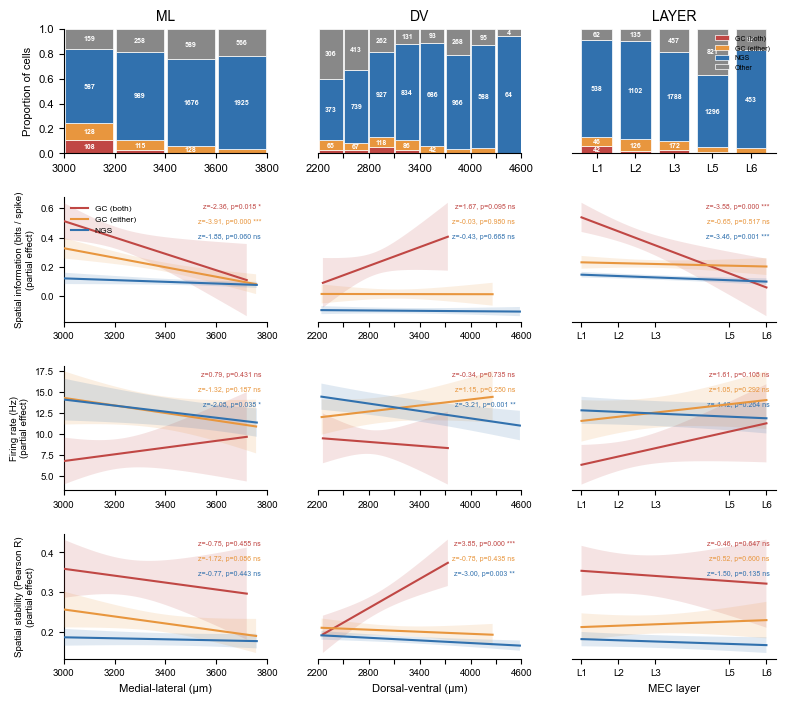

In [112]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

COL_NGS       = '#3171ae'
COL_GC_BOTH   = '#c04744'
COL_GC_EITHER = '#e8963e'
COL_OTHER     = '#888888'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

stab_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_stability_cache.csv')
_cc = _cc.merge(stab_df[['mouse', 'day', 'cluster_id', 'stability']],
                on=['mouse', 'day', 'cluster_id'], how='left')

def get_cell_group(row):
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        return 'GC_both' if cb == 'both' else 'GC_either'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

_cc['_group'] = _cc.apply(get_cell_group, axis=1)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

_cc['layer_num'] = _cc['brain_region'].apply(get_layer_num)
_cc = _cc[_cc['layer_num'].notna()].copy()

# Prepare subsets
cell_groups = [
    ('GC (both)',   'GC_both',   COL_GC_BOTH),
    ('GC (either)', 'GC_either', COL_GC_EITHER),
    ('NGS',         'NGS',       COL_NGS),
]

def prepare_df(cc_sub):
    d = cc_sub.copy()
    d['ml'] = d['SC_x'].abs()
    d['dv'] = d['SC_y']
    d['si'] = d['spatial_information_score_of1']
    d['fr'] = d['firing_rate_OF1']
    d['stab'] = d['stability']
    d['_mouse'] = d['mouse'].astype(int)
    d['_session'] = d['_mouse'].astype(str) + '_' + d['day'].astype(int).astype(str)
    d['ml_z'] = (d['ml'] - d['ml'].mean()) / d['ml'].std()
    d['dv_z'] = (d['dv'] - d['dv'].mean()) / d['dv'].std()
    d['layer_z'] = (d['layer_num'] - d['layer_num'].mean()) / d['layer_num'].std()
    return d

# Also prepare all-cells df for proportions
df_all = _cc.copy()
df_all['ml'] = df_all['SC_x'].abs()
df_all['dv'] = df_all['SC_y']
df_all['_prop_cat'] = df_all['_group']

print(f"ENTm cells: {len(_cc)}")
for label, key, _ in cell_groups:
    print(f"  {label}: {(_cc['_group'] == key).sum()}")

# ── Helpers ──────────────────────────────────────────────────────────────────
def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)
    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)
    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)
    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

def annotate_stats(ax, result, z_col, color='black', y_pos=0.95):
    p = result.pvalues.get(z_col, np.nan)
    coef = result.fe_params.get(z_col, np.nan)
    se = result.bse.get(z_col, np.nan)
    stars = pval_to_stars(p)
    z_stat = coef / se if se > 0 else np.nan
    ax.annotate(f'z={z_stat:.2f}, p={p:.3f} {stars}',
                xy=(0.97, y_pos), xycoords='axes fraction',
                ha='right', va='top', fontsize=5, color=color)

def set_bin_xticks(ax, box_bins, every_other=False):
    ax.set_xticks(box_bins)
    if every_other:
        ax.set_xticklabels([f'{int(b)}' if i % 2 == 0 else '' for i, b in enumerate(box_bins)],
                           fontsize=7)
    else:
        ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=7)

ML_BOX_BINS = np.arange(3000, 3801, 200)
DV_BOX_BINS = np.arange(2200, 4601, 300)

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
n_pts = 200

cat_order = ['GC_both', 'GC_either', 'NGS', 'Other']
cat_colors_prop = {'GC_both': COL_GC_BOTH, 'GC_either': COL_GC_EITHER, 'NGS': COL_NGS, 'Other': COL_OTHER}
cat_labels_prop = {'GC_both': 'GC (both)', 'GC_either': 'GC (either)', 'NGS': 'NGS', 'Other': 'Other'}

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', ML_BOX_BINS, False),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', DV_BOX_BINS, True),
    ('layer_z', 'layer', 'MEC layer', None, False),
]

measures = [
    ('Spatial information (bits / spike)', 'si'),
    ('Firing rate (Hz)', 'fr'),
    ('Spatial stability (Pearson R)', 'stab'),
]

# ── Fit models per group per measure ─────────────────────────────────────────
fitted = {}
for label, key, color in cell_groups:
    sub = _cc[_cc['_group'] == key]
    df_sub = prepare_df(sub)
    fitted[key] = {'df': df_sub, 'color': color, 'label': label, 'models': {}}

    for measure_label, dv_col in measures:
        df_m = df_sub[df_sub[dv_col].notna()].copy()
        if len(df_m) < 30:
            print(f"  {label} {measure_label}: too few cells ({len(df_m)}), skipping")
            fitted[key]['models'][dv_col] = None
            continue
        try:
            best, best_name, aics = fit_and_select(dv_col, df_m)
            fitted[key]['models'][dv_col] = best
            print(f"  {label} {measure_label}: {best_name} (n={len(df_m)})")
        except Exception as e:
            print(f"  {label} {measure_label}: GLMM failed ({e})")
            fitted[key]['models'][dv_col] = None

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(8, 7))
gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.35,
                              top=0.96, bottom=0.06, left=0.08, right=0.97)

# ── Row 0: Cell type proportions ─────────────────────────────────────────────
gs_row0 = gs_outer[0].subgridspec(1, 3, wspace=0.25)
ax_prop = [fig.add_subplot(gs_row0[0, 0])]
ax_prop.append(fig.add_subplot(gs_row0[0, 1], sharey=ax_prop[0]))
ax_prop.append(fig.add_subplot(gs_row0[0, 2], sharey=ax_prop[0]))

for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
    ax = ax_prop[col_idx]

    if z_col == 'layer_z':
        for li, ln in enumerate(layer_nums):
            layer_cells = df_all[df_all['layer_num'] == ln]
            total = len(layer_cells)
            if total == 0: continue
            bottom = 0
            for ci, cat in enumerate(cat_order):
                n = (layer_cells['_prop_cat'] == cat).sum()
                frac = n / total
                label = cat_labels_prop[cat] if li == 0 else None
                ax.bar(li, frac, width=0.8, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5,
                       label=label)
                if frac > 0.05:
                    ax.text(li, bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xticks(np.arange(len(layer_nums)))
        ax.set_xticklabels(layer_labels, fontsize=9)
        ax.legend(fontsize=5, frameon=False, loc='upper right')
    else:
        bin_width = box_bins[1] - box_bins[0]
        centres = (box_bins[:-1] + box_bins[1:]) / 2
        for bi in range(len(box_bins) - 1):
            mask = (df_all[real_col] >= box_bins[bi]) & (df_all[real_col] < box_bins[bi + 1])
            bin_cells = df_all[mask]
            total = len(bin_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (bin_cells['_prop_cat'] == cat).sum()
                frac = n / total
                ax.bar(centres[bi], frac, width=bin_width * 0.95, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5)
                if frac > 0.05:
                    ax.text(centres[bi], bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xlim(box_bins[0], box_bins[-1])
        set_bin_xticks(ax, box_bins, every_other=every_other)

    ax.set_ylim(0, 1)
    if col_idx == 0:
        ax.set_ylabel('Proportion of cells', fontsize=8)
        ax.set_title('ML', fontsize=10)
    elif col_idx == 1:
        ax.set_title('DV', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    else:
        ax.set_title('LAYER', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# ── Rows 1-3: Overlaid GLMM fits per cell group ─────────────────────────────
for m_idx, (measure_label, dv_col) in enumerate(measures):
    gs_row = gs_outer[m_idx + 1].subgridspec(1, 3, wspace=0.25)
    row_axes = [fig.add_subplot(gs_row[0, c]) for c in range(3)]

    for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
        ax = row_axes[col_idx]
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        stat_y_offset = 0

        for g_label, g_key, g_color in cell_groups:
            best_m = fitted[g_key]['models'].get(dv_col)
            df_g = fitted[g_key]['df']

            if best_m is None:
                continue

            if z_col == 'layer_z':
                z_cont = np.linspace(df_g['layer_z'].min(), df_g['layer_z'].max(), n_pts)
                real_cont = z_cont * df_g['layer_num'].std() + df_g['layer_num'].mean()
                pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)

                ax.plot(real_cont, pred_cont, color=g_color, lw=1.5, zorder=5, label=g_label)
                ax.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                                facecolor=g_color, alpha=0.15, zorder=3)
            else:
                z_vals = np.linspace(df_g[z_col].min(), df_g[z_col].max(), n_pts)
                real_col_name = z_col.replace('_z', '')
                real_vals = z_vals * df_g[real_col_name].std() + df_g[real_col_name].mean()
                pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)

                ax.plot(real_vals, pred, color=g_color, lw=1.5, zorder=5, label=g_label)
                ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                                facecolor=g_color, alpha=0.15, zorder=3)

            annotate_stats(ax, best_m, z_col, color=g_color, y_pos=0.95 - stat_y_offset)
            stat_y_offset += 0.12

        if z_col == 'layer_z':
            ax.set_xticks(layer_nums)
            ax.set_xticklabels(layer_labels, fontsize=8)
        else:
            if box_bins is not None:
                ax.set_xlim(box_bins[0], box_bins[-1])
                set_bin_xticks(ax, box_bins, every_other=every_other)

        if col_idx == 0:
            ax.set_ylabel(f'{measure_label}\n(partial effect)', fontsize=7)
        else:
            ax.set_ylabel('')
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)
            ax.set_yticks([])

        if m_idx == 2:
            ax.set_xlabel(xlabel, fontsize=8)
        else:
            ax.set_xlabel('')

        if m_idx == 0 and col_idx == 0:
            ax.legend(fontsize=6, frameon=False, loc='upper left')

        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cell_groups_partial_effects.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


5177 NGS ENTm cells, 7 mice
SI model: quad
FR model: quad
Stability model: main (n=4987)


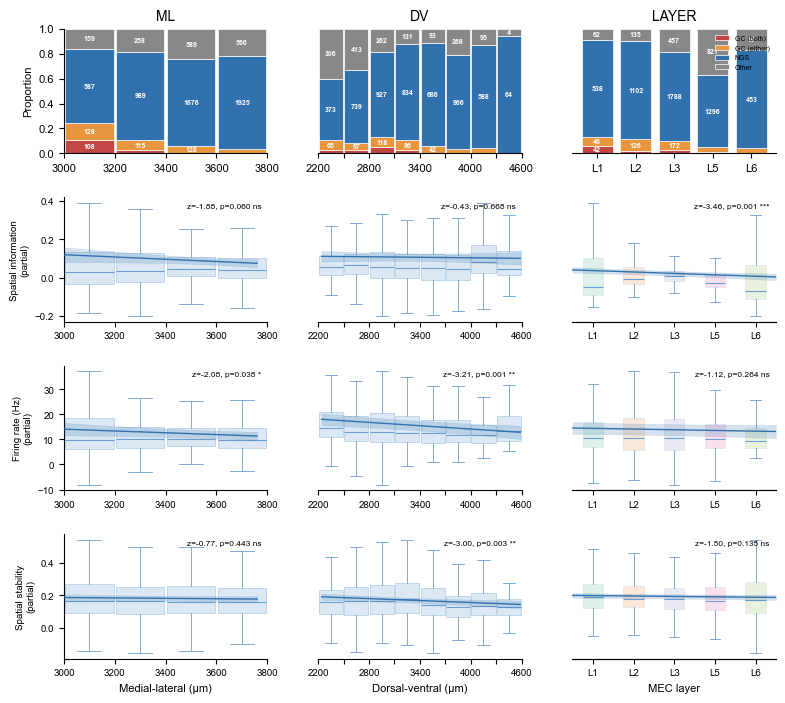

In [96]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

plt.rcParams['font.family'] = 'Arial'

COL_NGS    = '#3171ae'
COL_GC_BOTH = '#c04744'
COL_GC_EITHER = '#e8963e'
COL_OTHER  = '#888888'

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]
_cc = _cc[_cc['brain_region'].str.contains('ENTm', case=False, na=False)].copy()

stab_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/spatial_stability_cache.csv')
_cc = _cc.merge(stab_df[['mouse', 'day', 'cluster_id', 'stability']],
                on=['mouse', 'day', 'cluster_id'], how='left')

# All cells for proportions row
df_all = _cc.copy()
df_all['ml'] = df_all['SC_x'].abs()
df_all['dv'] = df_all['SC_y']

# NGS only for GLMM
df = _cc[_cc['cell_type'] == 'NG'].copy()
df['ml'] = df['SC_x'].abs()
df['dv'] = df['SC_y']
df['si'] = df['spatial_information_score_of1']
df['fr'] = df['firing_rate_OF1']
df['stab'] = df['stability']
df['_mouse'] = df['mouse'].astype(int)
df['_session'] = df['_mouse'].astype(str) + '_' + df['day'].astype(int).astype(str)

def get_prop_cat(row):
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        return 'GC_both' if cb == 'both' else 'GC_either'
    elif row['cell_type'] == 'NG':
        return 'NGS'
    return 'Other'

df_all['_prop_cat'] = df_all.apply(get_prop_cat, axis=1)

def get_layer_num(region):
    if not isinstance(region, str): return None
    r = region.upper()
    for l, v in [('ENTM1', 1), ('ENTM2', 2), ('ENTM3', 3), ('ENTM5', 5), ('ENTM6', 6)]:
        if l in r: return v
    return None

df['layer_num'] = df['brain_region'].apply(get_layer_num)
df = df[df['layer_num'].notna()].copy()
df['layer_label'] = 'L' + df['layer_num'].astype(int).astype(str)

df_all['layer_num'] = df_all['brain_region'].apply(get_layer_num)
df_all = df_all[df_all['layer_num'].notna()].copy()

df['ml_z'] = (df['ml'] - df['ml'].mean()) / df['ml'].std()
df['dv_z'] = (df['dv'] - df['dv'].mean()) / df['dv'].std()
df['layer_z'] = (df['layer_num'] - df['layer_num'].mean()) / df['layer_num'].std()

print(f"{len(df)} NGS ENTm cells, {df['_mouse'].nunique()} mice")

def pval_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def z_to_real(z_vals, z_col):
    real_col = z_col.replace('_z', '')
    if real_col == 'layer':
        return z_vals * df['layer_num'].std() + df['layer_num'].mean()
    return z_vals * df[real_col].std() + df[real_col].mean()

def predict_simple(result, d):
    pred = result.fe_params['Intercept']
    for term, coef in result.fe_params.items():
        if term == 'Intercept': continue
        if ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            pred += coef * val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            pred += coef * d.get(base, 0) ** 2
        else:
            pred += coef * d.get(term, 0)
    return pred

def get_design_row(result, d):
    params = list(result.fe_params.keys())
    x = np.zeros(len(params))
    for j, term in enumerate(params):
        if term == 'Intercept':
            x[j] = 1
        elif ':' in term:
            parts = term.split(':')
            val = 1.0
            for p in parts:
                if p.startswith('I(') and '**2' in p:
                    base = p.replace('I(', '').replace('**2)', '')
                    val *= d.get(base, 0) ** 2
                else:
                    val *= d.get(p, 0)
            x[j] = val
        elif term.startswith('I(') and '**2' in term:
            base = term.replace('I(', '').replace('**2)', '')
            x[j] = d.get(base, 0) ** 2
        else:
            x[j] = d.get(term, 0)
    return x

def partial_with_se(result, vary_col, z_vals, hold_others):
    params = list(result.fe_params.keys())
    cov_mat = result.cov_params().loc[params, params].values
    n = len(z_vals)
    pred = np.zeros(n)
    se = np.zeros(n)
    for i, z in enumerate(z_vals):
        d = {c: 0 for c in hold_others}
        d[vary_col] = z
        pred[i] = predict_simple(result, d)
        x_row = get_design_row(result, d)
        se[i] = np.sqrt(x_row @ cov_mat @ x_row)
    return pred, se

def manual_aic(result):
    k = len(result.fe_params) + 2
    return -2 * result.llf + 2 * k

def layer_num_to_z(ln):
    return (ln - df['layer_num'].mean()) / df['layer_num'].std()

def fit_and_select(dv_col, df_fit):
    vc = {"session": "0 + C(_session)"}
    m1 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z", df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r1 = m1.fit(method="powell", maxiter=5000, disp=False)
    m2 = smf.mixedlm(f"{dv_col} ~ ml_z + dv_z + layer_z + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
                      df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r2 = m2.fit(method="powell", maxiter=5000, disp=False)
    m3 = smf.mixedlm(
        f"{dv_col} ~ ml_z + dv_z + layer_z + I(ml_z**2) + I(dv_z**2) + I(layer_z**2) + ml_z:layer_z + dv_z:layer_z + ml_z:dv_z",
        df_fit, groups=df_fit["_mouse"], vc_formula=vc)
    r3 = m3.fit(method="powell", maxiter=5000, disp=False)
    results = {'main': r1, 'inter': r2, 'quad': r3}
    aics = {n: manual_aic(r) for n, r in results.items()}
    best_name = min(aics, key=aics.get)
    return results[best_name], best_name, aics

def get_contribution(result, z_col, z_vals):
    contrib = np.zeros_like(z_vals, dtype=float)
    for term, coef in result.fe_params.items():
        if term == z_col:
            contrib += coef * z_vals
        elif term == f'I({z_col}**2)':
            contrib += coef * z_vals ** 2
    return contrib

def annotate_stats(ax, result, z_col):
    p = result.pvalues.get(z_col, np.nan)
    coef = result.fe_params.get(z_col, np.nan)
    se = result.bse.get(z_col, np.nan)
    stars = pval_to_stars(p)
    z_stat = coef / se if se > 0 else np.nan
    ax.annotate(f'z={z_stat:.2f}, p={p:.3f} {stars}',
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=6)

def set_bin_xticks(ax, box_bins, every_other=False):
    ax.set_xticks(box_bins)
    if every_other:
        ax.set_xticklabels([f'{int(b)}' if i % 2 == 0 else '' for i, b in enumerate(box_bins)],
                           fontsize=7)
    else:
        ax.set_xticklabels([f'{int(b)}' for b in box_bins], fontsize=7)

ML_BOX_BINS = np.arange(3000, 3801, 200)
DV_BOX_BINS = np.arange(2200, 4601, 300)

layer_nums = [1, 2, 3, 5, 6]
layer_labels = ['L1', 'L2', 'L3', 'L5', 'L6']
layer_colors = {'L1': '#1b9e77', 'L2': '#d95f02', 'L3': '#7570b3', 'L5': '#e7298a', 'L6': '#66a61e'}
n_pts = 200

cat_order = ['GC_both', 'GC_either', 'NGS', 'Other']
cat_colors_prop = {'GC_both': COL_GC_BOTH, 'GC_either': COL_GC_EITHER, 'NGS': COL_NGS, 'Other': COL_OTHER}
cat_labels_prop = {'GC_both': 'GC (both)', 'GC_either': 'GC (either)', 'NGS': 'NGS', 'Other': 'Other'}

all_axes_info = [
    ('ml_z', 'ml', 'Medial-lateral (µm)', ML_BOX_BINS, False),
    ('dv_z', 'dv', 'Dorsal-ventral (µm)', DV_BOX_BINS, True),
    ('layer_z', 'layer', 'MEC layer', None, False),
]

# NGS blue variants for boxplot styling
BP_NGS_LIGHT = '#a8c8e8'
BP_NGS_EDGE  = '#6a9fcf'

df_si = df[df['si'].notna()].copy()
best_si, best_si_name, aic_si = fit_and_select('si', df_si)
print(f"SI model: {best_si_name}")

df_fr = df[df['fr'].notna()].copy()
best_fr, best_fr_name, aic_fr = fit_and_select('fr', df_fr)
print(f"FR model: {best_fr_name}")

df_stab = df[df['stab'].notna()].copy()
best_stab, best_stab_name, aic_stab = fit_and_select('stab', df_stab)
print(f"Stability model: {best_stab_name} (n={len(df_stab)})")

measures = [
    ('Spatial information', 'si', df_si, best_si),
    ('Firing rate (Hz)', 'fr', df_fr, best_fr),
    ('Spatial stability', 'stab', df_stab, best_stab),
]

fig = plt.figure(figsize=(8, 7))
gs_outer = gridspec.GridSpec(4, 1, figure=fig, hspace=0.35,
                              top=0.96, bottom=0.06, left=0.08, right=0.97)

# ── Row 0: Cell type proportions (shared y, uses all cells) ──────────────────
gs_row0 = gs_outer[0].subgridspec(1, 3, wspace=0.25)
ax_prop = [fig.add_subplot(gs_row0[0, 0])]
ax_prop.append(fig.add_subplot(gs_row0[0, 1], sharey=ax_prop[0]))
ax_prop.append(fig.add_subplot(gs_row0[0, 2], sharey=ax_prop[0]))

for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
    ax = ax_prop[col_idx]

    if z_col == 'layer_z':
        for li, ln in enumerate(layer_nums):
            layer_cells = df_all[df_all['layer_num'] == ln]
            total = len(layer_cells)
            if total == 0: continue
            bottom = 0
            for ci, cat in enumerate(cat_order):
                n = (layer_cells['_prop_cat'] == cat).sum()
                frac = n / total
                label = cat_labels_prop[cat] if li == 0 else None
                ax.bar(li, frac, width=0.8, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5,
                       label=label)
                if frac > 0.05:
                    ax.text(li, bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac
        ax.set_xticks(np.arange(len(layer_nums)))
        ax.set_xticklabels(layer_labels, fontsize=9)
        ax.legend(fontsize=5, frameon=False, loc='upper right')
    else:
        bin_width = box_bins[1] - box_bins[0]
        centres = (box_bins[:-1] + box_bins[1:]) / 2

        for bi in range(len(box_bins) - 1):
            mask = (df_all[real_col] >= box_bins[bi]) & (df_all[real_col] < box_bins[bi + 1])
            bin_cells = df_all[mask]
            total = len(bin_cells)
            if total == 0: continue
            bottom = 0
            for cat in cat_order:
                n = (bin_cells['_prop_cat'] == cat).sum()
                frac = n / total
                ax.bar(centres[bi], frac, width=bin_width * 0.95, bottom=bottom,
                       color=cat_colors_prop[cat], edgecolor='white', lw=0.5)
                if frac > 0.05:
                    ax.text(centres[bi], bottom + frac/2, f'{n}', ha='center', va='center',
                            fontsize=5, color='white', fontweight='bold')
                bottom += frac

        ax.set_xlim(box_bins[0], box_bins[-1])
        set_bin_xticks(ax, box_bins, every_other=every_other)

    ax.set_ylim(0, 1)
    if col_idx == 0:
        ax.set_ylabel('Proportion', fontsize=8)
        ax.set_title('ML', fontsize=10)
    elif col_idx == 1:
        ax.set_title('DV', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    else:
        ax.set_title('LAYER', fontsize=10)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(left=False)
        ax.spines['left'].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

# ── Rows 1-3: NGS partial residual boxplots + GLMM fit ──────────────────────
for m_idx, (measure_label, dv_col, df_m, best_m) in enumerate(measures):
    gs_row = gs_outer[m_idx + 1].subgridspec(1, 3, wspace=0.25)
    row_axes = [fig.add_subplot(gs_row[0, c]) for c in range(3)]

    df_m = df_m.copy()
    df_m['_fitted'] = best_m.fittedvalues
    intercept = best_m.fe_params['Intercept']

    for col_idx, (z_col, real_col, xlabel, box_bins, every_other) in enumerate(all_axes_info):
        ax = row_axes[col_idx]
        hold_others = [c for c in ['ml_z', 'dv_z', 'layer_z'] if c != z_col]

        contrib = get_contribution(best_m, z_col, df_m[z_col].values)
        df_m['_presid'] = df_m[dv_col].values - df_m['_fitted'].values + contrib + intercept

        if z_col == 'layer_z':
            params_list = list(best_m.fe_params.keys())
            cov_mat = best_m.cov_params().loc[params_list, params_list].values
            lz_vals = np.array([layer_num_to_z(ln) for ln in layer_nums])
            pred_vals, se_vals = [], []
            for lz in lz_vals:
                d = {c: 0 for c in hold_others}; d[z_col] = lz
                pred_vals.append(predict_simple(best_m, d))
                x_row = get_design_row(best_m, d)
                se_vals.append(np.sqrt(x_row @ cov_mat @ x_row))
            pred_vals = np.array(pred_vals)
            se_vals = np.array(se_vals)

            bp_data = [df_m[df_m['layer_num'] == ln]['_presid'].dropna().values for ln in layer_nums]
            bp = ax.boxplot(bp_data, positions=np.arange(len(layer_nums)), widths=0.5,
                            patch_artist=True, showfliers=False, zorder=1,
                            medianprops=dict(color=BP_NGS_EDGE, lw=0.8),
                            whiskerprops=dict(color=BP_NGS_EDGE, lw=0.6),
                            capprops=dict(color=BP_NGS_EDGE, lw=0.6))
            for patch, ln in zip(bp['boxes'], layer_nums):
                patch.set_facecolor(layer_colors[f'L{ln}'])
                patch.set_alpha(0.15)
                patch.set_edgecolor(BP_NGS_EDGE)
                patch.set_linewidth(0.6)

            z_cont = np.linspace(df_m['layer_z'].min(), df_m['layer_z'].max(), n_pts)
            real_cont = z_to_real(z_cont, 'layer_z')
            pred_cont, se_cont = partial_with_se(best_m, z_col, z_cont, hold_others)
            ax2 = ax.twiny()
            ax2.plot(real_cont, pred_cont, color=COL_NGS, lw=1, zorder=5)
            ax2.fill_between(real_cont, pred_cont - 1.96*se_cont, pred_cont + 1.96*se_cont,
                             facecolor=COL_NGS, edgecolor=COL_NGS, lw=0.3, alpha=0.2, zorder=4)
            ax2.set_xlim(real_cont[0], real_cont[-1])
            ax2.set_xticks([])
            ax2.spines[['top', 'right', 'left']].set_visible(False)
            ax2.tick_params(top=False)

            ax.set_xticks(np.arange(len(layer_nums)))
            ax.set_xticklabels(layer_labels, fontsize=8)
            annotate_stats(ax, best_m, z_col)
        else:
            bin_width = box_bins[1] - box_bins[0]
            centres = (box_bins[:-1] + box_bins[1:]) / 2

            bp_data = []
            bp_positions = []
            for i in range(len(box_bins) - 1):
                mask = (df_m[real_col] >= box_bins[i]) & (df_m[real_col] < box_bins[i + 1])
                vals = df_m.loc[mask, '_presid'].dropna().values
                if len(vals) > 3:
                    bp_data.append(vals)
                    bp_positions.append(centres[i])
                else:
                    bp_data.append(np.array([np.nan]))
                    bp_positions.append(centres[i])

            if len(bp_data) > 0:
                bp = ax.boxplot(bp_data, positions=bp_positions, widths=bin_width * 0.95,
                                patch_artist=True, showfliers=False, zorder=1,
                                medianprops=dict(color=BP_NGS_EDGE, lw=0.8),
                                whiskerprops=dict(color=BP_NGS_EDGE, lw=0.6),
                                capprops=dict(color=BP_NGS_EDGE, lw=0.6))
                for patch in bp['boxes']:
                    patch.set_facecolor(BP_NGS_LIGHT)
                    patch.set_alpha(0.4)
                    patch.set_edgecolor(BP_NGS_EDGE)
                    patch.set_linewidth(0.6)

            z_vals = np.linspace(df_m[z_col].min(), df_m[z_col].max(), n_pts)
            real_vals = z_to_real(z_vals, z_col)
            pred, se_pred = partial_with_se(best_m, z_col, z_vals, hold_others)
            ax.plot(real_vals, pred, color=COL_NGS, lw=1, zorder=4)
            ax.fill_between(real_vals, pred - 1.96*se_pred, pred + 1.96*se_pred,
                            facecolor=COL_NGS, edgecolor=COL_NGS, lw=0.3,
                            alpha=0.2, zorder=3)

            ax.set_xlim(box_bins[0], box_bins[-1])
            set_bin_xticks(ax, box_bins, every_other=every_other)
            annotate_stats(ax, best_m, z_col)

        if col_idx == 0:
            ax.set_ylabel(f'{measure_label}\n(partial)', fontsize=7)
        else:
            ax.set_ylabel('')
            ax.spines['left'].set_visible(False)
            ax.tick_params(left=False)
            ax.set_yticks([])

        if m_idx == 2:
            ax.set_xlabel(xlabel, fontsize=8)
        else:
            ax.set_xlabel('')

        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=7)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/ngs_partial_effects.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


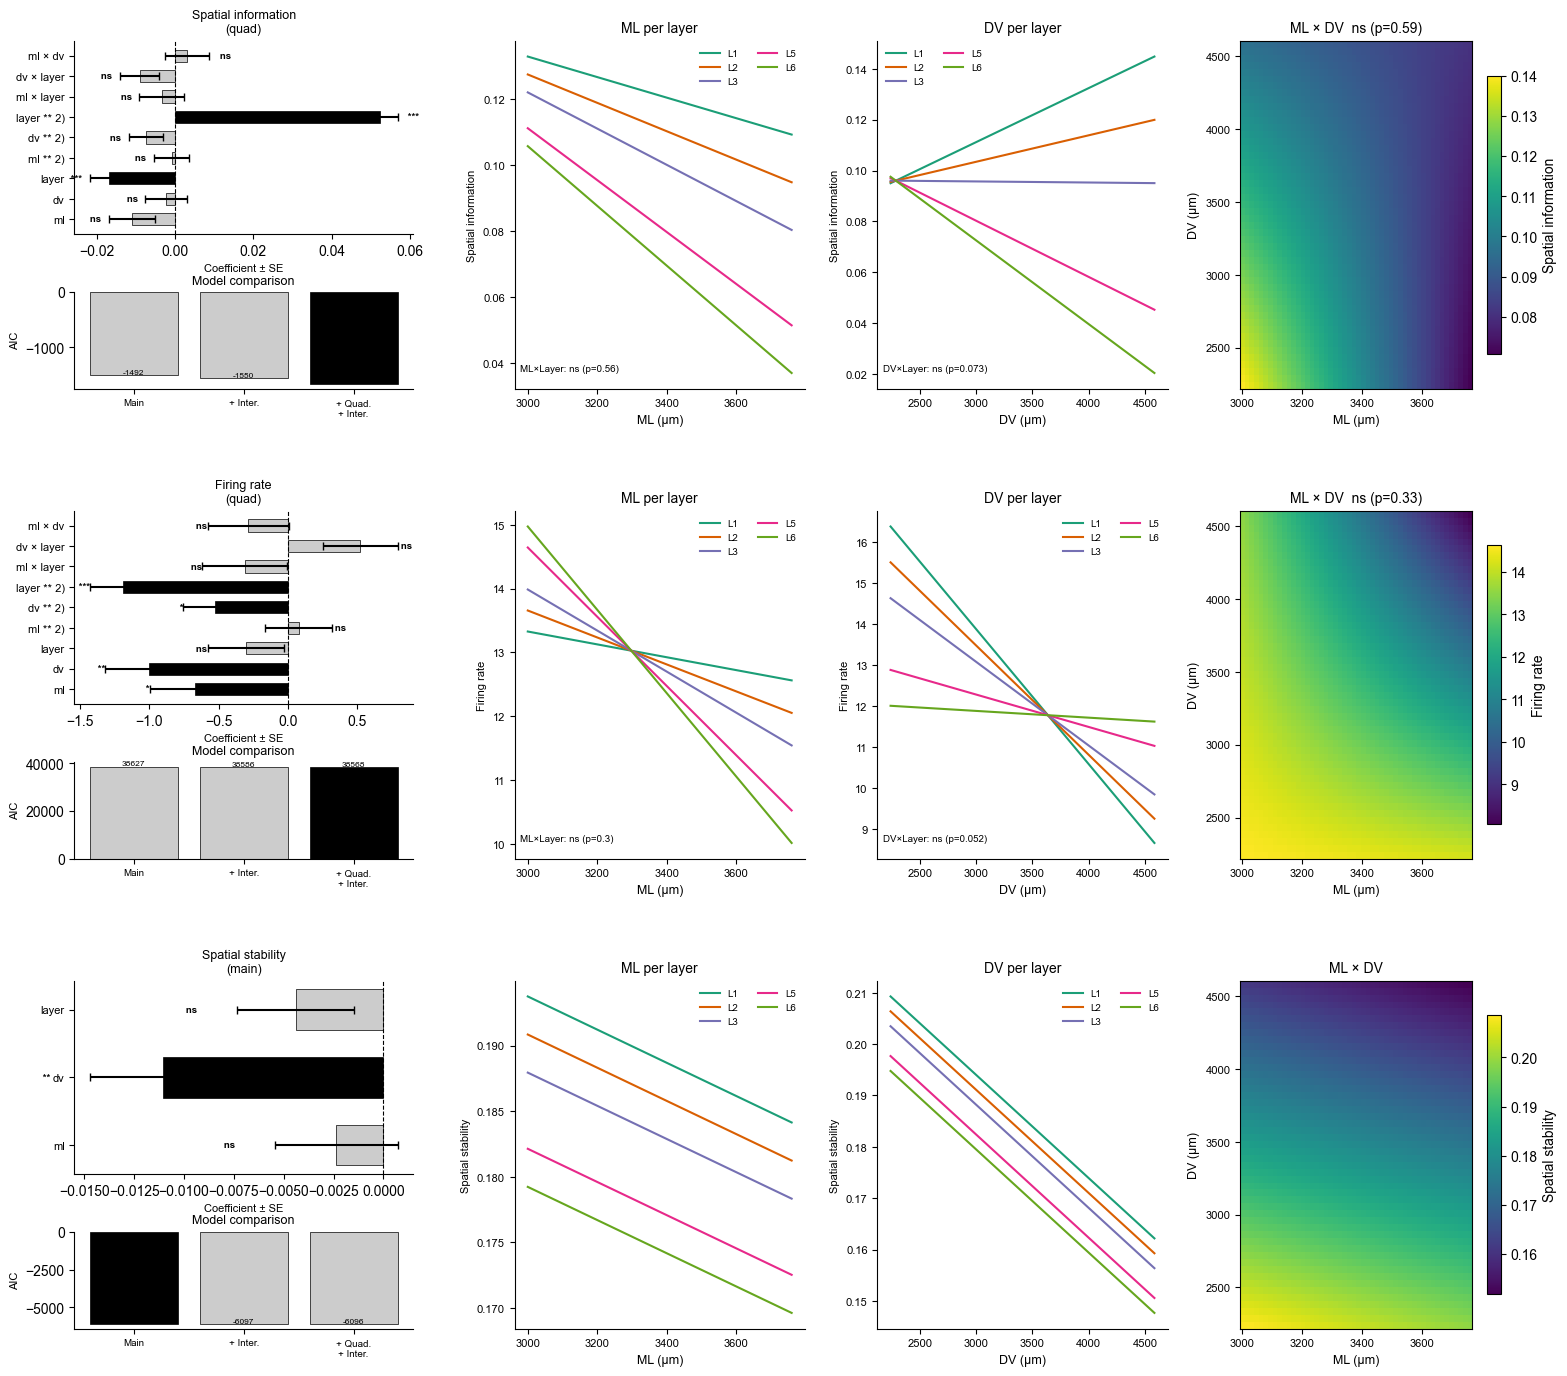

In [72]:
fig = plt.figure(figsize=(16, 14))
outer = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1, 3], wspace=0.15, hspace=0.35,
                          top=0.96, bottom=0.04, left=0.06, right=0.97)

layer_weights = np.array([len(df[df['layer_num'] == ln]) for ln in layer_nums], dtype=float)
layer_weights /= layer_weights.sum()

measures_fig2 = [
    ('Spatial information', 'si'),
    ('Firing rate', 'fr'),
    ('Spatial stability', 'stab'),
]

for m_idx, (measure_label, key) in enumerate(measures_fig2):
    best_m, best_m_name, aic_m, df_m = model_results[key]

    # ── Left: Coefficients + AIC ─────────────────────────────────────────────
    left_gs = outer[m_idx, 0].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.4)

    ax_coef = fig.add_subplot(left_gs[0, 0])
    fe = best_m.fe_params.drop('Intercept')
    se_coef = best_m.bse.reindex(fe.index)
    pvals_fe = best_m.pvalues.reindex(fe.index)
    display_names = [n.replace('_z', '').replace('I(', '').replace('**2)', '²').replace(':', ' × ')
                     for n in fe.index]
    colors_coef = ['black' if p < 0.05 else '#cccccc' for p in pvals_fe]
    y_pos = np.arange(len(fe))

    ax_coef.barh(y_pos, fe.values, xerr=se_coef.values, color=colors_coef,
                 edgecolor='black', lw=0.5, capsize=3, height=0.6)
    ax_coef.set_yticks(y_pos)
    ax_coef.set_yticklabels(display_names, fontsize=8)
    ax_coef.axvline(0, color='black', lw=0.8, ls='--')
    ax_coef.set_xlabel('Coefficient ± SE', fontsize=8)
    ax_coef.set_title(f'{measure_label}\n({best_m_name})', fontsize=9)
    ax_coef.spines[['top', 'right']].set_visible(False)
    for i, (coef, p) in enumerate(zip(fe.values, pvals_fe)):
        stars = pval_to_stars(p)
        x_off = se_coef.values[i] + 0.002 if coef >= 0 else -se_coef.values[i] - 0.002
        ax_coef.text(coef + x_off, i, f' {stars}', ha='left' if coef >= 0 else 'right',
                     va='center', fontsize=7, fontweight='bold')

    ax_aic = fig.add_subplot(left_gs[1, 0])
    names_disp = ['Main', '+ Inter.', '+ Quad.\n+ Inter.']
    aic_list = [aic_m['main'], aic_m['inter'], aic_m['quad']]
    aic_col = ['black' if n == best_m_name else '#cccccc' for n in ['main', 'inter', 'quad']]
    ax_aic.bar(range(3), aic_list, color=aic_col, edgecolor='black', lw=0.5)
    ax_aic.set_xticks(range(3))
    ax_aic.set_xticklabels(names_disp, fontsize=7)
    ax_aic.set_ylabel('AIC', fontsize=8)
    ax_aic.set_title('Model comparison', fontsize=9)
    ax_aic.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(aic_list):
        ax_aic.text(i, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=6)

    # ── Right: ML per layer, DV per layer, ML×DV heatmap ────────────────────
    right_gs = outer[m_idx, 1].subgridspec(1, 3, wspace=0.25)

    ax_ml_l = fig.add_subplot(right_gs[0, 0])
    z_ml = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_pts)
    r_ml = z_to_real(z_ml, 'ml_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': z, 'dv_z': 0, 'layer_z': lz}) for z in z_ml]
        ax_ml_l.plot(r_ml, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_ml_l.set_xlabel('ML (µm)', fontsize=9)
    ax_ml_l.set_ylabel(measure_label, fontsize=8)
    ax_ml_l.set_title('ML per layer', fontsize=10)
    ax_ml_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_ml_l.spines[['top', 'right']].set_visible(False)
    ax_ml_l.tick_params(labelsize=8)
    if 'ml_z:layer_z' in best_m.pvalues:
        p_mli = best_m.pvalues['ml_z:layer_z']
        ax_ml_l.annotate(f'ML×Layer: {pval_to_stars(p_mli)} (p={p_mli:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_dv_l = fig.add_subplot(right_gs[0, 1])
    z_dv = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_pts)
    r_dv = z_to_real(z_dv, 'dv_z')
    for ln, ll in zip(layer_nums, layer_labels):
        lz = layer_num_to_z(ln)
        preds = [predict_simple(best_m, {'ml_z': 0, 'dv_z': z, 'layer_z': lz}) for z in z_dv]
        ax_dv_l.plot(r_dv, preds, color=layer_colors[ll], lw=1.5, label=ll)
    ax_dv_l.set_xlabel('DV (µm)', fontsize=9)
    ax_dv_l.set_ylabel(measure_label, fontsize=8)
    ax_dv_l.set_title('DV per layer', fontsize=10)
    ax_dv_l.legend(fontsize=7, frameon=False, ncol=2)
    ax_dv_l.spines[['top', 'right']].set_visible(False)
    ax_dv_l.tick_params(labelsize=8)
    if 'dv_z:layer_z' in best_m.pvalues:
        p_dvl = best_m.pvalues['dv_z:layer_z']
        ax_dv_l.annotate(f'DV×Layer: {pval_to_stars(p_dvl)} (p={p_dvl:.2g})',
                         xy=(0.02, 0.05), xycoords='axes fraction', fontsize=7)

    ax_hm = fig.add_subplot(right_gs[0, 2])
    n_grid = 50
    ml_zr = np.linspace(df_m['ml_z'].min(), df_m['ml_z'].max(), n_grid)
    dv_zr = np.linspace(df_m['dv_z'].min(), df_m['dv_z'].max(), n_grid)
    MZ, DZ = np.meshgrid(ml_zr, dv_zr)
    pg = np.zeros_like(MZ)
    for ln, w in zip(layer_nums, layer_weights):
        lz = layer_num_to_z(ln)
        for i in range(n_grid):
            for j in range(n_grid):
                pg[i, j] += w * predict_simple(best_m, {'ml_z': MZ[i,j], 'dv_z': DZ[i,j], 'layer_z': lz})
    ml_r = z_to_real(ml_zr, 'ml_z')
    dv_r = z_to_real(dv_zr, 'dv_z')
    im = ax_hm.pcolormesh(ml_r, dv_r, pg, cmap='viridis', shading='auto', rasterized=True)
    plt.colorbar(im, ax=ax_hm, shrink=0.8, label=measure_label)
    if 'ml_z:dv_z' in best_m.pvalues:
        p_mlvd = best_m.pvalues['ml_z:dv_z']
        ax_hm.set_title(f'ML × DV  {pval_to_stars(p_mlvd)} (p={p_mlvd:.2g})', fontsize=10)
    else:
        ax_hm.set_title('ML × DV', fontsize=10)
    ax_hm.set_xlabel('ML (µm)', fontsize=9)
    ax_hm.set_ylabel('DV (µm)', fontsize=9)
    ax_hm.tick_params(labelsize=8)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/ngs_model_comparison_interactions.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


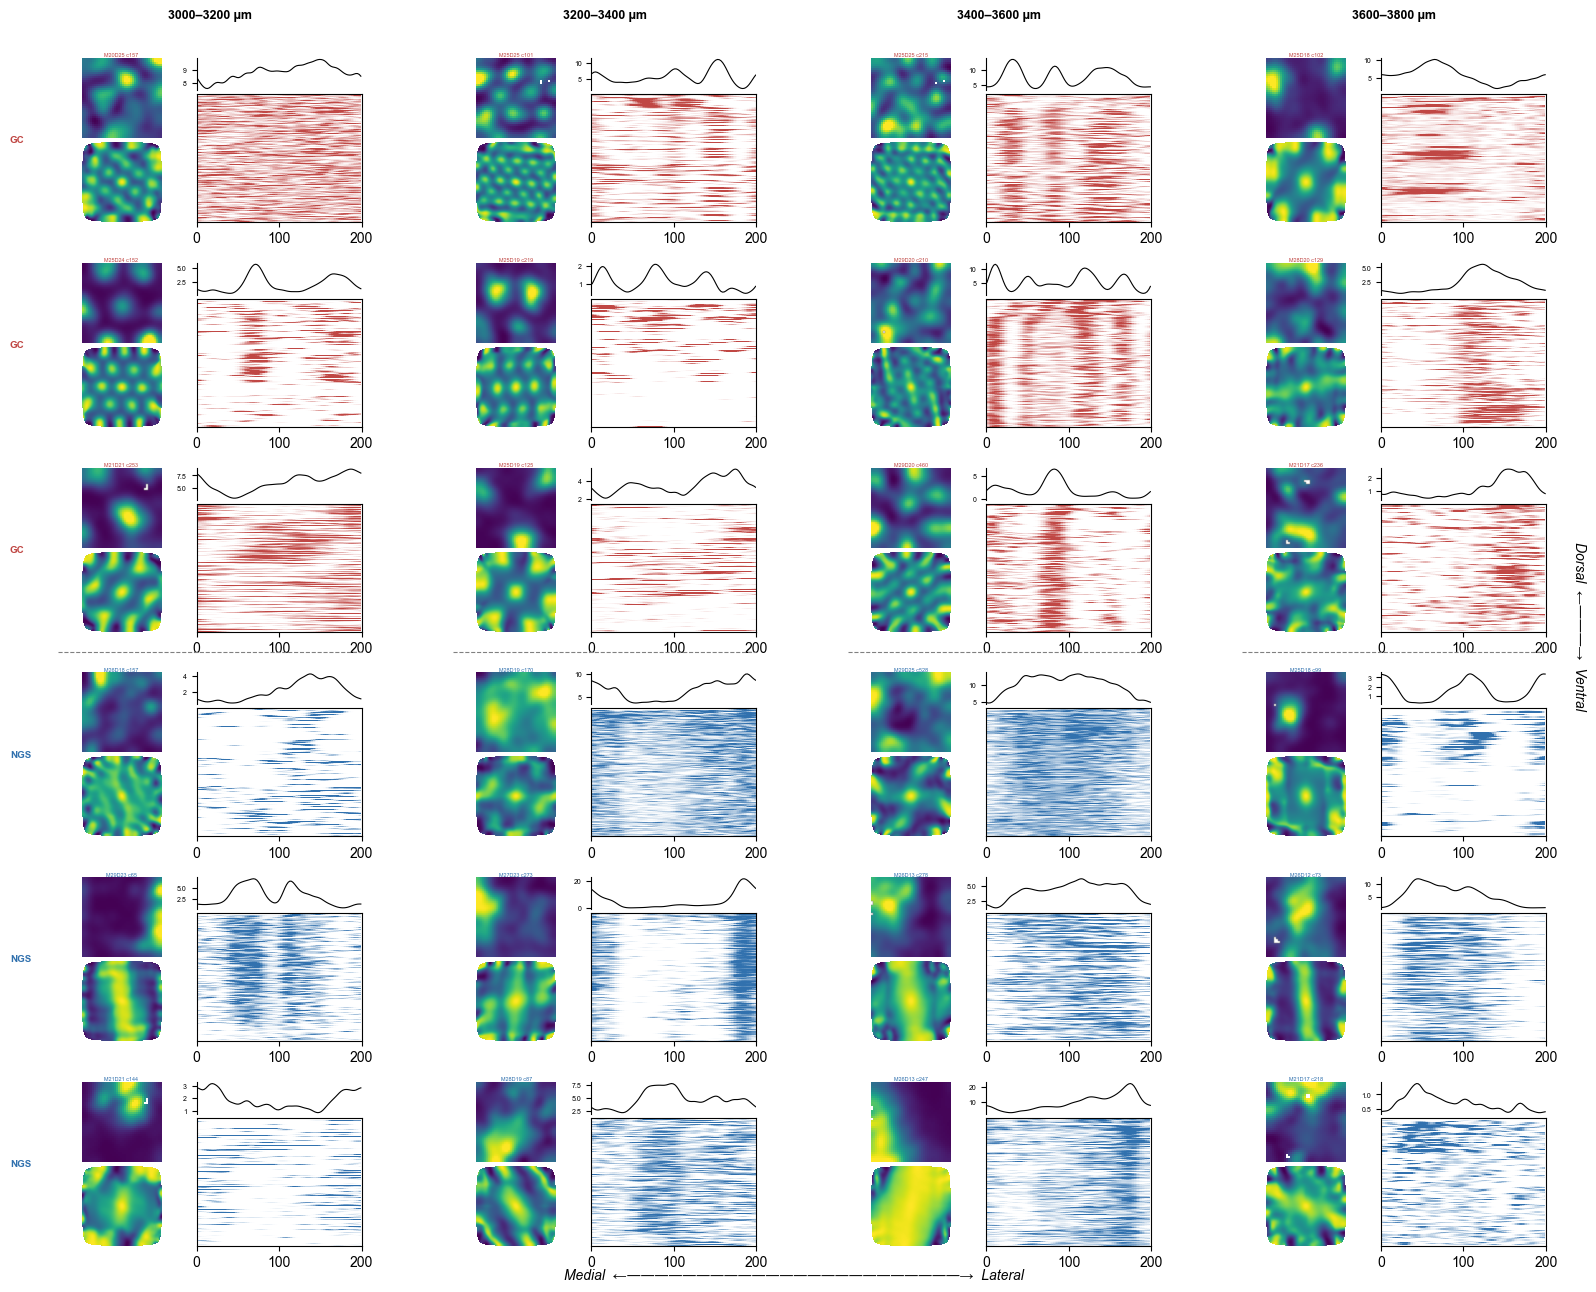

In [58]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
    compute_vr_tcs, autocorr2d, white_to_hex_cmap,
    get_avg_profile, bs, tl, time_bs
)
from spatial_manifolds.behaviour_plots import plot_firing_rate_map
from scipy.ndimage import gaussian_filter

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'

COL_GC  = '#c04744'
COL_NGS = '#3171ae'
CMAP_GC  = white_to_hex_cmap('#c04744')
CMAP_NGS = white_to_hex_cmap('#3171ae')

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"

    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)

    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)

    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))

    ax.imshow(tc, cmap='viridis')
    ax.axis('off')
    return tc

def plot_autocorrelogram(ax, tc):
    ac = autocorr2d(tc)
    ax.imshow(ac, cmap='viridis', origin='lower')
    ax.axis('off')

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_df = _df[_df['mouse'] != 22]

gc_picks = [
    [(20,25,157), (25,25,101), (25,25,215), (25,18,102)],
    [(25,24,152), (25,19,219), (29,20,210), (28,20,129)],
    [(21,21,253), (25,19,125), (29,20,460), (21,17,236)],
]

ngs_picks = [
    [(26,18,157), (28,19,170), (29,25,528), (25,18,99)],
    [(29,23,65),  (27,23,273), (26,13,278), (26,12,73)],
    [(21,21,144), (28,19,87),  (26,13,247), (21,17,218)],
]

n_rows_per_type = 3
n_cols = 4
n_rows_total = n_rows_per_type * 2

ml_labels = ['3000–3200 µm', '3200–3400 µm', '3400–3600 µm', '3600–3800 µm']

fig = plt.figure(figsize=(n_cols * 4, n_rows_total * 2.2))
outer = gridspec.GridSpec(n_rows_total, n_cols, figure=fig, wspace=0.3, hspace=0.25,
                          top=0.93, bottom=0.03, left=0.04, right=0.97)

for b in range(n_cols):
    mid_x = (outer[0, b].get_position(fig).x0 + outer[0, b].get_position(fig).x1) / 2
    fig.text(mid_x, 0.96, ml_labels[b], ha='center', fontsize=9, weight='bold')

for r in range(n_rows_per_type):
    mid_y = (outer[r, 0].get_position(fig).y0 + outer[r, 0].get_position(fig).y1) / 2
    fig.text(0.01, mid_y, 'GC', ha='left', va='center', fontsize=7, color=COL_GC, weight='bold')
for r in range(n_rows_per_type):
    mid_y = (outer[n_rows_per_type + r, 0].get_position(fig).y0 + outer[n_rows_per_type + r, 0].get_position(fig).y1) / 2
    fig.text(0.01, mid_y, 'NGS', ha='left', va='center', fontsize=7, color=COL_NGS, weight='bold')

vr_cache = {}

for row in range(n_rows_total):
    if row < n_rows_per_type:
        picks = gc_picks[row]
        title_color = COL_GC
        vr_cmap = CMAP_GC
    else:
        picks = ngs_picks[row - n_rows_per_type]
        title_color = COL_NGS
        vr_cmap = CMAP_NGS

    for col in range(n_cols):
        mouse, day, cid = picks[col]

        inner = outer[row, col].subgridspec(1, 2, wspace=0.08, width_ratios=[1, 1.3])
        inner_left  = inner[0, 0].subgridspec(2, 1, hspace=0.05, height_ratios=[1, 1])
        inner_right = inner[0, 1].subgridspec(2, 1, hspace=0.05, height_ratios=[1, 4])

        ax_of   = fig.add_subplot(inner_left[0, 0])
        ax_ac   = fig.add_subplot(inner_left[1, 0])
        ax_avg  = fig.add_subplot(inner_right[0, 0])
        ax_vr   = fig.add_subplot(inner_right[1, 0])

        # OF rate map
        try:
            tc_of = plot_of_rate_map(ax_of, cid, mouse, day, _df, session='OF1')
            ax_of.set_title(f'M{mouse}D{day} c{cid}', fontsize=4, pad=1, color=title_color)
        except Exception as e:
            ax_of.text(0.5, 0.5, '—', ha='center', va='center',
                       transform=ax_of.transAxes, fontsize=10, color='grey')
            ax_of.axis('off')
            tc_of = None
            print(f"  Failed OF M{mouse}D{day} c{cid}: {e}")

        # Autocorrelogram
        if tc_of is not None:
            try:
                plot_autocorrelogram(ax_ac, tc_of)
            except Exception as e:
                ax_ac.text(0.5, 0.5, '—', ha='center', va='center',
                           transform=ax_ac.transAxes, fontsize=10, color='grey')
                ax_ac.axis('off')
                print(f"  Failed autocorr M{mouse}D{day} c{cid}: {e}")
        else:
            ax_ac.axis('off')

        # VR rate map + avg profile
        try:
            cache_key = (mouse, day)
            if cache_key not in vr_cache:
                tcs_vr, _, _, last_ephys_bin, beh_vr, _ = compute_vr_tcs(
                    mouse, day, apply_zscore=False, apply_guassian_filter=False, source_path=SOURCE_PATH)
                vr_cache[cache_key] = (tcs_vr, last_ephys_bin)
            tcs_vr, last_ephys_bin = vr_cache[cache_key]

            tc_vr = tcs_vr[cid]
            tc_vr = gaussian_filter(np.nan_to_num(tc_vr).astype(np.float64), sigma=2.5)
            tc_vr = tc_vr[:last_ephys_bin]

            plot_firing_rate_map(ax_vr, tc_vr, bs=bs, tl=tl, p=95, cmap=vr_cmap)
            ax_vr.set_xlabel('')
            ax_vr.set_yticks([])

            x, y = get_avg_profile(tc_vr, bs, tl)
            ax_avg.plot(x, y, color='black', linewidth=0.8)
            ax_avg.set_xlim(0, tl)
            ax_avg.set_xticks([])
            ax_avg.spines[['top', 'right', 'bottom']].set_visible(False)
            ax_avg.tick_params(labelsize=5)
        except Exception as e:
            ax_vr.text(0.5, 0.5, '—', ha='center', va='center',
                       transform=ax_vr.transAxes, fontsize=10, color='grey')
            ax_vr.axis('off')
            ax_avg.axis('off')
            print(f"  Failed VR M{mouse}D{day} c{cid}: {e}")

# Divider lines between GC and NGS
for col in range(n_cols):
    gc_last = outer[n_rows_per_type - 1, col].get_position(fig)
    ngs_first = outer[n_rows_per_type, col].get_position(fig)
    y_line = (gc_last.y0 + ngs_first.y1) / 2
    fig.add_artist(plt.Line2D(
        [gc_last.x0, gc_last.x1], [y_line, y_line],
        transform=fig.transFigure, color='grey', lw=0.8, ls='--'))

fig.text(0.5, 0.005, 'Medial  ←――――――――――――――――――――――――→  Lateral',
         ha='center', fontsize=10, style='italic')
fig.text(0.995, 0.5, 'Dorsal  ←―――→  Ventral',
         ha='right', va='center', fontsize=10, style='italic', rotation=270)

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/gc_ngs_of_autocorr_vr_rate_maps.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from matplotlib.backends.backend_pdf import PdfPages
from spatial_manifolds.detect_grids import (
    compute_travel_projected, gaussian_filter_nan, _fill_nans_from_neighbors,
    compute_vr_tcs, autocorr2d, white_to_hex_cmap,
    get_avg_profile, bs, tl, time_bs
)
from spatial_manifolds.behaviour_plots import plot_firing_rate_map
from scipy.ndimage import gaussian_filter

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'

COL_GC  = '#c04744'
COL_NGS = '#3171ae'
CMAP_GC  = white_to_hex_cmap('#c04744')
CMAP_NGS = white_to_hex_cmap('#3171ae')

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"

    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)

    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)

    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))

    ax.imshow(tc, cmap='viridis')
    ax.axis('off')
    return tc

def plot_autocorrelogram(ax, tc):
    ac = autocorr2d(tc)
    ax.imshow(ac, cmap='viridis', origin='lower')
    ax.axis('off')

def plot_cell_quad(fig, gs_slot, mouse, day, cid, df, vr_cache, title_color, vr_cmap):
    inner = gs_slot.subgridspec(1, 2, wspace=0.08, width_ratios=[1, 1.3])
    inner_left  = inner[0, 0].subgridspec(2, 1, hspace=0.05, height_ratios=[1, 1])
    inner_right = inner[0, 1].subgridspec(2, 1, hspace=0.05, height_ratios=[1, 4])

    ax_of   = fig.add_subplot(inner_left[0, 0])
    ax_ac   = fig.add_subplot(inner_left[1, 0])
    ax_avg  = fig.add_subplot(inner_right[0, 0])
    ax_vr   = fig.add_subplot(inner_right[1, 0])

    # OF rate map
    tc_of = None
    try:
        tc_of = plot_of_rate_map(ax_of, cid, mouse, day, df, session='OF1')
        ex_row = df[(df['mouse'] == mouse) & (df['day'] == day) & (df['cluster_id'] == cid)]
        if len(ex_row) > 0:
            gs = ex_row.iloc[0].get('grid_score_best', np.nan)
            lag = ex_row.iloc[0].get('optimal_travel_lag', np.nan)
            ax_of.set_title(f'M{mouse}D{day} c{cid}  GS={gs:.2f}  lag={lag:.0f}', fontsize=5, pad=1, color=title_color)
        else:
            ax_of.set_title(f'M{mouse}D{day} c{cid}', fontsize=5, pad=1, color=title_color)
    except Exception as e:
        ax_of.text(0.5, 0.5, '—', ha='center', va='center',
                   transform=ax_of.transAxes, fontsize=10, color='grey')
        ax_of.axis('off')

    # Autocorrelogram
    if tc_of is not None:
        try:
            plot_autocorrelogram(ax_ac, tc_of)
        except Exception:
            ax_ac.axis('off')
    else:
        ax_ac.axis('off')

    # VR rate map + avg profile
    try:
        cache_key = (mouse, day)
        if cache_key not in vr_cache:
            tcs_vr, _, _, last_ephys_bin, _, _ = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False, source_path=SOURCE_PATH)
            vr_cache[cache_key] = (tcs_vr, last_ephys_bin)
        tcs_vr, last_ephys_bin = vr_cache[cache_key]

        tc_vr = tcs_vr[cid]
        tc_vr = gaussian_filter(np.nan_to_num(tc_vr).astype(np.float64), sigma=2.5)
        tc_vr = tc_vr[:last_ephys_bin]

        plot_firing_rate_map(ax_vr, tc_vr, bs=bs, tl=tl, p=95, cmap=vr_cmap)
        ax_vr.set_xlabel('')
        ax_vr.set_yticks([])

        x, y = get_avg_profile(tc_vr, bs, tl)
        ax_avg.plot(x, y, color='black', linewidth=0.8)
        ax_avg.set_xlim(0, tl)
        ax_avg.set_xticks([])
        ax_avg.spines[['top', 'right', 'bottom']].set_visible(False)
        ax_avg.tick_params(labelsize=5)
    except Exception:
        ax_vr.axis('off')
        ax_avg.axis('off')


def generate_catalogue(cell_df, cell_type, title_color, vr_cmap, out_path, df_all, sort_col):
    cell_df = cell_df.copy()
    cell_df['ml'] = cell_df['SC_x'].abs()
    cell_df['dv'] = cell_df['SC_y']

    ml_bins = np.arange(3000, 3801, 200)
    CELLS_PER_PAGE = 6
    N_COLS = 3
    N_ROWS = 2
    vr_cache = {}

    with PdfPages(out_path) as pdf:
        for i_ml in range(len(ml_bins) - 1):
            ml_lo, ml_hi = ml_bins[i_ml], ml_bins[i_ml + 1]
            sub = cell_df[(cell_df['ml'] >= ml_lo) & (cell_df['ml'] < ml_hi)]
            sub = sub.sort_values(sort_col, ascending=False)

            if len(sub) == 0:
                continue

            n_pages = int(np.ceil(len(sub) / CELLS_PER_PAGE))

            for page in range(n_pages):
                page_cells = sub.iloc[page * CELLS_PER_PAGE : (page + 1) * CELLS_PER_PAGE]

                fig = plt.figure(figsize=(N_COLS * 5, N_ROWS * 3))
                grid = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, wspace=0.3, hspace=0.35,
                                         top=0.90, bottom=0.03, left=0.03, right=0.97)

                fig.suptitle(
                    f'{cell_type}: ML {ml_lo}–{ml_hi} µm  (page {page+1}/{n_pages}, n={len(sub)})',
                    fontsize=11, weight='bold', color=title_color)

                for idx, (_, ex) in enumerate(page_cells.iterrows()):
                    r = idx // N_COLS
                    c = idx % N_COLS
                    mouse, day, cid = int(ex.mouse), int(ex.day), int(ex.cluster_id)

                    try:
                        plot_cell_quad(fig, grid[r, c], mouse, day, cid, df_all,
                                       vr_cache, title_color, vr_cmap)
                    except Exception as e:
                        print(f"  Failed M{mouse}D{day} c{cid}: {e}")

                for idx in range(len(page_cells), CELLS_PER_PAGE):
                    r = idx // N_COLS
                    c = idx % N_COLS
                    ax = fig.add_subplot(grid[r, c])
                    ax.axis('off')

                pdf.savefig(fig, dpi=150)
                plt.close(fig)
                print(f'  ML {ml_lo}-{ml_hi} page {page+1}/{n_pages}: {len(page_cells)} cells')

    print(f'Saved → {out_path}')


_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_df = _df[_df['mouse'] != 22]

gc = _df[(_df['cell_type'] == 'GC') & (_df['classified_by'] == 'both')].copy()
ngs = _df[_df['cell_type'] == 'NG'].copy()

np.random.seed(42)
ngs_sample = ngs.sample(frac=0.1, random_state=42)

print(f"GC catalogue: {len(gc)} cells (classified_by=both)")
generate_catalogue(
    gc, 'Grid cells (both OF)', COL_GC, CMAP_GC,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/gc_catalogue_quad.pdf',
    _df, 'grid_score_best')

print(f"\nNGS catalogue: {len(ngs_sample)} cells (10% of {len(ngs)})")
generate_catalogue(
    ngs_sample, 'Non-grid spatial', COL_NGS, CMAP_NGS,
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/ngs_catalogue_quad.pdf',
    _df, 'spatial_information_score_best')


GC catalogue: 695 cells
  ML 3000-3200 page 1/44: 6 cells
  ML 3000-3200 page 2/44: 6 cells
  ML 3000-3200 page 3/44: 6 cells
  ML 3000-3200 page 4/44: 6 cells
  ML 3000-3200 page 5/44: 6 cells
  ML 3000-3200 page 6/44: 6 cells
  ML 3000-3200 page 7/44: 6 cells
  ML 3000-3200 page 8/44: 6 cells
  ML 3000-3200 page 9/44: 6 cells
  ML 3000-3200 page 10/44: 6 cells
  ML 3000-3200 page 11/44: 6 cells
  ML 3000-3200 page 12/44: 6 cells
  ML 3000-3200 page 13/44: 6 cells
  ML 3000-3200 page 14/44: 6 cells
  ML 3000-3200 page 15/44: 6 cells
  ML 3000-3200 page 16/44: 6 cells
  ML 3000-3200 page 17/44: 6 cells
  ML 3000-3200 page 18/44: 6 cells
  ML 3000-3200 page 19/44: 6 cells
  ML 3000-3200 page 20/44: 6 cells
  ML 3000-3200 page 21/44: 6 cells
  ML 3000-3200 page 22/44: 6 cells
  ML 3000-3200 page 23/44: 6 cells
  ML 3000-3200 page 24/44: 6 cells
  ML 3000-3200 page 25/44: 6 cells
  ML 3000-3200 page 26/44: 6 cells
  ML 3000-3200 page 27/44: 6 cells
  ML 3000-3200 page 28/44: 6 cells
  ML 

: 

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Only consider cells in ENT region
def get_ent_mask(df):
    ap_idx = np.round((df['coord_SCs_z'] - ap_axis[0]) / (ap_axis[1] - ap_axis[0])).astype(int)
    dv_idx = np.round((df['coord_SCs_y'] - dv_axis[0]) / (dv_axis[1] - dv_axis[0])).astype(int)
    ml_idx = np.round((-df['coord_SCs_x'] - ml_axis[0]) / (ml_axis[1] - ml_axis[0])).astype(int)
    mask = []
    for a, d, m in zip(ap_idx, dv_idx, ml_idx):
        if (0 <= a < len(ap_axis)) and (0 <= d < len(dv_axis)) and (0 <= m < len(ml_axis)):
            mask.append(annotation_colors[a, d, m] == 'silver')
        else:
            mask.append(False)
    return np.array(mask)

gcs_ent = gcs_[get_ent_mask(gcs_)]
ngs_ent = ngs_[get_ent_mask(ngs_)]

# Bin size (100 µm)
ml_bins = np.arange(ml_axis.min(), ml_axis.max() + 100, 100)
ap_bins = np.arange(ap_axis.min(), ap_axis.max() + 100, 100)
dv_bins = np.arange(dv_axis.min(), dv_axis.max() + 100, 100)

# Device contacts
ml_contacts = device_contacts['coord_SCs_x'] * -1
ap_contacts = device_contacts['coord_SCs_z']
dv_contacts = device_contacts['coord_SCs_y']

# Only consider device contacts in ENT region
def get_ent_contact_mask(df):
    ap_idx = np.round((df['coord_SCs_z'] - ap_axis[0]) / (ap_axis[1] - ap_axis[0])).astype(int)
    dv_idx = np.round((df['coord_SCs_y'] - dv_axis[0]) / (dv_axis[1] - dv_axis[0])).astype(int)
    ml_idx = np.round((-df['coord_SCs_x'] - ml_axis[0]) / (ml_axis[1] - ml_axis[0])).astype(int)
    mask = []
    for a, d, m in zip(ap_idx, dv_idx, ml_idx):
        if (0 <= a < len(ap_axis)) and (0 <= d < len(dv_axis)) and (0 <= m < len(ml_axis)):
            mask.append(annotation_colors[a, d, m] == 'silver')
        else:
            mask.append(False)
    return np.array(mask)

ent_contact_mask = get_ent_contact_mask(device_contacts)
ent_contacts = device_contacts[ent_contact_mask]
ml_contacts_ent = ml_contacts[ent_contact_mask]
ap_contacts_ent = ap_contacts[ent_contact_mask]
dv_contacts_ent = dv_contacts[ent_contact_mask]

# Grid cells (ENT only)
ml_gcs_ent = gcs_ent['coord_SCs_x'] * -1
ap_gcs_ent = gcs_ent['coord_SCs_z']
dv_gcs_ent = gcs_ent['coord_SCs_y']

# Non-grid cells (ENT only)
ml_ngs_ent = ngs_ent['coord_SCs_x'] * -1
ap_ngs_ent = ngs_ent['coord_SCs_z']
dv_ngs_ent = ngs_ent['coord_SCs_y']

# Helper for safe division
def safe_divide(a, b):
    out = np.zeros_like(a, dtype=float)
    mask = b > 0
    out[mask] = a[mask] / b[mask]
    out[~mask] = np.nan
    return out

# ML axis
contacts_ml, _ = np.histogram(ml_contacts_ent, bins=ml_bins)
gcs_ml, _ = np.histogram(ml_gcs_ent, bins=ml_bins)
ngs_ml, _ = np.histogram(ml_ngs_ent, bins=ml_bins)
gcs_per_contact_ml = safe_divide(gcs_ml, contacts_ml)
ngs_per_contact_ml = safe_divide(ngs_ml, contacts_ml)

# AP axis
contacts_ap, _ = np.histogram(ap_contacts_ent, bins=ap_bins)
gcs_ap, _ = np.histogram(ap_gcs_ent, bins=ap_bins)
ngs_ap, _ = np.histogram(ap_ngs_ent, bins=ap_bins)
gcs_per_contact_ap = safe_divide(gcs_ap, contacts_ap)
ngs_per_contact_ap = safe_divide(ngs_ap, contacts_ap)

# DV axis
contacts_dv, _ = np.histogram(dv_contacts_ent, bins=dv_bins)
gcs_dv, _ = np.histogram(dv_gcs_ent, bins=dv_bins)
ngs_dv, _ = np.histogram(dv_ngs_ent, bins=dv_bins)
gcs_per_contact_dv = safe_divide(gcs_dv, contacts_dv)
ngs_per_contact_dv = safe_divide(ngs_dv, contacts_dv)

# Cumulative density for each axis
def cumulative_density(hist):
    cumsum = np.nancumsum(hist)
    if np.nansum(hist) > 0:
        return cumsum / np.nansum(hist)
    else:
        return np.full_like(hist, np.nan, dtype=float)

gcs_cum_ml = cumulative_density(gcs_ml)
ngs_cum_ml = cumulative_density(ngs_ml)
gcs_cum_ap = cumulative_density(gcs_ap)
ngs_cum_ap = cumulative_density(ngs_ap)
gcs_cum_dv = cumulative_density(gcs_dv)
ngs_cum_dv = cumulative_density(ngs_dv)


IndexError: index 403 is out of bounds for axis 1 with size 400

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
n_mice = len(mouse_ids)

# --- ML axis ---
n_bins_ml = len(ml_bins) - 1
gcs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
ngs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_ml[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_ml[:, i_mouse] = per_contact

data_ml = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_ml):
        data_ml.append({
            'value': gcs_cells_per_entcontact_ml[i_bin, i_mouse],
            'group': 'GCS',
            'bin': ml_bins[i_bin],
            'mouse': mouse
        })
        data_ml.append({
            'value': ngs_cells_per_entcontact_ml[i_bin, i_mouse],
            'group': 'NGS',
            'bin': ml_bins[i_bin],
            'mouse': mouse
        })
df_ml = pd.DataFrame(data_ml).dropna(subset=['value'])
model_ml = smf.mixedlm("value ~ group * bin", df_ml, groups=df_ml["mouse"])
result_ml = model_ml.fit(method="powell", maxiter=5000)
print("ML axis GLMM:")
print(result_ml.summary())

# --- AP axis ---
n_bins_ap = len(ap_bins) - 1
gcs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
ngs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_ap[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_ap[:, i_mouse] = per_contact

data_ap = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_ap):
        data_ap.append({
            'value': gcs_cells_per_entcontact_ap[i_bin, i_mouse],
            'group': 'GCS',
            'bin': ap_bins[i_bin],
            'mouse': mouse
        })
        data_ap.append({
            'value': ngs_cells_per_entcontact_ap[i_bin, i_mouse],
            'group': 'NGS',
            'bin': ap_bins[i_bin],
            'mouse': mouse
        })
df_ap = pd.DataFrame(data_ap).dropna(subset=['value'])
model_ap = smf.mixedlm("value ~ group * bin", df_ap, groups=df_ap["mouse"])
result_ap = model_ap.fit(method="powell", maxiter=5000)
print("AP axis GLMM:")
print(result_ap.summary())

# --- DV axis ---
n_bins_dv = len(dv_bins) - 1
gcs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
ngs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_dv[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_dv[:, i_mouse] = per_contact

data_dv = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_dv):
        data_dv.append({
            'value': gcs_cells_per_entcontact_dv[i_bin, i_mouse],
            'group': 'GCS',
            'bin': dv_bins[i_bin],
            'mouse': mouse
        })
        data_dv.append({
            'value': ngs_cells_per_entcontact_dv[i_bin, i_mouse],
            'group': 'NGS',
            'bin': dv_bins[i_bin],
            'mouse': mouse
        })
df_dv = pd.DataFrame(data_dv).dropna(subset=['value'])
model_dv = smf.mixedlm("value ~ group * bin", df_dv, groups=df_dv["mouse"])
result_dv = model_dv.fit(method="powell", maxiter=5000)
print("DV axis GLMM:")
print(result_dv.summary())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(5, 6))  # smaller size

# Divide by 2 to correct for double counting, and rename variables
gcs_per_contact_ml_div2 = gcs_per_contact_ml / 2
ngs_per_contact_ml_div2 = ngs_per_contact_ml / 2
gcs_per_contact_ap_div2 = gcs_per_contact_ap / 2
ngs_per_contact_ap_div2 = ngs_per_contact_ap / 2
gcs_per_contact_dv_div2 = gcs_per_contact_dv / 2
ngs_per_contact_dv_div2 = ngs_per_contact_dv / 2

# ML axis
axes[0, 0].step(ml_bins[:-1], gcs_per_contact_ml_div2, where='post', color='#c04744')
axes[0, 0].step(ml_bins[:-1], ngs_per_contact_ml_div2, where='post', color='#3171ae')
axes[0, 0].set_xlabel('Medial-lateral (µm)')
axes[0, 0].set_ylabel('Cells / MEC contact')
axes[0, 0].set_title('ML axis', fontsize=12, fontweight='normal')

gcs_density_ml = gcs_per_contact_ml_div2 / np.nansum(gcs_per_contact_ml_div2)
ngs_density_ml = ngs_per_contact_ml_div2 / np.nansum(ngs_per_contact_ml_div2)
axes[0, 1].step(ml_bins[:-1], gcs_density_ml, where='post', color='#c04744')
axes[0, 1].step(ml_bins[:-1], ngs_density_ml, where='post', color='#3171ae')
axes[0, 1].set_xlabel('Medial-lateral (µm)')
axes[0, 1].set_ylabel('Density')


# Annotate with LMM p-value for ML
axes[0, 1].annotate(
    f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.15), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)

# Set same x limits for ML row
ml_xlim = (2800, 3900)
axes[0, 0].set_xlim(ml_xlim)
axes[0, 1].set_xlim(ml_xlim)

# AP axis
axes[1, 0].step(ap_bins[:-1], gcs_per_contact_ap_div2, where='post', color='#c04744')
axes[1, 0].step(ap_bins[:-1], ngs_per_contact_ap_div2, where='post', color='#3171ae')
axes[1, 0].set_xlabel('Anterior-posterior (µm)')
axes[1, 0].set_ylabel('Cells / MEC contact')
axes[1, 0].set_title('AP axis', fontsize=12, fontweight='normal')

gcs_density_ap = gcs_per_contact_ap_div2 / np.nansum(gcs_per_contact_ap_div2)
ngs_density_ap = ngs_per_contact_ap_div2 / np.nansum(ngs_per_contact_ap_div2)
axes[1, 1].step(ap_bins[:-1], gcs_density_ap, where='post', color='#c04744')
axes[1, 1].step(ap_bins[:-1], ngs_density_ap, where='post', color='#3171ae')
axes[1, 1].set_xlabel('Anterior-posterior (µm)')
axes[1, 1].set_ylabel('Density')

# Annotate with LMM p-value for AP
axes[1, 1].annotate(
    f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)

# Set same x limits for AP row
ap_xlim = (3800, 4700)
axes[1, 0].set_xlim(ap_xlim)
axes[1, 1].set_xlim(ap_xlim)

# DV axis
axes[2, 0].step(dv_bins[:-1], gcs_per_contact_dv_div2, where='post', color='#c04744')
axes[2, 0].step(dv_bins[:-1], ngs_per_contact_dv_div2, where='post', color='#3171ae')
axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
axes[2, 0].set_ylabel('Cells / MEC contact')
axes[2, 0].set_title('DV axis', fontsize=12, fontweight='normal')

gcs_density_dv = gcs_per_contact_dv_div2 / np.nansum(gcs_per_contact_dv_div2)
ngs_density_dv = ngs_per_contact_dv_div2 / np.nansum(ngs_per_contact_dv_div2)
axes[2, 1].step(dv_bins[:-1], gcs_density_dv, where='post', color='#c04744')
axes[2, 1].step(dv_bins[:-1], ngs_density_dv, where='post', color='#3171ae')
axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
axes[2, 1].set_ylabel('Density')

# Annotate with LMM p-value for DV
axes[2, 1].annotate(
    f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)

# Set same x limits for DV row
dv_xlim = (2000, 4800)
axes[2, 0].set_xlim(dv_xlim)
axes[2, 1].set_xlim(dv_xlim)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_ENTonly_cumulative.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute per-mouse histograms for each axis and cell type ---
n_mice = len(mouse_ids)
n_bins_ml = len(ml_bins) - 1
n_bins_ap = len(ap_bins) - 1
n_bins_dv = len(dv_bins) - 1

gcs_hist_ml = np.full((n_mice, n_bins_ml), np.nan)
ngs_hist_ml = np.full((n_mice, n_bins_ml), np.nan)
gcs_hist_ap = np.full((n_mice, n_bins_ap), np.nan)
ngs_hist_ap = np.full((n_mice, n_bins_ap), np.nan)
gcs_hist_dv = np.full((n_mice, n_bins_dv), np.nan)
ngs_hist_dv = np.full((n_mice, n_bins_dv), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]

    # ML axis
    contacts_ml, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    gcs_ml, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    ngs_ml, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    gcs_hist_ml[i_mouse] = np.divide(gcs_ml, contacts_ml, out=np.full_like(gcs_ml, np.nan, dtype=float), where=contacts_ml > 0)
    ngs_hist_ml[i_mouse] = np.divide(ngs_ml, contacts_ml, out=np.full_like(ngs_ml, np.nan, dtype=float), where=contacts_ml > 0)

    # AP axis
    contacts_ap, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    gcs_ap, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
    ngs_ap, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
    gcs_hist_ap[i_mouse] = np.divide(gcs_ap, contacts_ap, out=np.full_like(gcs_ap, np.nan, dtype=float), where=contacts_ap > 0)
    ngs_hist_ap[i_mouse] = np.divide(ngs_ap, contacts_ap, out=np.full_like(ngs_ap, np.nan, dtype=float), where=contacts_ap > 0)

    # DV axis
    contacts_dv, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    gcs_dv, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
    ngs_dv, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
    gcs_hist_dv[i_mouse] = np.divide(gcs_dv, contacts_dv, out=np.full_like(gcs_dv, np.nan, dtype=float), where=contacts_dv > 0)
    ngs_hist_dv[i_mouse] = np.divide(ngs_dv, contacts_dv, out=np.full_like(ngs_dv, np.nan, dtype=float), where=contacts_dv > 0)

# --- Average and SEM across mice ---
def mean_sem(arr):
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return mean, sem

gcs_ml_mean, gcs_ml_sem = mean_sem(gcs_hist_ml)
ngs_ml_mean, ngs_ml_sem = mean_sem(ngs_hist_ml)
gcs_ap_mean, gcs_ap_sem = mean_sem(gcs_hist_ap)
ngs_ap_mean, ngs_ap_sem = mean_sem(ngs_hist_ap)
gcs_dv_mean, gcs_dv_sem = mean_sem(gcs_hist_dv)
ngs_dv_mean, ngs_dv_sem = mean_sem(ngs_hist_dv)

# --- Plot average ± SEM using step and fill_between ---
fig, axes = plt.subplots(3, 2, figsize=(5, 6))

def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=False):
    y = mean / 2 if div2 else mean
    yerr = sem / 2 if div2 else sem
    ax.step(bins[:-1], y, where='post', color=color, label=label)
    ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

# ML axis
plot_step_with_sem(axes[0, 0], ml_bins, gcs_ml_mean, gcs_ml_sem, '#c04744', label='GCS', div2=True)
plot_step_with_sem(axes[0, 0], ml_bins, ngs_ml_mean, ngs_ml_sem, '#3171ae', label='NGS', div2=True)
axes[0, 0].set_xlabel('Medial-lateral (µm)')
axes[0, 0].set_ylabel('Cells / MEC contact')
axes[0, 0].set_title('ML axis', fontsize=12, fontweight='normal')

gcs_density_ml = gcs_ml_mean / np.nansum(gcs_ml_mean)
ngs_density_ml = ngs_ml_mean / np.nansum(ngs_ml_mean)
gcs_density_ml_sem = gcs_ml_sem / np.nansum(gcs_ml_mean)
ngs_density_ml_sem = ngs_ml_sem / np.nansum(ngs_ml_mean)
plot_step_with_sem(axes[0, 1], ml_bins, gcs_density_ml, gcs_density_ml_sem, '#c04744')
plot_step_with_sem(axes[0, 1], ml_bins, ngs_density_ml, ngs_density_ml_sem, '#3171ae')
axes[0, 1].set_xlabel('Medial-lateral (µm)')
axes[0, 1].set_ylabel('Normalized dist.')
axes[0, 1].annotate(
    f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)
ml_xlim = (2800, 3900)
axes[0, 0].set_xlim(ml_xlim)
axes[0, 1].set_xlim(ml_xlim)

# AP axis
plot_step_with_sem(axes[1, 0], ap_bins, gcs_ap_mean, gcs_ap_sem, '#c04744', div2=True)
plot_step_with_sem(axes[1, 0], ap_bins, ngs_ap_mean, ngs_ap_sem, '#3171ae', div2=True)
axes[1, 0].set_xlabel('Anterior-posterior (µm)')
axes[1, 0].set_ylabel('Cells / MEC contact')
axes[1, 0].set_title('AP axis', fontsize=12, fontweight='normal')

gcs_density_ap = gcs_ap_mean / np.nansum(gcs_ap_mean)
ngs_density_ap = ngs_ap_mean / np.nansum(ngs_ap_mean)
gcs_density_ap_sem = gcs_ap_sem / np.nansum(gcs_ap_mean)
ngs_density_ap_sem = ngs_ap_sem / np.nansum(ngs_ap_mean)
plot_step_with_sem(axes[1, 1], ap_bins, gcs_density_ap, gcs_density_ap_sem, '#c04744')
plot_step_with_sem(axes[1, 1], ap_bins, ngs_density_ap, ngs_density_ap_sem, '#3171ae')
axes[1, 1].set_xlabel('Anterior-posterior (µm)')
axes[1, 1].set_ylabel('Normalized dist.')
axes[1, 1].annotate(
    f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)
ap_xlim = (3800, 4700)
axes[1, 0].set_xlim(ap_xlim)
axes[1, 1].set_xlim(ap_xlim)

# DV axis
plot_step_with_sem(axes[2, 0], dv_bins, gcs_dv_mean, gcs_dv_sem, '#c04744', div2=True)
plot_step_with_sem(axes[2, 0], dv_bins, ngs_dv_mean, ngs_dv_sem, '#3171ae', div2=True)
axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
axes[2, 0].set_ylabel('Cells / MEC contact')
axes[2, 0].set_title('DV axis', fontsize=12, fontweight='normal')

gcs_density_dv = gcs_dv_mean / np.nansum(gcs_dv_mean)
ngs_density_dv = ngs_dv_mean / np.nansum(ngs_dv_mean)
gcs_density_dv_sem = gcs_dv_sem / np.nansum(gcs_dv_mean)
ngs_density_dv_sem = ngs_dv_sem / np.nansum(ngs_dv_mean)
plot_step_with_sem(axes[2, 1], dv_bins, gcs_density_dv, gcs_density_dv_sem, '#c04744')
plot_step_with_sem(axes[2, 1], dv_bins, ngs_density_dv, ngs_density_dv_sem, '#3171ae')
axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
axes[2, 1].set_ylabel('Normalized dist.')
axes[2, 1].annotate(
    f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)
dv_xlim = (2000, 4800)
axes[2, 0].set_xlim(dv_xlim)
axes[2, 1].set_xlim(dv_xlim)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_ENTonly_cumulative_meanSEM_stepfill.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Define superficial and deep regions
superficial_regions = ['ENTm1', 'ENTm2', 'ENTm3']
deep_regions = ['ENTm5', 'ENTm6', 'ENTl6a']

def subset_cells_by_region(df, regions):
    return df[df['brain_region'].isin(regions)]

# Subset grid and non-grid cells
gcs_superficial = subset_cells_by_region(gcs_, superficial_regions)
ngs_superficial = subset_cells_by_region(ngs_, superficial_regions)
gcs_deep = subset_cells_by_region(gcs_, deep_regions)
ngs_deep = subset_cells_by_region(ngs_, deep_regions)

# Subset contacts for mice (contacts are not region-specific, so use all ent_contacts)
def run_stats_and_plot(gcs_cells, ngs_cells, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, title_suffix):
    n_mice = len(mouse_ids)
    n_bins_ml = len(ml_bins) - 1
    n_bins_ap = len(ap_bins) - 1
    n_bins_dv = len(dv_bins) - 1

    # ML
    gcs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
    ngs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_ml[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_ml[:, i_mouse] = ngs_counts / contact_counts

    # AP
    gcs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
    ngs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_ap[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_ap[:, i_mouse] = ngs_counts / contact_counts

    # DV
    gcs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
    ngs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_dv[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_dv[:, i_mouse] = ngs_counts / contact_counts

    # Stats
    def make_df(arr_gcs, arr_ngs, bins, mouse_ids):
        data = []
        for i_mouse, mouse in enumerate(mouse_ids):
            for i_bin in range(len(bins)-1):
                data.append({'value': arr_gcs[i_bin, i_mouse], 'group': 'GCS', 'bin': bins[i_bin], 'mouse': mouse})
                data.append({'value': arr_ngs[i_bin, i_mouse], 'group': 'NGS', 'bin': bins[i_bin], 'mouse': mouse})
        return pd.DataFrame(data).dropna(subset=['value'])

    df_ml = make_df(gcs_cells_per_entcontact_ml, ngs_cells_per_entcontact_ml, ml_bins, mouse_ids)
    df_ap = make_df(gcs_cells_per_entcontact_ap, ngs_cells_per_entcontact_ap, ap_bins, mouse_ids)
    df_dv = make_df(gcs_cells_per_entcontact_dv, ngs_cells_per_entcontact_dv, dv_bins, mouse_ids)

    model_ml = smf.mixedlm("value ~ group * bin", df_ml, groups=df_ml["mouse"])
    result_ml = model_ml.fit(method="powell", maxiter=5000)
    model_ap = smf.mixedlm("value ~ group * bin", df_ap, groups=df_ap["mouse"])
    result_ap = model_ap.fit(method="powell", maxiter=5000)
    model_dv = smf.mixedlm("value ~ group * bin", df_dv, groups=df_dv["mouse"])
    result_dv = model_dv.fit(method="powell", maxiter=5000)

    print(f"{title_suffix} ML axis GLMM:\n", result_ml.summary())
    print(f"{title_suffix} AP axis GLMM:\n", result_ap.summary())
    print(f"{title_suffix} DV axis GLMM:\n", result_dv.summary())

    # Plot
    def mean_sem(arr):
        mean = np.nanmean(arr, axis=1)
        sem = np.nanstd(arr, axis=1) / np.sqrt(np.sum(~np.isnan(arr), axis=1))
        return mean, sem

    gcs_ml_mean, gcs_ml_sem = mean_sem(gcs_cells_per_entcontact_ml)
    ngs_ml_mean, ngs_ml_sem = mean_sem(ngs_cells_per_entcontact_ml)
    gcs_ap_mean, gcs_ap_sem = mean_sem(gcs_cells_per_entcontact_ap)
    ngs_ap_mean, ngs_ap_sem = mean_sem(ngs_cells_per_entcontact_ap)
    gcs_dv_mean, gcs_dv_sem = mean_sem(gcs_cells_per_entcontact_dv)
    ngs_dv_mean, ngs_dv_sem = mean_sem(ngs_cells_per_entcontact_dv)

    fig, axes = plt.subplots(3, 2, figsize=(5, 6))
    def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=True):
        y = mean / 2 if div2 else mean
        yerr = sem / 2 if div2 else sem
        ax.step(bins[:-1], y, where='post', color=color, label=label)
        ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

    # ML
    plot_step_with_sem(axes[0, 0], ml_bins, gcs_ml_mean, gcs_ml_sem, '#c04744', label='GCS')
    plot_step_with_sem(axes[0, 0], ml_bins, ngs_ml_mean, ngs_ml_sem, '#3171ae', label='NGS')
    axes[0, 0].set_xlabel('Medial-lateral (µm)')
    axes[0, 0].set_ylabel('Cells / MEC contact')
    axes[0, 0].set_title(f'ML axis ({title_suffix})')

    gcs_density_ml = gcs_ml_mean / np.nansum(gcs_ml_mean)
    ngs_density_ml = ngs_ml_mean / np.nansum(ngs_ml_mean)
    gcs_density_ml_sem = gcs_ml_sem / np.nansum(gcs_ml_mean)
    ngs_density_ml_sem = ngs_ml_sem / np.nansum(ngs_ml_mean)
    plot_step_with_sem(axes[0, 1], ml_bins, gcs_density_ml, gcs_density_ml_sem, '#c04744')
    plot_step_with_sem(axes[0, 1], ml_bins, ngs_density_ml, ngs_density_ml_sem, '#3171ae')
    axes[0, 1].set_xlabel('Medial-lateral (µm)')
    axes[0, 1].set_ylabel('Normalized dist.')
    axes[0, 1].annotate(
        f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.98, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10
    )
    axes[0, 0].set_xlim((2800, 3900))
    axes[0, 1].set_xlim((2800, 3900))

    # AP
    plot_step_with_sem(axes[1, 0], ap_bins, gcs_ap_mean, gcs_ap_sem, '#c04744')
    plot_step_with_sem(axes[1, 0], ap_bins, ngs_ap_mean, ngs_ap_sem, '#3171ae')
    axes[1, 0].set_xlabel('Anterior-posterior (µm)')
    axes[1, 0].set_ylabel('Cells / MEC contact')
    axes[1, 0].set_title(f'AP axis ({title_suffix})')

    gcs_density_ap = gcs_ap_mean / np.nansum(gcs_ap_mean)
    ngs_density_ap = ngs_ap_mean / np.nansum(ngs_ap_mean)
    gcs_density_ap_sem = gcs_ap_sem / np.nansum(gcs_ap_mean)
    ngs_density_ap_sem = ngs_ap_sem / np.nansum(ngs_ap_mean)
    plot_step_with_sem(axes[1, 1], ap_bins, gcs_density_ap, gcs_density_ap_sem, '#c04744')
    plot_step_with_sem(axes[1, 1], ap_bins, ngs_density_ap, ngs_density_ap_sem, '#3171ae')
    axes[1, 1].set_xlabel('Anterior-posterior (µm)')
    axes[1, 1].set_ylabel('Normalized dist.')
    axes[1, 1].annotate(
        f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.98, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10
    )
    axes[1, 0].set_xlim((3800, 4700))
    axes[1, 1].set_xlim((3800, 4700))

    # DV
    plot_step_with_sem(axes[2, 0], dv_bins, gcs_dv_mean, gcs_dv_sem, '#c04744')
    plot_step_with_sem(axes[2, 0], dv_bins, ngs_dv_mean, ngs_dv_sem, '#3171ae')
    axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
    axes[2, 0].set_ylabel('Cells / MEC contact')
    axes[2, 0].set_title(f'DV axis ({title_suffix})')

    gcs_density_dv = gcs_dv_mean / np.nansum(gcs_dv_mean)
    ngs_density_dv = ngs_dv_mean / np.nansum(ngs_dv_mean)
    gcs_density_dv_sem = gcs_dv_sem / np.nansum(gcs_dv_mean)
    ngs_density_dv_sem = ngs_dv_sem / np.nansum(ngs_dv_mean)
    plot_step_with_sem(axes[2, 1], dv_bins, gcs_density_dv, gcs_density_dv_sem, '#c04744')
    plot_step_with_sem(axes[2, 1], dv_bins, ngs_density_dv, ngs_density_dv_sem, '#3171ae')
    axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
    axes[2, 1].set_ylabel('Normalized dist.')
    axes[2, 1].annotate(
        f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.02, 0.05), xycoords='axes fraction',
        ha='left', va='bottom', fontsize=10
    )
    axes[2, 0].set_xlim((2000, 4800))
    axes[2, 1].set_xlim((2000, 4800))

    plt.tight_layout()
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_{title_suffix}_meanSEM_stepfill.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Run for superficial and deep
run_stats_and_plot(
    gcs_superficial, ngs_superficial, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, 'superficial'
)
run_stats_and_plot(
    gcs_deep, ngs_deep, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, 'deep'
)

To give us some reassurances that we're picking up on the effect of the spatial axis, we can simulate a case where the bin factor matters and one where it doesn't and use the same test to compare

In [37]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

np.random.seed(42)

n_repeats = 100
pvals_case1 = []
pvals_case2 = []

for repeat in range(n_repeats):
    # Parameters
    n_bins = 10
    n_contacts_per_bin = 100
    n_cells_per_bin = 50

    # --- CASE 1: No difference between groups (GCS/NGS) or bins ---
    data_case1 = []
    for mouse in mouse_ids:
        for i_bin in range(n_bins):
            n_contacts = n_contacts_per_bin
            gcs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            ngs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            gcs_per_contact = gcs / n_contacts
            ngs_per_contact = ngs / n_contacts
            data_case1.append({'value': gcs_per_contact, 'group': 'GCS', 'bin': i_bin, 'mouse': mouse})
            data_case1.append({'value': ngs_per_contact, 'group': 'NGS', 'bin': i_bin, 'mouse': mouse})

    df_case1 = pd.DataFrame(data_case1)
    df_case1['group'] = df_case1['group'].astype('category')
    df_case1['mouse'] = df_case1['mouse'].astype('category')
    df_case1['bin'] = (df_case1['bin'] - df_case1['bin'].mean()) / df_case1['bin'].std()  # Standardize

    model_case1 = smf.mixedlm("value ~ group * bin", df_case1, groups=df_case1["mouse"])
    try:
        result_case1 = model_case1.fit(method="powell", maxiter=5000, disp=False)
        pval1 = result_case1.pvalues.get('group[T.NGS]:bin', np.nan)
    except Exception:
        pval1 = np.nan
    pvals_case1.append(pval1)

    # --- CASE 2: GCS has higher values in first half of bins, NGS in second half ---
    data_case2 = []
    for mouse in mouse_ids:
        for i_bin in range(n_bins):
            n_contacts = n_contacts_per_bin
            if i_bin < n_bins // 2:
                gcs = np.random.poisson(lam=n_cells_per_bin * 2, size=1)[0]
                ngs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            else:
                gcs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
                ngs = np.random.poisson(lam=n_cells_per_bin * 2, size=1)[0]
            gcs_per_contact = gcs / n_contacts
            ngs_per_contact = ngs / n_contacts
            data_case2.append({'value': gcs_per_contact, 'group': 'GCS', 'bin': i_bin, 'mouse': mouse})
            data_case2.append({'value': ngs_per_contact, 'group': 'NGS', 'bin': i_bin, 'mouse': mouse})

    df_case2 = pd.DataFrame(data_case2)
    df_case2['group'] = df_case2['group'].astype('category')
    df_case2['mouse'] = df_case2['mouse'].astype('category')
    df_case2['bin'] = (df_case2['bin'] - df_case2['bin'].mean()) / df_case2['bin'].std()  # Standardize

    model_case2 = smf.mixedlm("value ~ group * bin", df_case2, groups=df_case2["mouse"])
    try:
        result_case2 = model_case2.fit(method="powell", maxiter=5000, disp=False)
        pval2 = result_case2.pvalues.get('group[T.NGS]:bin', np.nan)
    except Exception:
        pval2 = np.nan
    pvals_case2.append(pval2)

# Count significant results (p < 0.05)
sig_case1 = np.sum(np.array(pvals_case1) < 0.05)
sig_case2 = np.sum(np.array(pvals_case2) < 0.05)

print(f"CASE 1 (designed as NULL): group[T.NGS]:bin p < 0.05 in {sig_case1} out of {n_repeats} runs")
print(f"CASE 2 (designed as ALT): group[T.NGS]:bin p < 0.05 in {sig_case2} out of {n_repeats} runs")

CASE 1 (designed as NULL): group[T.NGS]:bin p < 0.05 in 4 out of 100 runs
CASE 2 (designed as ALT): group[T.NGS]:bin p < 0.05 in 100 out of 100 runs


from this we can see that the between cases our test can detect the differences on cell location allocated to different bins

In [ ]:
device_contacts

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])  # Invert ML axis
#only keep ENT contacts
device_contacts = device_contacts[device_contacts['brain_region'].str.startswith('ENTm')]

# Define bins and labels for each axis
ml_bins = np.arange(3000, 3900, 100)
ap_bins = np.arange(3900, 4700, 100)
dv_bins = np.arange(2200, 4800, 100)
ml_bin_labels = [str(x) for x in ml_bins[:-1]]
ap_bin_labels = [str(x) for x in ap_bins[:-1]]
dv_bin_labels = [str(x) for x in dv_bins[:-1]]

# Get all unique regions (sublayers) present in device_contacts
all_sublayers = list(device_contacts['brain_region'].dropna().unique())
superficial = ['ENTm1', 'ENTm2', 'ENTm3']
deep = ['ENTl6a', 'ENTm5', 'ENTm6']

# Color map (customize as needed)
sublayer_colors = {}
for sub in all_sublayers:
    if sub == 'ENTm1':
        sublayer_colors[sub] = "#18677b"
    elif sub == 'ENTm2':
        sublayer_colors[sub] = "#0e7b7d"
    elif sub == 'ENTm3':
        sublayer_colors[sub] = "#83a5a5"
    elif sub == 'ENTm5':
        sublayer_colors[sub] = "#E09D21"
    elif sub == 'ENTm6':
        sublayer_colors[sub] = "#FCD04A"
    else:
        sublayer_colors[sub] = "#B0BEC5"

def compute_region_props(df, axis_col, bin_edges, sublayers):
    bin_idx = np.digitize(df[axis_col], bin_edges) - 1
    props = np.zeros((len(bin_edges)-1, len(sublayers)))
    for i in range(len(bin_edges)-1):
        bin_contacts = df[bin_idx == i]
        total = len(bin_contacts)
        if total > 0:
            for j, sub in enumerate(sublayers):
                props[i, j] = np.sum(bin_contacts['brain_region'] == sub) / total
        else:
            props[i, :] = np.nan
    return props

# Compute proportions for each axis
ml_props = compute_region_props(device_contacts, 'coord_SCs_x', ml_bins, all_sublayers)
ap_props = compute_region_props(device_contacts, 'coord_SCs_z', ap_bins, all_sublayers)
dv_props = compute_region_props(device_contacts, 'coord_SCs_y', dv_bins, all_sublayers)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# Helper to get indices for the desired order in the current axis
def get_ordered_indices(axis_sublayers):
    return [i for sub in all_sublayers if sub in axis_sublayers for i, s in enumerate(axis_sublayers) if s == sub]

# ML axis
ml_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ml_bin_labels))
for i in ml_indices:
    sub = all_sublayers[i]
    axes[0].bar(ml_bin_labels, ml_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ml_props[:, i]
axes[0].set_title('ML axis')
axes[0].set_xlabel('Medial-lateral (µm)')
axes[0].set_ylabel('Proportion of entorhinal contacts')
axes[0].set_xlim(-0.5, len(ml_bin_labels) - 0.5)
axes[0].set_xticks(np.arange(len(ml_bin_labels)+1)-0.5)
axes[0].set_xticklabels([str(x) for x in ml_bins], rotation=90, ha='center')

# AP axis
ap_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ap_bin_labels))
for i in ap_indices:
    sub = all_sublayers[i]
    axes[1].bar(ap_bin_labels, ap_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ap_props[:, i]
axes[1].set_title('AP axis')
axes[1].set_xlabel('Anterior-posterior (µm)')
axes[1].set_xlim(-0.5, len(ap_bin_labels) - 0.5)
axes[1].set_xticks(np.arange(len(ap_bin_labels)+1)-0.5)
axes[1].set_xticklabels([str(x) for x in ap_bins], rotation=90, ha='center')

# DV axis
dv_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(dv_bin_labels))
for i in dv_indices:
    sub = all_sublayers[i]
    axes[2].bar(dv_bin_labels, dv_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += dv_props[:, i]
axes[2].set_title('DV axis')
axes[2].set_xlabel('Dorsal-ventral (µm)')
axes[2].set_xlim(-0.5, len(dv_bin_labels) - 0.5)
axes[2].set_xticks(np.arange(len(dv_bin_labels)+1)-0.5)
axes[2].set_xticklabels([str(x) for x in dv_bins], rotation=90, ha='center')

# Move legend to far right
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=sublayer_colors[sub]) for sub in all_sublayers],
    labels=[sub for sub in all_sublayers],
    title='Brain region',
    bbox_to_anchor=(1.18, 0.5),
    loc='center left'
)

# --- Add average superficial lines and regression ---
for ax, props, lims, bin_labels in zip(
    axes,
    [ml_props, ap_props, dv_props],
    [(0, len(ml_bin_labels)), (0, len(ap_bin_labels)), (0, len(dv_bin_labels))],
    [ml_bin_labels, ap_bin_labels, dv_bin_labels]
):
    superficial_idx = [i for i, s in enumerate(all_sublayers) if s in superficial]
    avg_superficial = np.nansum(props[:, superficial_idx], axis=1)
    x_vals = np.arange(lims[0], lims[1])
    slope, intercept, r_value, p_value_sup, std_err = linregress(x_vals, avg_superficial[lims[0]:lims[1]])
    #ax.plot(x_vals, avg_superficial[lims[0]:lims[1]], color='blue', lw=2, label='Superficial (1-3)')
    ax.annotate(f"R={r_value:.2g}\np={p_value_sup:.2g}", xy=(1, 0.5), xycoords='axes fraction',
                ha='right', va='center', fontsize=11, color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.0))

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/device_contacts_brainregion_stackedbar_per_axis_proportion.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])  # Invert ML axis
#only keep ENT contacts
device_contacts = device_contacts[device_contacts['brain_region'].str.startswith('ENTm')]

# Define bins and labels for each axis
ml_bins = np.arange(3000, 3900, 100)
ap_bins = np.arange(3900, 4700, 100)
dv_bins = np.arange(2200, 4800, 100)
ml_bin_labels = [str(x) for x in ml_bins[:-1]]
ap_bin_labels = [str(x) for x in ap_bins[:-1]]
dv_bin_labels = [str(x) for x in dv_bins[:-1]]

# Get all unique regions (sublayers) present in device_contacts
all_sublayers = list(device_contacts['brain_region'].dropna().unique())
superficial = ['ENTm1', 'ENTm2', 'ENTm3']
deep = ['ENTl6a', 'ENTm5', 'ENTm6']

# Color map (customize as needed)
sublayer_colors = {}
for sub in all_sublayers:
    if sub == 'ENTm1':
        sublayer_colors[sub] = "#18677b"
    elif sub == 'ENTm2':
        sublayer_colors[sub] = "#0e7b7d"
    elif sub == 'ENTm3':
        sublayer_colors[sub] = "#83a5a5"
    elif sub == 'ENTm5':
        sublayer_colors[sub] = "#E09D21"
    elif sub == 'ENTm6':
        sublayer_colors[sub] = "#FCD04A"
    else:
        sublayer_colors[sub] = "#B0BEC5"

def compute_region_props(df, axis_col, bin_edges, sublayers):
    bin_idx = np.digitize(df[axis_col], bin_edges) - 1
    props = np.zeros((len(bin_edges)-1, len(sublayers)))
    for i in range(len(bin_edges)-1):
        bin_contacts = df[bin_idx == i]
        total = len(bin_contacts)
        if total > 0:
            for j, sub in enumerate(sublayers):
                props[i, j] = np.sum(bin_contacts['brain_region'] == sub) / total
        else:
            props[i, :] = np.nan
    return props

# Compute proportions for each axis
ml_props = compute_region_props(device_contacts, 'coord_SCs_x', ml_bins, all_sublayers)
ap_props = compute_region_props(device_contacts, 'coord_SCs_z', ap_bins, all_sublayers)
dv_props = compute_region_props(device_contacts, 'coord_SCs_y', dv_bins, all_sublayers)

fig, axes = plt.subplots(3, 1, figsize=(3, 7), sharey=True)

# Helper to get indices for the desired order in the current axis
def get_ordered_indices(axis_sublayers):
    return [i for sub in all_sublayers if sub in axis_sublayers for i, s in enumerate(axis_sublayers) if s == sub]

# ML axis
ml_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ml_bin_labels))
for i in ml_indices:
    sub = all_sublayers[i]
    axes[0].bar(ml_bin_labels, ml_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ml_props[:, i]
axes[0].set_title('ML axis')
axes[0].set_xlabel('Medial-lateral (µm)')
axes[1].set_ylabel('Proportion of entorhinal contacts')
axes[0].set_xlim(-0.5, len(ml_bin_labels) - 0.5)
axes[0].set_xticks(np.arange(len(ml_bin_labels)+1)-0.5)
axes[0].set_xticklabels([str(x) for x in ml_bins], rotation=0, ha='center')
# set xtick_labels to invisible if it isn't a multi of 500
for i, label in enumerate(axes[0].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# AP axis
ap_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ap_bin_labels))
for i in ap_indices:
    sub = all_sublayers[i]
    axes[1].bar(ap_bin_labels, ap_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ap_props[:, i]
axes[1].set_title('AP axis')
axes[1].set_xlabel('Anterior-posterior (µm)')
axes[1].set_xlim(-0.5, len(ap_bin_labels) - 0.5)
axes[1].set_xticks(np.arange(len(ap_bin_labels)+1)-0.5)
axes[1].set_xticklabels([str(x) for x in ap_bins], rotation=0, ha='center')
for i, label in enumerate(axes[1].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# DV axis
dv_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(dv_bin_labels))
for i in dv_indices:
    sub = all_sublayers[i]
    axes[2].bar(dv_bin_labels, dv_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += dv_props[:, i]
axes[2].set_title('DV axis')
axes[2].set_xlabel('Dorsal-ventral (µm)')
axes[2].set_xlim(-0.5, len(dv_bin_labels) - 0.5)
axes[2].set_xticks(np.arange(len(dv_bin_labels)+1)-0.5)
axes[2].set_xticklabels([str(x) for x in dv_bins], rotation=0, ha='center')
# set xtick_labels to invisible if it isn't a multi of 500
for i, label in enumerate(axes[2].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# Move legend to far right
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=sublayer_colors[sub]) for sub in all_sublayers],
    labels=[sub for sub in all_sublayers],
    title='Brain region',
    bbox_to_anchor=(1.18, 0.5),
    loc='center left'
)

# --- Add average superficial lines and regression ---
for ax, props, lims, bin_labels in zip(
    axes,
    [ml_props, ap_props, dv_props],
    [(0, len(ml_bin_labels)), (0, len(ap_bin_labels)), (0, len(dv_bin_labels))],
    [ml_bin_labels, ap_bin_labels, dv_bin_labels]
):
    superficial_idx = [i for i, s in enumerate(all_sublayers) if s in superficial]
    avg_superficial = np.nansum(props[:, superficial_idx], axis=1)
    x_vals = np.arange(lims[0], lims[1])
    slope, intercept, r_value, p_value_sup, std_err = linregress(x_vals, avg_superficial[lims[0]:lims[1]])
    #ax.plot(x_vals, avg_superficial[lims[0]:lims[1]], color='blue', lw=2, label='Superficial (1-3)')
    ax.annotate(f"R={r_value:.2g}\np={p_value_sup:.2g}", xy=(1, 0.5), xycoords='axes fraction',
                ha='right', va='center', fontsize=11, color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.0))

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/device_contacts_brainregion_stackedbar_per_axis_proportion.pdf', bbox_inches='tight', dpi=300)
plt.show()
